# EAUI 2026 — Análisis exploratorio y descriptivo de habilidades digitales

**Fuente:** `data/2026.sav` (Encuesta de Actividades de Usuarios de Internet 2026, 5.000 casos, 587 variables)
**Marco conceptual:** `docs/variables_habilidades_digitales.md`

---

## Pregunta de investigación

> ¿Cómo se distribuyen las habilidades digitales autorreportadas en la población chilena, y qué
> factores demográficos, educacionales, laborales, ocupacionales y territoriales estructuran esa
> distribución?

## Criterios de éxito

1. Prevalencia ponderada de cada ítem de habilidad, con intervalos de confianza que reconozcan el diseño muestral.
2. Un índice de competencia digital validado en su dimensionalidad y consistencia interna.
3. Un mapa sistemático de brechas: tamaño de efecto y significación para cada cruce sociodemográfico, con corrección por comparaciones múltiples.
4. Documentación explícita de bases, filtros, variables NET y limitaciones.

## Estructura del notebook

| Sección | Contenido |
|---|---|
| 1 | Configuración y librerías |
| 2 | Carga de datos y metadatos SPSS |
| 3 | Diccionario de variables de habilidad (desde el marco conceptual) |
| 4 | Auditoría de la base: calidad, bases filtradas, variables NET |
| 5 | Ponderadores y unidades de análisis |
| 6 | Preprocesamiento: recodificación y variables derivadas |
| 7 | Utilidades de estimación ponderada |
| 8 | EDA univariado de la batería Q8 |
| 9 | Dimensionalidad y consistencia del índice |
| 10 | Inventario de variables de cruce disponibles |
| 11 | Cruces sistemáticos: brechas de habilidad |
| 12 | Adquisición de la competencia (Q6) |
| 13 | Seguridad (Q32) y autoeficacia percibida (Q31) |
| 14 | Barreras atribuidas a falta de habilidad (Q34, P13, Q36) |
| 15 | Uso por delegación (Q37) |
| 16 | Módulo parental: conocimiento y mediación (P7, P8) |
| 17 | Validación conductual y sobredeclaración (Q8 × Q21) |
| 18 | Síntesis, exportaciones y limitaciones |

**Ejecución:** las celdas son secuenciales y dependientes. Ejecutar de arriba a abajo.

---
## 1. Configuración y librerías

In [1]:
# ---------------------------------------------------------------------------
# Librerías y configuración global
# ---------------------------------------------------------------------------
import json
import re
import unicodedata
import warnings
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadstat
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Reproducibilidad
SEMILLA = 42
np.random.seed(SEMILLA)

# Rutas
DIR_RAIZ = Path.cwd()
RUTA_SAV = DIR_RAIZ / "data" / "2026.sav"
DIR_SALIDA = DIR_RAIZ / "outputs" / "habilidades"
DIR_SALIDA.mkdir(parents=True, exist_ok=True)

# Estética de figuras (paleta apta para daltonismo)
PALETA = "colorblind"
sns.set_theme(style="whitegrid", palette=PALETA, font_scale=0.95)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "figure.autolayout": False,
})

FUENTE = "Fuente: EAUI 2026, Subsecretaría de Telecomunicaciones. Estimaciones ponderadas."
DPI_EXPORT = 300

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print(f"pandas {pd.__version__} | numpy {np.__version__} | scipy {stats.__name__}")
print(f"Salidas -> {DIR_SALIDA}")

pandas 3.0.5 | numpy 2.5.1 | scipy scipy.stats
Salidas -> /Users/tomas/github/eaui2026/outputs/habilidades


In [2]:
def guardar_figura(fig, nombre, fuente=FUENTE):
    """Anota la fuente, guarda a 300 DPI en outputs/habilidades y devuelve la ruta."""
    fig.text(0.005, -0.02, fuente, ha="left", va="top", fontsize=7, color="#555555")
    ruta = DIR_SALIDA / f"{nombre}.png"
    fig.savefig(ruta, dpi=DPI_EXPORT, bbox_inches="tight")
    return ruta


def guardar_tabla(df_tabla, nombre):
    """Exporta una tabla a CSV en outputs/habilidades y devuelve la ruta."""
    ruta = DIR_SALIDA / f"{nombre}.csv"
    df_tabla.to_csv(ruta, encoding="utf-8-sig")
    return ruta


def titulo(texto, ancho=78):
    """Encabezado de consola para separar bloques de salida."""
    print("=" * ancho)
    print(texto)
    print("=" * ancho)


def etiquetar(condicion, si, no, valido=None):
    """Serie de etiquetas de texto a partir de una condición booleana.

    `valido` marca las filas dentro de base; el resto queda como NaN. Se construye en
    dtype object porque numpy no admite mezclar cadenas con np.nan en un mismo array.
    """
    condicion = pd.Series(condicion).fillna(False).astype(bool)
    resultado = pd.Series(np.where(condicion, si, no), index=condicion.index, dtype=object)
    if valido is not None:
        resultado[~pd.Series(valido).fillna(False).astype(bool)] = np.nan
    return resultado

---
## 2. Carga de datos y metadatos SPSS

Se conserva el DataFrame crudo (`df_raw`) intacto y se trabaja siempre sobre copias. Los metadatos
SPSS (etiquetas de variable y de valor) se guardan en diccionarios auxiliares porque son la única
documentación disponible de varias baterías.

In [3]:
# ---------------------------------------------------------------------------
# Lectura del archivo SPSS + metadatos
# ---------------------------------------------------------------------------
df_raw, meta = pyreadstat.read_sav(str(RUTA_SAV))

ETIQUETA_VAR = dict(meta.column_names_to_labels)      # variable -> enunciado
ETIQUETA_VAL = dict(meta.variable_value_labels)       # variable -> {codigo: etiqueta}

titulo("ARCHIVO CARGADO")
print(f"Casos      : {df_raw.shape[0]:,}")
print(f"Variables  : {df_raw.shape[1]:,}")
print(f"Duplicados : {df_raw.duplicated().sum()}")
print(f"Memoria    : {df_raw.memory_usage(deep=True).sum() / 1e6:,.1f} MB")


def etiqueta(var, largo=120):
    """Etiqueta legible de una variable SPSS (recortada)."""
    txt = ETIQUETA_VAR.get(var, "")
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt[:largo]


def ficha(variables):
    """Ficha compacta: etiqueta, base válida, categorías y etiquetas de valor."""
    filas = []
    for v in variables:
        if v not in df_raw.columns:
            filas.append({"variable": v, "etiqueta": "*** NO EXISTE EN LA BASE ***",
                          "n_valido": 0, "n_perdidos": np.nan, "n_categorias": np.nan,
                          "valores": ""})
            continue
        s = df_raw[v]
        vals = ETIQUETA_VAL.get(v)
        filas.append({
            "variable": v,
            "etiqueta": etiqueta(v, 90),
            "n_valido": int(s.notna().sum()),
            "n_perdidos": int(s.isna().sum()),
            "n_categorias": int(s.nunique()),
            "valores": "; ".join(f"{k:g}={v2}" for k, v2 in list(vals.items())[:8])[:110] if vals else "0/1 sin etiquetas",
        })
    return pd.DataFrame(filas).set_index("variable")


ficha(["REGISTRO", "COD_REGION", "ZONA", "A9", "Q1_1", "Q1_2",
       "FE_PERSONAS", "FE_HOGAR", "POND_PERSONAS", "POND_HOGAR"])

ARCHIVO CARGADO
Casos      : 5,000
Variables  : 587
Duplicados : 0
Memoria    : 27.5 MB


,etiqueta,n_valido,n_perdidos,n_categorias,valores
variable,,,,,
REGISTRO,Número de registro,5000,0,5000,0/1 sin etiquetas
COD_REGION,Región,5000,0,16,1=Tarapacá; 2=Antofagasta; 3=Atacama; 4=Coquim...
ZONA,ZONA,5000,0,2,1=URBANA; 2=RURAL
A9,A9.- ¿Cuál es su parentesco con el Jefe /a de ...,5000,0,12,1=Yo soy el jefe de Hogar; 2=Cónyuge o Pareja;...
Q1_1,Q1_1.- ¿Cuál es su edad?,5000,0,79,0/1 sin etiquetas
Q1_2,Q1_2.- Sexo del entrevistado,5000,0,2,1=Hombre; 2=Mujer
FE_PERSONAS,Factor de Expansión persnas,5000,0,243,0/1 sin etiquetas
FE_HOGAR,Factor de Expansión Hogar,5000,0,47,0/1 sin etiquetas
POND_PERSONAS,PONDORADOR PERSONAS,5000,0,243,0/1 sin etiquetas


---
## 3. Diccionario de variables de habilidad

Traducción directa del marco conceptual (`docs/variables_habilidades_digitales.md`) a estructuras
de datos. Toda la selección de variables del resto del notebook se deriva de este bloque, de modo
que cambiar aquí una clasificación se propaga a todo el análisis.

**Convención de niveles (síntesis operativa, sección 2 del documento):**

- **Básicas:** Q8_1, Q8_10, Q8_11, Q8_12, Q8_15, Q8_16
- **Medias:** Q8_2, Q8_3, Q8_4, Q8_5, Q8_6, Q8_13, Q8_14, Q8_17
- **Avanzadas:** Q8_7, Q8_8, Q8_9
- **Emergente:** Q8_18 (IA generativa)

In [4]:
# ---------------------------------------------------------------------------
# 3.1 Batería Q8: habilidades digitales autorreportadas (núcleo del análisis)
# ---------------------------------------------------------------------------
Q8_ITEMS = {
    "Q8_1":  ("Procesador de texto (Word)",              "Básica",    "Creación de contenidos"),
    "Q8_2":  ("Fórmulas sencillas en planilla (Excel)",  "Media",     "Creación de contenidos"),
    "Q8_3":  ("Software de presentación (PowerPoint)",   "Media",     "Creación de contenidos"),
    "Q8_4":  ("Duplicar/transferir archivos o a la nube","Media",     "Información y datos"),
    "Q8_5":  ("Conectar un nuevo dispositivo",           "Media",     "Resolución de problemas"),
    "Q8_6":  ("Descargar, instalar y configurar apps",   "Media",     "Resolución de problemas"),
    "Q8_7":  ("Modificar configuración de seguridad",    "Avanzada",  "Seguridad"),
    "Q8_8":  ("Instalar SO o programar",                 "Avanzada",  "Resolución de problemas"),
    "Q8_9":  ("Crear un sitio web",                      "Avanzada",  "Creación de contenidos"),
    "Q8_10": ("Plataformas de video, series, música",    "Básica",    "Información y datos"),
    "Q8_11": ("Participar en juegos en línea",           "Básica",    "Comunicación"),
    "Q8_12": ("Revisar redes sociales",                  "Básica",    "Comunicación"),
    "Q8_13": ("Subir contenidos o postear en RRSS",      "Media",     "Creación de contenidos"),
    "Q8_14": ("Editar fotografías o videos",             "Media",     "Creación de contenidos"),
    "Q8_15": ("Realizar videollamadas",                  "Básica",    "Comunicación"),
    "Q8_16": ("Enviar y recibir correos",                "Básica",    "Comunicación"),
    "Q8_17": ("Transacciones bancarias y pagos en línea","Media",     "Seguridad / transacción"),
    "Q8_18": ("Uso de IA (ChatGPT, etc.)",               "Emergente", "Transversal"),
}
Q8_NINGUNA = "Q8_19"

Q8_VARS      = list(Q8_ITEMS)
Q8_ETIQUETA  = {v: t[0] for v, t in Q8_ITEMS.items()}
Q8_NIVEL     = {v: t[1] for v, t in Q8_ITEMS.items()}
Q8_DIGCOMP   = {v: t[2] for v, t in Q8_ITEMS.items()}

Q8_BASICAS   = [v for v in Q8_VARS if Q8_NIVEL[v] == "Básica"]
Q8_MEDIAS    = [v for v in Q8_VARS if Q8_NIVEL[v] == "Media"]
Q8_AVANZADAS = [v for v in Q8_VARS if Q8_NIVEL[v] == "Avanzada"]
Q8_EMERGENTE = [v for v in Q8_VARS if Q8_NIVEL[v] == "Emergente"]

ORDEN_NIVEL_ITEM = ["Básica", "Media", "Avanzada", "Emergente"]

print(f"Q8: {len(Q8_VARS)} ítems -> básicas {len(Q8_BASICAS)}, medias {len(Q8_MEDIAS)}, "
      f"avanzadas {len(Q8_AVANZADAS)}, emergente {len(Q8_EMERGENTE)}")

Q8: 18 ítems -> básicas 6, medias 8, avanzadas 3, emergente 1


In [5]:
# ---------------------------------------------------------------------------
# 3.2 Baterías complementarias
# ---------------------------------------------------------------------------

# Q6 — vía de adquisición de la competencia (base n = 5.000)
Q6_ADQUISICION = {
    "Q6_11":  "Aprendí solo (autodidacta)",
    "Q6_2":   "Me enseñó familiar, amigo o contacto",
    "Q6_3":   "Currículum central escolar/superior",
    "Q6_4":   "Clases optativas o complementarias",
    "Q6_5":   "Curso particular / municipio / centro social",
    "Q6_10":  "En el trabajo",
    "Q6_111": "A través del ciber",
    "Q6_6":   "Otro",
}
Q6_SIN_COMPETENCIA = {"Q6_7": "No sé usar computador / nunca he usado uno"}
Q6_ACCESO          = {"Q6_8": "No usa", "Q6_9": "No tiene"}   # acceso, NO habilidad
Q6_NS              = {"Q6_12": "No sabe"}

# Vías formales vs informales (para el análisis de capital digital)
Q6_FORMALES   = ["Q6_3", "Q6_4", "Q6_5"]
Q6_INFORMALES = ["Q6_11", "Q6_2", "Q6_111"]
Q6_LABORAL    = ["Q6_10"]

# Q32 — prácticas de seguridad y privacidad (base n = 4.731)
# Solo los 6 ítems del listado leído + VPN. Q32_7 es NET: excluido de todo índice.
Q32_NUCLEO = {
    "Q32_1": "Herramientas de protección (antivirus/firewall)",
    "Q32_2": "No abrir archivos o links sospechosos",
    "Q32_3": "Borrar/editar contenido propio publicado",
    "Q32_4": "Cambiar ajustes de privacidad en RRSS",
    "Q32_5": "Borrar historial de búsqueda",
    "Q32_6": "Cambio de contraseñas",
}
Q32_ESPONTANEAS = {
    "Q32_9":  "Bloqueo de llamadas",       "Q32_10": "No contestar desconocidos",
    "Q32_11": "TrueCaller",                "Q32_12": "No prestar el teléfono",
    "Q32_13": "Seguir recomendaciones de bancos", "Q32_14": "Reformatear el equipo",
    "Q32_15": "Usar VPN",                  "Q32_16": "Cambio de computador",
    "Q32_17": "Borrar mensajes/fotos/archivos",
}
Q32_NET      = ["Q32_7"]                       # NET OTROS — nunca sumar con sus componentes
Q32_NINGUNA  = "Q32_18"
Q32_NS       = ["Q32_8", "Q32_19"]

# Q34 — razones de no uso de internet (base n = 269, no usuarios)
Q34_HABILIDAD = {
    "Q34_6":  "No sé utilizar computador/smartphone",
    "Q34_7":  "No sé cómo utilizar internet",
    "Q34_8":  "No creo ser capaz de aprender (autoeficacia)",
}
Q34_CONTEXTO_HAB = {
    "Q34_9":  "No me dan ganas de aprender (disposición)",
    "Q34_10": "Otras personas navegan por mí (delegación)",
    "Q34_11": "Discapacidad o limitación",
    "Q34_2":  "No sé para qué sirve internet (conocimiento)",
}
Q34_NET = ["Q34_1", "Q34_5", "Q34_12", "Q34_15", "Q34_18"]

# P13 — razones de no tener banda ancha fija (base n = 1.645, nivel HOGAR)
P13_HABILIDAD = {
    "P13_4": "No saben utilizar computador/smartphone",
    "P13_5": "No saben cómo utilizar internet",
}
P13_CONOCIMIENTO = {
    "P13_1": "No conocen los beneficios de internet",
    "P13_2": "Conocen beneficios pero no lo encuentran útil",
    "P13_6": "Falta de confianza",
    "P13_19": "Preocupación por privacidad o seguridad",
}

# Q37 — uso por delegación (base n = 269)
Q37_DELEGACION = {
    "Q37_1": "Obtener algún formulario",
    "Q37_2": "Buscar información (estudio/trabajo)",
    "Q37_3": "Recibir o enviar correo electrónico",
    "Q37_4": "Revisar alguna red social",
    "Q37_5": "Realizar un trámite o pagar una cuenta",
    "Q37_6": "Realizar una compra",
}
Q37_NINGUNA = "Q37_7"

# P7 — mediación parental (base n = 1.452 hogares con menores, nivel HOGAR)
P7_TECNICA = {
    "P7_2":  "Filtros / software de control parental",
    "P7_6":  "Filtro de contenido de sitios inapropiados",
    "P7_7":  "Bloqueo de aplicaciones o plataformas",
    "P7_8":  "Restricción de RRSS y mensajería",
    "P7_9":  "Restricción de descargas/instalación",
    "P7_10": "Controles parentales en dispositivos",
}
P7_NO_TECNICA = {
    "P7_1": "Reglas acordadas de uso",
    "P7_3": "Supervisión y monitoreo",
    "P7_4": "Acceso solo desde lugares comunes",
    "P7_5": "Educar sobre uso seguro y responsable",
}
P7_SIN_MEDIDAS = "P7_11"

# P8 — conocimiento declarado y capacidad de detección (nivel HOGAR)
P8_CONOCIMIENTO = {"P8_1": "Conoce delitos y vulneraciones sexuales digitales",
                   "P8_2": "Conoce la violencia digital hacia NNA"}
P8_DETECCION    = {"P8_3_1": "Cyberbullying", "P8_3_2": "Captación / grooming",
                   "P8_3_3": "Engaños, estafas o robo de información"}
P8_NO_DETECTA   = "P8_3_4"

# Q21 — actividades que validan conductualmente la competencia declarada
Q21_VALIDACION = {
    "Q21_40": ("Mantener sitio web de empresa propia", "Q8_9"),
    "Q21_47": ("Crear páginas web",                    "Q8_9"),
    "Q21_48": ("Obtener software, parches, updates",   "Q8_6"),
    "Q21_34": ("Realizar transacciones bancarias",     "Q8_17"),
    "Q21_15": ("Crear y subir contenidos a la web",    "Q8_13"),
    "Q21_16": ("Crear y subir contenidos en RRSS",     "Q8_13"),
    "Q21_28": ("Completar formularios en línea",       None),
    "Q21_30": ("Pagos en línea a organismos del Estado", None),
    "Q21_31": ("Trámites de certificados o beneficios", None),
    "Q21_32": ("Participar o votar electrónicamente",  None),
    "Q21_43": ("Teletrabajo",                          None),
    "Q21_46": ("Estudios o capacitación en línea",     None),
}
Q21_NET = ["Q21_1", "Q21_10", "Q21_19", "Q21_26", "Q21_33", "Q21_38", "Q21_44"]

# Registro central de variables NET: se excluyen de todo índice sumativo
VARS_NET = Q32_NET + Q34_NET + Q21_NET + ["Q33_6", "Q36_CODIF_1", "Q36_CODIF_3",
                                          "Q36_CODIF_5", "Q36_CODIF_10", "Q36_CODIF_12",
                                          "Q36_CODIF_14"]

print(f"Baterías declaradas | Q6: {len(Q6_ADQUISICION)} vías | Q32 núcleo: {len(Q32_NUCLEO)} | "
      f"Q34 habilidad: {len(Q34_HABILIDAD)} | P13 habilidad: {len(P13_HABILIDAD)} | "
      f"Q37: {len(Q37_DELEGACION)} | P7 técnica: {len(P7_TECNICA)}")
print(f"Variables NET registradas para exclusión: {len(VARS_NET)}")

Baterías declaradas | Q6: 8 vías | Q32 núcleo: 6 | Q34 habilidad: 3 | P13 habilidad: 2 | Q37: 6 | P7 técnica: 6
Variables NET registradas para exclusión: 20


---
## 4. Auditoría de la base

Antes de estimar nada: qué existe, con qué base y con qué calidad. Tres controles.

1. **Variables completamente vacías** — si el trabajo de campo no capturó una variable, cualquier cruce que la use es imposible.
2. **Bases filtradas** — cada batería tiene una base distinta (filtros del cuestionario). Confundir "no aplica" con "no" es el error más frecuente en estas encuestas.
3. **Consistencia lógica de Q8** — `Q8_19` (NINGUNA) debe ser mutuamente excluyente con `Q8_1`–`Q8_18`.

In [6]:
# ---------------------------------------------------------------------------
# 4.1 Variables sin ningún dato válido
# ---------------------------------------------------------------------------
vars_vacias = [c for c in df_raw.columns if df_raw[c].notna().sum() == 0]

titulo("VARIABLES COMPLETAMENTE VACÍAS")
if vars_vacias:
    display(ficha(vars_vacias)[["etiqueta", "n_valido"]])
    print("\nImplicancia: estas variables NO pueden usarse en ningún cruce.")
else:
    print("Ninguna.")

VARIABLES COMPLETAMENTE VACÍAS


,etiqueta,n_valido
variable,,
Q2,Q2.-¿Cuál es su actividad principal en la actu...,0
Q40_1,Computador fijo (pc),0
Q40_2,Laptop,0
Q40_3,Netbook,0



Implicancia: estas variables NO pueden usarse en ningún cruce.


In [7]:
# ---------------------------------------------------------------------------
# 4.2 Bases válidas por batería (filtros del cuestionario)
# ---------------------------------------------------------------------------
BATERIAS = {
    "Q6  — adquisición de la competencia": list(Q6_ADQUISICION),
    "Q8  — habilidades autorreportadas":   Q8_VARS + [Q8_NINGUNA],
    "Q21 — actividades de uso":            list(Q21_VALIDACION),
    "Q32 — prácticas de seguridad":        list(Q32_NUCLEO),
    "Q34 — razones de no uso (no usuarios)": list(Q34_HABILIDAD),
    "Q37 — uso por delegación":            list(Q37_DELEGACION),
    "P7  — mediación parental (hogar)":    list(P7_TECNICA),
    "P8  — conocimiento NNA (hogar)":      list(P8_CONOCIMIENTO),
    "P13 — barreras banda ancha (hogar)":  list(P13_HABILIDAD),
}

filas = []
for nombre, variables in BATERIAS.items():
    presentes = [v for v in variables if v in df_raw.columns]
    base = df_raw[presentes].notna().any(axis=1).sum() if presentes else 0
    filas.append({
        "batería": nombre,
        "n_items": len(presentes),
        "base_valida": int(base),
        "pct_muestra": 100 * base / len(df_raw),
        "fuera_de_filtro": len(df_raw) - int(base),
    })

tabla_bases = pd.DataFrame(filas).set_index("batería")
titulo("BASES VÁLIDAS POR BATERÍA")
display(tabla_bases)
print("Nota: 'fuera de filtro' son NaN por diseño (salto del cuestionario), no no-respuesta.")

BASES VÁLIDAS POR BATERÍA


,n_items,base_valida,pct_muestra,fuera_de_filtro
batería,,,,
Q6 — adquisición de la competencia,8,5000,100.00,0
Q8 — habilidades autorreportadas,19,4758,95.16,242
Q21 — actividades de uso,12,4731,94.62,269
Q32 — prácticas de seguridad,6,4731,94.62,269
Q34 — razones de no uso (no usuarios),3,269,5.38,4731
Q37 — uso por delegación,6,269,5.38,4731
P7 — mediación parental (hogar),6,1452,29.04,3548
P8 — conocimiento NNA (hogar),2,1452,29.04,3548
P13 — barreras banda ancha (hogar),2,1645,32.90,3355


Nota: 'fuera de filtro' son NaN por diseño (salto del cuestionario), no no-respuesta.


In [8]:
# ---------------------------------------------------------------------------
# 4.3 Consistencia lógica de Q8: NINGUNA vs. ítems declarados
# ---------------------------------------------------------------------------
base_q8 = df_raw[Q8_VARS + [Q8_NINGUNA]].dropna()
suma_items = base_q8[Q8_VARS].sum(axis=1)

inconsistencia_a = int(((base_q8[Q8_NINGUNA] == 1) & (suma_items > 0)).sum())
inconsistencia_b = int(((base_q8[Q8_NINGUNA] == 0) & (suma_items == 0)).sum())

titulo("CONSISTENCIA LÓGICA DE Q8")
print(f"Base válida de Q8                            : {len(base_q8):,}")
print(f"Declara NINGUNA y además declara ítems       : {inconsistencia_a}")
print(f"No declara NINGUNA pero no declara ningún ítem: {inconsistencia_b}")
print(f"Declara NINGUNA (Q8_19 == 1)                 : {int((base_q8[Q8_NINGUNA] == 1).sum()):,}")

if inconsistencia_a == 0 and inconsistencia_b == 0:
    print("\nOK. Q8_19 es perfectamente excluyente. El índice sumativo 0-18 es válido sin depuración.")
else:
    print("\nATENCIÓN: hay inconsistencias. Revisar antes de construir el índice.")

CONSISTENCIA LÓGICA DE Q8
Base válida de Q8                            : 4,758
Declara NINGUNA y además declara ítems       : 0
No declara NINGUNA pero no declara ningún ítem: 0
Declara NINGUNA (Q8_19 == 1)                 : 179

OK. Q8_19 es perfectamente excluyente. El índice sumativo 0-18 es válido sin depuración.


---
## 5. Ponderadores y unidades de análisis

La base trae dos factores de expansión y dos ponderadores normalizados:

| Variable | Uso |
|---|---|
| `FE_PERSONAS` | Expansión a población de personas. Se aplica al módulo **Q** (respondente seleccionado). |
| `FE_HOGAR` | Expansión a hogares. Se aplica a los módulos **A** y **P**. |
| `POND_PERSONAS`, `POND_HOGAR` | Los mismos pesos normalizados a n = 5.000. |

**Criterio adoptado para el nivel hogar:** usar **las 5.000 filas** con `fe_hogar`, sin filtrar por
`parentesco_jh`. El muestreo seleccionó un hogar por dirección y luego un respondente dentro de él,
de modo que **cada fila del archivo es un hogar**, con independencia de quién haya contestado. La
celda siguiente verifica empíricamente que `FE_HOGAR` fue calibrado bajo ese supuesto.

`parentesco_jh` (`A9`) se conserva como variable de cruce y como control: permite verificar si las
respuestas del módulo hogar varían según la posición del respondente en el hogar.

In [9]:
# ---------------------------------------------------------------------------
# 5.1 Diagnóstico de los ponderadores
# ---------------------------------------------------------------------------
PESO_PERSONA = "FE_PERSONAS"
PESO_HOGAR   = "FE_HOGAR"

n_jh = int((df_raw["A9"] == 1).sum())
tot_hog_todos = df_raw[PESO_HOGAR].sum()
tot_hog_jh    = df_raw.loc[df_raw["A9"] == 1, PESO_HOGAR].sum()

titulo("DIAGNÓSTICO DE PONDERADORES")
print(f"Casos totales                                   : {len(df_raw):,}")
print(f"Casos con parentesco_jh == 1 (jefe/a de hogar)   : {n_jh:,}  ({100*n_jh/len(df_raw):.1f}%)")
print()
print(f"Suma FE_PERSONAS (todos los casos)               : {df_raw[PESO_PERSONA].sum():>15,.0f} personas")
print(f"Suma FE_HOGAR    (todos los casos)               : {tot_hog_todos:>15,.0f} hogares")
print(f"Suma FE_HOGAR    (solo jefes/as de hogar)        : {tot_hog_jh:>15,.0f} hogares")
print(f"Razón jefes/total                                : {tot_hog_jh/tot_hog_todos:>15.3f}")
print()
print(f"Suma POND_PERSONAS : {df_raw['POND_PERSONAS'].sum():,.1f}   (normalizado a n muestral)")
print(f"Suma POND_HOGAR    : {df_raw['POND_HOGAR'].sum():,.1f}   (normalizado a n muestral)")
print()
print("LECTURA. POND_HOGAR suma exactamente el n muestral sobre el archivo completo, no sobre el")
print("subconjunto de jefes/as de hogar. Esa es la firma de un ponderador calibrado para aplicarse")
print("a las 5.000 filas: una fila = un hogar, contestada por quien haya sido el informante.")
print()
print("DECISIÓN OPERATIVA. El análisis a nivel hogar usa LAS 5.000 FILAS con fe_hogar.")
print(f"Total expandido de hogares: {tot_hog_todos:,.0f}.")
print(f"Restringir a parentesco_jh == 1 daría {tot_hog_jh:,.0f} hogares, un "
      f"{100*(1-tot_hog_jh/tot_hog_todos):.1f}% menos,")
print("porque descartaría los hogares cuyo informante no fue el jefe/a, no porque esos hogares")
print("no existan. Ese filtro sesgaría a la baja cualquier total absoluto.")
print()
print("CONTROL. parentesco_jh se conserva como variable de cruce para verificar si las respuestas")
print("del módulo hogar dependen de la posición del respondente (ver celda siguiente).")

DIAGNÓSTICO DE PONDERADORES
Casos totales                                   : 5,000
Casos con parentesco_jh == 1 (jefe/a de hogar)   : 2,998  (60.0%)

Suma FE_PERSONAS (todos los casos)               :      13,810,761 personas
Suma FE_HOGAR    (todos los casos)               :       5,651,637 hogares
Suma FE_HOGAR    (solo jefes/as de hogar)        :       3,434,217 hogares
Razón jefes/total                                :           0.608

Suma POND_PERSONAS : 5,000.0   (normalizado a n muestral)
Suma POND_HOGAR    : 5,000.0   (normalizado a n muestral)

LECTURA. POND_HOGAR suma exactamente el n muestral sobre el archivo completo, no sobre el
subconjunto de jefes/as de hogar. Esa es la firma de un ponderador calibrado para aplicarse
a las 5.000 filas: una fila = un hogar, contestada por quien haya sido el informante.

DECISIÓN OPERATIVA. El análisis a nivel hogar usa LAS 5.000 FILAS con fe_hogar.
Total expandido de hogares: 5,651,637.
Restringir a parentesco_jh == 1 daría 3,434,217 ho

---
## 6. Preprocesamiento

Produce `df` (nivel persona, 5.000 casos) con:

1. Nombres legibles, consistentes con `eaui2026.ipynb`.
2. Códigos de perdido (`99`, `999`, `9999999`) convertidos a `NaN`.
3. Variables demográficas, educacionales, laborales, ocupacionales y territoriales etiquetadas.
4. GSE derivado por el método AIM-ESOMAR (educación × ocupación del jefe de hogar).
5. Ingreso familiar armonizado — `A12_1` usa **diez tarjetas de tramos distintas**, por lo que el
   código bruto no es comparable entre casos. Se derivan una posición relativa (septil dentro de la
   tarjeta) y un punto medio absoluto en pesos.
6. Índices de habilidad.

In [10]:
# ---------------------------------------------------------------------------
# 6.1 Copia de trabajo, renombrado y limpieza de códigos de perdido
# ---------------------------------------------------------------------------
df = df_raw.copy()

NOMBRES_CORTOS = {
    "REGISTRO": "id", "FECHAFIN": "fecha_fin", "COD_REGION": "region_cod",
    "COMUNA_DEF": "comuna_cod", "ZONA": "zona_cod",
    "A9": "parentesco_jh", "A10": "educ_jh_cod", "A11": "ocupacion_jh_cod",
    "A12_1": "ingreso_cod",
    "Q1_1": "edad", "Q1_2": "sexo_cod", "Q1_3": "educ_cod", "Q1_4": "ocupacion_cod",
    "P1": "acceso_internet_hogar_cod", "P2": "n_smartphones_hogar", "P2_1": "n_computadores_hogar",
    "Q5": "uso_computador_cod", "Q6_1": "computador_uso_cod",
    "Q7": "uso_smartphone_cod", "Q7_1": "smartphone_propio_cod",
    "Q9": "ultimo_uso_internet_cod", "Q10": "frecuencia_internet_cod",
    "Q11": "tiempo_diario_internet_cod",
    "Q23": "internet_facilita_trabajo_cod", "Q25": "internet_mejora_vida_cod",
    "Q31": "percepcion_proteccion_cod",
    "FE_HOGAR": "fe_hogar", "FE_PERSONAS": "fe_personas",
    "POND_HOGAR": "pond_hogar", "POND_PERSONAS": "pond_personas",
}
df = df.rename(columns=NOMBRES_CORTOS)

PESO_PERSONA, PESO_HOGAR = "fe_personas", "fe_hogar"

# Códigos de perdido. Se aplican solo donde la etiqueta de valor los declara como Ns/Nr,
# nunca de forma indiscriminada (99 es una categoría válida en algunas variables de conteo).
CODIGOS_PERDIDOS = {99: "Ns/Nr", 999: "NS-NR", 9999999: "Ns/Nr"}

NOMBRE_ORIGINAL = {nuevo: viejo for viejo, nuevo in NOMBRES_CORTOS.items()}

n_reemplazos = 0
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        continue
    etiquetas_valor = ETIQUETA_VAL.get(NOMBRE_ORIGINAL.get(col, col), {})
    for codigo, patron in CODIGOS_PERDIDOS.items():
        if codigo not in etiquetas_valor:
            continue
        if patron.lower() not in str(etiquetas_valor[codigo]).lower():
            continue
        marcados = int((df[col] == codigo).sum())
        if marcados:
            df.loc[df[col] == codigo, col] = np.nan
            n_reemplazos += marcados

print(f"Valores de no-respuesta convertidos a NaN: {n_reemplazos:,}")
print(f"Dimensiones de df: {df.shape}")

Valores de no-respuesta convertidos a NaN: 4,515
Dimensiones de df: (5000, 587)


In [11]:
# ---------------------------------------------------------------------------
# 6.2 Demografía, territorio, educación y ocupación
# ---------------------------------------------------------------------------
MAPA_EDUC = {
    1: "Sin educación formal", 2: "Básica incompleta", 3: "Básica completa",
    4: "Media CH incompleta", 5: "Media TP incompleta",
    6: "Media CH completa", 7: "Media TP completa",
    8: "Superior técnica incompleta", 9: "Superior técnica completa",
    10: "Superior universitaria incompleta", 11: "Superior universitaria completa",
}
MAPA_OCUP = {
    1: "Trabajos ocasionales e informales",
    2: "Oficio menor - obrero no calificado",
    3: "Obrero calificado - microempresario",
    4: "Empleado medio - técnico - prof. independiente",
    5: "Ejecutivo medio - prof. universitario",
    6: "Alto ejecutivo - empresario - directivo",
}
MAPA_EDUC_GRUPO = {
    1: "Básica o menos", 2: "Básica o menos", 3: "Básica o menos",
    4: "Media", 5: "Media", 6: "Media", 7: "Media",
    8: "Superior", 9: "Superior", 10: "Superior", 11: "Superior",
}
MAPA_REGION = {int(k): v for k, v in ETIQUETA_VAL["COD_REGION"].items()}
MAPA_MACROZONA = {
    "Arica": "Norte", "Tarapacá": "Norte", "Antofagasta": "Norte",
    "Atacama": "Norte", "Coquimbo": "Norte",
    "Valparaíso": "Centro", "Metropolitana": "Centro", "Ohiggins": "Centro", "Maule": "Centro",
    "Ñuble": "Sur", "Biobío": "Sur", "Araucanía": "Sur", "Los Ríos": "Sur", "Los Lagos": "Sur",
    "Aysen": "Austral", "Magallanes": "Austral",
}

df["sexo"]  = df["sexo_cod"].map({1: "Hombre", 2: "Mujer"})
df["zona"]  = df["zona_cod"].map({1: "Urbana", 2: "Rural"})
df["region"] = df["region_cod"].map(MAPA_REGION)
df["macrozona"] = df["region"].map(MAPA_MACROZONA).fillna("Sin clasificar")

df["educ"]        = df["educ_cod"].map(MAPA_EDUC)
df["educ_grupo"]  = df["educ_cod"].map(MAPA_EDUC_GRUPO)
df["educ_jh"]     = df["educ_jh_cod"].map(MAPA_EDUC)
df["educ_jh_grupo"] = df["educ_jh_cod"].map(MAPA_EDUC_GRUPO)
df["ocupacion_encuestado"] = df["ocupacion_cod"].map({**MAPA_OCUP, 7: "Sin trabajo remunerado"})
df["ocupacion_jh"]         = df["ocupacion_jh_cod"].map(MAPA_OCUP)
df["ocupado"] = etiquetar(df["ocupacion_cod"] == 7, "Sin trabajo remunerado",
                          "Con trabajo remunerado", valido=df["ocupacion_cod"].notna())

# Tramos etarios
df["tramo_edad"] = pd.cut(
    df["edad"], bins=[-np.inf, 17, 29, 44, 59, np.inf],
    labels=["Menor de 18", "18-29", "30-44", "45-59", "60 y más"],
)
df["generacion"] = pd.cut(
    df["edad"], bins=[-np.inf, 27, 43, 59, 78, np.inf],
    labels=["Gen Z (≤27)", "Millennial (28-43)", "Gen X (44-59)", "Boomer (60-78)", "Silent (79+)"],
)

titulo("DEMOGRAFÍA BÁSICA (sin ponderar)")
print(f"Edad: media {df['edad'].mean():.1f} | mediana {df['edad'].median():.0f} | "
      f"rango {df['edad'].min():.0f}-{df['edad'].max():.0f}")
for v in ["sexo", "tramo_edad", "zona", "educ_grupo", "macrozona"]:
    print(f"\n{v}:\n{df[v].value_counts(dropna=False).to_string()}")

DEMOGRAFÍA BÁSICA (sin ponderar)
Edad: media 47.6 | mediana 48 | rango 16-97

sexo:
sexo
Mujer     2815
Hombre    2185

tramo_edad:
tramo_edad
60 y más       1448
30-44          1350
45-59          1280
18-29           882
Menor de 18      40

zona:
zona
Urbana    3593
Rural     1407

educ_grupo:
educ_grupo
Media             2387
Superior          1812
Básica o menos     801

macrozona:
macrozona
Centro     1870
Sur        1820
Norte      1040
Austral     270


In [ ]:
# ---------------------------------------------------------------------------
# 6.3 GSE (AIM-ESOMAR) a partir de educación y ocupación del jefe de hogar
# ---------------------------------------------------------------------------
MAPA_EDUC_ESOMAR = {1: "basica", 2: "basica", 3: "basica",
                    4: "media", 5: "media", 6: "media", 7: "media",
                    8: "tecnica", 9: "tecnica",
                    10: "universitaria", 11: "universitaria"}

MATRIZ_GSE = {
    (1, "basica"): "E",  (1, "media"): "E",  (1, "tecnica"): "D",  (1, "universitaria"): "D",
    (2, "basica"): "E",  (2, "media"): "D",  (2, "tecnica"): "D",  (2, "universitaria"): "C3",
    (3, "basica"): "D",  (3, "media"): "C3", (3, "tecnica"): "C3", (3, "universitaria"): "C2",
    (4, "basica"): "C3", (4, "media"): "C2", (4, "tecnica"): "C2", (4, "universitaria"): "C1",
    (5, "basica"): "C2", (5, "media"): "C1", (5, "tecnica"): "C1", (5, "universitaria"): "AB",
    (6, "basica"): "C1", (6, "media"): "AB", (6, "tecnica"): "AB", (6, "universitaria"): "AB",
}
ORDEN_GSE = ["AB", "C1", "C2", "C3", "D", "E"]


def derivar_gse(fila):
    """GSE AIM-ESOMAR desde educación (A10) y ocupación (A11) del jefe de hogar."""
    ocupacion = fila["ocupacion_jh_cod"]
    educacion = MAPA_EDUC_ESOMAR.get(fila["educ_jh_cod"])
    if pd.isna(ocupacion) or educacion is None:
        return np.nan
    return MATRIZ_GSE.get((int(ocupacion), educacion), np.nan)


df["gse"] = df.apply(derivar_gse, axis=1)
df["gse"] = pd.Categorical(df["gse"], categories=ORDEN_GSE, ordered=True)
df["gse_grupo"] = df["gse"].map({"AB": "ABC1", "C1": "ABC1", "C2": "C2",
                                 "C3": "C3", "D": "DE", "E": "DE"})
df["gse_grupo"] = pd.Categorical(df["gse_grupo"], categories=["ABC1", "C2", "C3", "DE"], ordered=True)

titulo("GSE DERIVADO (AIM-ESOMAR)")
print(df["gse"].value_counts(dropna=False).sort_index().to_string())
print(f"\nCobertura: {df['gse'].notna().sum():,} de {len(df):,} casos "
      f"({100*df['gse'].notna().mean():.1f}%)")


GSE DERIVADO (AIM-ESOMAR)


gse
AB     342
C1     533
C2     988
C3    1316
D      833
E      988

Cobertura: 5,000 de 5,000 casos (100.0%)


In [ ]:
# ---------------------------------------------------------------------------
# 6.4 Ingreso familiar: armonización de las diez tarjetas de A12_1
# ---------------------------------------------------------------------------
# A12_1 codifica el tramo como <tarjeta><posición>: 11-17 (tarjeta 1) ... 101-107 (tarjeta 10).
# El código bruto NO es comparable entre casos porque cada tarjeta usa cortes distintos.
# Se derivan dos medidas: posición relativa (1-7) y punto medio absoluto en pesos.

_RE_MONTO = re.compile(r"\$\s*([\d.,]+)\s*(mil(?:lones)?)?", re.IGNORECASE)


def _a_pesos(numero_txt, unidad_txt):
    valor = float(numero_txt.replace(".", "").replace(",", "."))
    unidad = (unidad_txt or "").lower()
    if "millon" in unidad:
        return valor * 1_000_000
    if "mil" in unidad:
        return valor * 1_000
    return valor


def punto_medio_tramo(etiqueta_tramo):
    """Punto medio en pesos de una etiqueta tipo '$ 130 mil a $ 226 mil'.
    Tramo abierto superior -> 1,5 x límite inferior (convención estándar)."""
    montos = [_a_pesos(n, u) for n, u in _RE_MONTO.findall(etiqueta_tramo)]
    if not montos:
        return np.nan
    if len(montos) == 1 or "más" in etiqueta_tramo.lower():
        return montos[0] * 1.5
    inferior, superior = montos[0], montos[1]
    # Corrige erratas de unidad en el rótulo (ej. '$ 1,1 mil a $ 1,8 millones')
    if inferior > 0 and superior / inferior > 20:
        inferior *= 1_000
    return (inferior + superior) / 2


ETIQUETAS_INGRESO = {int(k): v for k, v in ETIQUETA_VAL["A12_1"].items() if int(k) != 999}
PUNTO_MEDIO_INGRESO = {k: punto_medio_tramo(v) for k, v in ETIQUETAS_INGRESO.items()}

df["ingreso_tarjeta"] = np.where(df["ingreso_cod"].notna(), df["ingreso_cod"] // 10, np.nan)
df["ingreso_posicion"] = np.where(df["ingreso_cod"].notna(), df["ingreso_cod"] % 10, np.nan)
df["ingreso_pm"] = df["ingreso_cod"].map(PUNTO_MEDIO_INGRESO)

ORDEN_INGRESO_REL = ["1 (más bajo)", "2", "3", "4", "5", "6", "7 (más alto)"]
df["ingreso_tramo_rel"] = pd.Categorical(
    df["ingreso_posicion"].map(dict(zip(range(1, 8), ORDEN_INGRESO_REL))),
    categories=ORDEN_INGRESO_REL, ordered=True,
)


def quintiles_ponderados(serie, pesos, etiquetas):
    """Quintiles calculados sobre la distribución ponderada (no la muestral)."""
    valido = serie.notna() & pesos.notna()
    x = serie[valido].to_numpy(float)
    w = pesos[valido].to_numpy(float)
    orden = np.argsort(x)
    x_ord, w_ord = x[orden], w[orden]
    acumulado = np.cumsum(w_ord) / w_ord.sum()
    cortes = [x_ord[np.searchsorted(acumulado, q)] for q in (0.2, 0.4, 0.6, 0.8)]
    bordes = [-np.inf] + sorted(set(cortes)) + [np.inf]
    resultado = pd.Series(np.nan, index=serie.index, dtype=object)
    resultado[valido] = pd.cut(serie[valido], bins=bordes,
                               labels=etiquetas[:len(bordes) - 1], include_lowest=True).astype(object)
    return pd.Categorical(resultado, categories=etiquetas[:len(bordes) - 1], ordered=True)


ORDEN_QUINTIL = ["Q1 (menor)", "Q2", "Q3", "Q4", "Q5 (mayor)"]
df["quintil_ingreso"] = quintiles_ponderados(df["ingreso_pm"], df[PESO_PERSONA], ORDEN_QUINTIL)

titulo("INGRESO FAMILIAR ARMONIZADO")
print(f"Tarjetas de tramos distintas en uso : {int(df['ingreso_tarjeta'].nunique())}")
print(f"Casos con tramo declarado           : {df['ingreso_cod'].notna().sum():,} "
      f"({100*df['ingreso_cod'].notna().mean():.1f}%)")
print(f"Punto medio: mediana ${df['ingreso_pm'].median():,.0f} | "
      f"media ${df['ingreso_pm'].mean():,.0f}")
print("\nPosición relativa dentro de la tarjeta (septil):")
print(df["ingreso_tramo_rel"].value_counts().sort_index().to_string())
print("\nQuintiles ponderados del punto medio:")
print(df["quintil_ingreso"].value_counts().sort_index().to_string())

INGRESO FAMILIAR ARMONIZADO
Tarjetas de tramos distintas en uso : 10
Casos con tramo declarado           : 4,218 (84.4%)
Punto medio: mediana $668,500 | media $909,192

Posición relativa dentro de la tarjeta (septil):
ingreso_tramo_rel
1 (más bajo)     351
2                874
3               1280
4               1024
5                476
6                163
7 (más alto)      50

Quintiles ponderados del punto medio:
quintil_ingreso
Q1 (menor)    966
Q2            973
Q3            922
Q4            840
Q5 (mayor)    517


In [ ]:
# ---------------------------------------------------------------------------
# 6.5 Pueblos originarios, condiciones de larga duración y situación laboral del hogar
# ---------------------------------------------------------------------------
# Módulo persona: Q1_5_* (pueblos), Q1_6_* (condiciones). Módulo hogar: A12_1x, A13_*, A14_*.
PUEBLOS_PERSONA   = [f"Q1_5_{i}" for i in range(1, 13)]     # 13 = "no pertenece"
CONDICIONES_PERSONA = [f"Q1_6_{i}" for i in range(1, 7)]    # 7  = "ninguna"
LABORAL_HOGAR = {
    "A14_1": "Trabaja con remuneración", "A14_2": "Trabaja sin remuneración",
    "A14_3": "Cesante", "A14_4": "Busca trabajo por primera vez",
    "A14_5": "Estudia", "A14_6": "Dueña de casa",
    "A14_7": "Jubilado / pensionado / inactivo",
}

df["pueblo_originario"] = etiquetar(
    df[PUEBLOS_PERSONA].sum(axis=1) > 0, "Pertenece", "No pertenece",
    valido=df[PUEBLOS_PERSONA].notna().any(axis=1))

df["condicion_larga_duracion"] = etiquetar(
    df[CONDICIONES_PERSONA].sum(axis=1) > 0, "Con condición", "Sin condición",
    valido=df[CONDICIONES_PERSONA].notna().any(axis=1))
df["n_condiciones"] = df[CONDICIONES_PERSONA].sum(axis=1)

# Situación laboral predominante del hogar (jerarquía: ocupación > desocupación > inactividad)
def situacion_laboral_hogar(fila):
    if fila[["A14_1", "A14_2"]].sum() > 0:
        return "Hay ocupados"
    if fila[["A14_3", "A14_4"]].sum() > 0:
        return "Solo desocupados"
    if fila[["A14_5", "A14_6", "A14_7"]].sum() > 0:
        return "Solo inactivos"
    return np.nan


df["situacion_laboral_hogar"] = df.apply(situacion_laboral_hogar, axis=1)
df["hogar_con_cesantes"] = etiquetar(df[["A14_3", "A14_4"]].sum(axis=1) > 0, "Sí", "No")
df["hogar_con_estudiantes"] = etiquetar(df["A14_5"] == 1, "Sí", "No")

# Hogares con menores de edad: identificados por el filtro del módulo P7/P8
df["hogar_con_menores"] = etiquetar(df[list(P7_TECNICA)].notna().any(axis=1), "Sí", "No")

# Equipamiento del hogar
df["acceso_internet_hogar"] = df["acceso_internet_hogar_cod"].map({1: "Sí", 2: "No"})
df["tiene_computador"] = etiquetar(df["n_computadores_hogar"] > 0, "Sí", "No",
                                   valido=df["n_computadores_hogar"].notna())

titulo("VARIABLES DE CONTEXTO DERIVADAS")
for v in ["pueblo_originario", "condicion_larga_duracion", "situacion_laboral_hogar",
          "hogar_con_menores", "acceso_internet_hogar", "tiene_computador"]:
    conteo = df[v].value_counts(dropna=False)
    print(f"\n{v}:\n{conteo.to_string()}")

VARIABLES DE CONTEXTO DERIVADAS

pueblo_originario:
pueblo_originario
No pertenece    4448
Pertenece        552

condicion_larga_duracion:
condicion_larga_duracion
Sin condición    4594
Con condición     406

situacion_laboral_hogar:
situacion_laboral_hogar
Hay ocupados        3892
Solo inactivos       838
Solo desocupados     225
NaN                   45

hogar_con_menores:
hogar_con_menores
No    3548
Sí    1452

acceso_internet_hogar:
acceso_internet_hogar
Sí    4841
No     159

tiene_computador:
tiene_computador
Sí     3168
No     1673
NaN     159


In [ ]:
# ---------------------------------------------------------------------------
# 6.6 Variables de exposición y uso (condiciones de ejercicio de la competencia)
# ---------------------------------------------------------------------------
df["uso_computador"]   = df["uso_computador_cod"].map({1: "Sí", 2: "No"})
df["uso_smartphone"]   = df["uso_smartphone_cod"].map({1: "Sí", 2: "No"})
df["smartphone_propio"] = df["smartphone_propio_cod"].map({1: "Propio", 2: "Compartido"})
df["computador_uso"]   = df["computador_uso_cod"].map(
    {1: "Propio y personal", 2: "Compartido", 3: "No usa computador"})

ORDEN_ULTIMO_USO = ["Hoy", "Entre 2 y 3 días", "Entre 3 y 7 días", "Entre 1 y 4 semanas",
                    "Más de 4 semanas", "Más de 12 meses", "Nunca"]
df["ultimo_uso_internet"] = pd.Categorical(
    df["ultimo_uso_internet_cod"].map(dict(zip(range(1, 8), ORDEN_ULTIMO_USO))),
    categories=ORDEN_ULTIMO_USO, ordered=True)
df["usuario_internet"] = etiquetar(df["ultimo_uso_internet_cod"] <= 6, "Usuario", "No usuario",
                                   valido=df["ultimo_uso_internet_cod"].notna())

ORDEN_FRECUENCIA = ["Todos los días", "Varias veces por semana",
                    "Al menos una vez al mes", "Menos de una vez al mes"]
df["frecuencia_internet"] = pd.Categorical(
    df["frecuencia_internet_cod"].map(dict(zip(range(1, 5), ORDEN_FRECUENCIA))),
    categories=ORDEN_FRECUENCIA, ordered=True)

ORDEN_TIEMPO = ["Menos de 1 hora", "Entre 1 y 2 horas", "Entre 2 y 4 horas", "Más de 4 horas"]
df["tiempo_diario_internet"] = pd.Categorical(
    df["tiempo_diario_internet_cod"].map(dict(zip(range(1, 5), ORDEN_TIEMPO))),
    categories=ORDEN_TIEMPO, ordered=True)

ORDEN_PROTECCION = ["Muy protegido", "Protegido", "Desprotegido", "Muy desprotegido"]
df["percepcion_proteccion"] = pd.Categorical(
    df["percepcion_proteccion_cod"].map(dict(zip(range(1, 5), ORDEN_PROTECCION))),
    categories=ORDEN_PROTECCION, ordered=True)
df["se_siente_protegido"] = df["percepcion_proteccion_cod"].map(
    {1: "Se siente protegido", 2: "Se siente protegido",
     3: "Se siente desprotegido", 4: "Se siente desprotegido"})

# Diversidad de lugares de uso: proxy de autonomía (sección 9 del marco conceptual)
LUGARES_ULTIMO_DIA = [f"Q11_1_{i}" for i in range(1, 10)]
df["n_lugares_uso"] = df[LUGARES_ULTIMO_DIA].sum(axis=1).where(
    df[LUGARES_ULTIMO_DIA].notna().any(axis=1))

df["internet_facilita_trabajo"] = df["internet_facilita_trabajo_cod"].map({1: "Sí", 2: "No"})
df["internet_mejora_vida"]      = df["internet_mejora_vida_cod"].map({1: "Sí", 2: "No"})

titulo("EXPOSICIÓN Y USO")
for v in ["uso_computador", "uso_smartphone", "usuario_internet",
          "frecuencia_internet", "percepcion_proteccion"]:
    print(f"\n{v}:\n{df[v].value_counts(dropna=False).to_string()}")
print(f"\nDiversidad de lugares de uso (último día): media {df['n_lugares_uso'].mean():.2f}, "
      f"máx {df['n_lugares_uso'].max():.0f}")

EXPOSICIÓN Y USO

uso_computador:
uso_computador
No    3054
Sí    1946

uso_smartphone:
uso_smartphone
Sí    4734
No     266

usuario_internet:
usuario_internet
Usuario       4762
No usuario     238

frecuencia_internet:
frecuencia_internet
Todos los días             4199
Varias veces por semana     442
NaN                         269
Al menos una vez al mes      59
Menos de una vez al mes      31

percepcion_proteccion:
percepcion_proteccion
Protegido           2077
Desprotegido        1653
NaN                  500
Muy desprotegido     389
Muy protegido        381

Diversidad de lugares de uso (último día): media 1.51, máx 9


In [ ]:
# ---------------------------------------------------------------------------
# 6.7 Índices de habilidad digital
# ---------------------------------------------------------------------------
# Base Q8 = 4.758. Fuera de esa base los índices quedan en NaN por diseño, salvo el
# indicador de exclusión declarada (Q6_7), que sí está definido para los 5.000 casos.

en_base_q8 = df[Q8_VARS].notna().all(axis=1)

df["hab_total"]     = df[Q8_VARS].sum(axis=1).where(en_base_q8)
df["hab_basicas"]   = df[Q8_BASICAS].sum(axis=1).where(en_base_q8)
df["hab_medias"]    = df[Q8_MEDIAS].sum(axis=1).where(en_base_q8)
df["hab_avanzadas"] = df[Q8_AVANZADAS].sum(axis=1).where(en_base_q8)
df["hab_emergente"] = df[Q8_EMERGENTE].sum(axis=1).where(en_base_q8)

# Proporciones dentro de cada nivel: comparables entre sí pese al distinto n de ítems
df["prop_basicas"]   = df["hab_basicas"]   / len(Q8_BASICAS)
df["prop_medias"]    = df["hab_medias"]    / len(Q8_MEDIAS)
df["prop_avanzadas"] = df["hab_avanzadas"] / len(Q8_AVANZADAS)


def clasificar_nivel(fila):
    """Clasificación jerárquica tipo Guttman: el nivel lo fija la habilidad más alta declarada."""
    if pd.isna(fila["hab_total"]):
        return np.nan
    if fila["hab_total"] == 0:
        return "Sin habilidades"
    if fila["hab_avanzadas"] > 0:
        return "Avanzado"
    if fila["hab_medias"] > 0:
        return "Intermedio"
    return "Básico"


ORDEN_NIVEL_HAB = ["Sin habilidades", "Básico", "Intermedio", "Avanzado"]
df["nivel_habilidades"] = pd.Categorical(df.apply(clasificar_nivel, axis=1),
                                         categories=ORDEN_NIVEL_HAB, ordered=True)

# Índice de prácticas de seguridad: solo el núcleo leído (Q32_1..Q32_6). Excluye el NET Q32_7.
en_base_q32 = df[list(Q32_NUCLEO)].notna().all(axis=1)
df["idx_seguridad"] = df[list(Q32_NUCLEO)].sum(axis=1).where(en_base_q32)
df["nivel_seguridad"] = pd.Categorical(
    pd.cut(df["idx_seguridad"], bins=[-0.1, 0, 2, 4, 6],
           labels=["Ninguna práctica", "1-2 prácticas", "3-4 prácticas", "5-6 prácticas"]),
    categories=["Ninguna práctica", "1-2 prácticas", "3-4 prácticas", "5-6 prácticas"], ordered=True)

# Exclusión declarada por falta de competencia (definida para los 5.000 casos)
df["sin_competencia_declarada"] = etiquetar(df["Q6_7"] == 1,
                                            "Declara no saber usar computador", "No lo declara")

# Vías de adquisición
df["adquisicion_formal"]   = etiquetar(df[Q6_FORMALES].sum(axis=1) > 0, "Sí", "No")
df["adquisicion_informal"] = etiquetar(df[Q6_INFORMALES].sum(axis=1) > 0, "Sí", "No")
df["adquisicion_laboral"]  = etiquetar(df[Q6_LABORAL].sum(axis=1) > 0, "Sí", "No")
df["n_vias_adquisicion"]   = df[list(Q6_ADQUISICION)].sum(axis=1)

titulo("ÍNDICES DE HABILIDAD")
print(f"Base del índice Q8: {int(en_base_q8.sum()):,} casos")
print(f"\nhab_total (0-18): media {df['hab_total'].mean():.2f} | mediana {df['hab_total'].median():.0f} | "
      f"DE {df['hab_total'].std():.2f}")
print(f"hab_basicas   (0-6): media {df['hab_basicas'].mean():.2f}")
print(f"hab_medias    (0-8): media {df['hab_medias'].mean():.2f}")
print(f"hab_avanzadas (0-3): media {df['hab_avanzadas'].mean():.2f}")
print(f"hab_emergente (0-1): media {df['hab_emergente'].mean():.2f}")
print("\nnivel_habilidades (sin ponderar):")
print(df["nivel_habilidades"].value_counts().sort_index().to_string())
print("\nidx_seguridad (0-6): media {:.2f} | base {:,}".format(
    df["idx_seguridad"].mean(), int(en_base_q32.sum())))

ÍNDICES DE HABILIDAD
Base del índice Q8: 4,758 casos

hab_total (0-18): media 8.24 | mediana 7 | DE 5.66
hab_basicas   (0-6): media 3.56
hab_medias    (0-8): media 3.81
hab_avanzadas (0-3): media 0.57
hab_emergente (0-1): media 0.30

nivel_habilidades (sin ponderar):
nivel_habilidades
Sin habilidades     179
Básico              801
Intermedio         2230
Avanzado           1548

idx_seguridad (0-6): media 1.88 | base 4,731


In [ ]:
# ---------------------------------------------------------------------------
# 6.8 Marcos de análisis: persona y hogar
# ---------------------------------------------------------------------------
# df       -> nivel persona, peso fe_personas, n = 5.000
# df_hogar -> nivel hogar,   peso fe_hogar,    n = 5.000 (una fila = un hogar)
#
# Ambos marcos cubren las mismas filas: lo que cambia es el ponderador y la unidad que se
# está estimando. df_hogar se mantiene como objeto separado para que ninguna variable
# derivada del módulo hogar contamine el marco persona.

df_hogar = df.copy()

titulo("MARCOS DE ANÁLISIS")
print(f"df       (persona) : {len(df):,} casos | expande a {df[PESO_PERSONA].sum():,.0f} personas")
print(f"df_hogar (hogar)   : {len(df_hogar):,} casos | expande a {df_hogar[PESO_HOGAR].sum():,.0f} hogares")
print(f"Personas por hogar implícitas: {df[PESO_PERSONA].sum() / df_hogar[PESO_HOGAR].sum():.2f}")

# Posición del respondente en el hogar: se conserva como control, no como filtro.
df["respondente_es_jh"] = etiquetar(df["parentesco_jh"] == 1, "Jefe/a de hogar", "Otro miembro")
df_hogar["respondente_es_jh"] = df["respondente_es_jh"]

print("\nPosición del respondente (sin ponderar):")
print(df["respondente_es_jh"].value_counts().to_string())
print("\nEl sesgo potencial del informante se verifica en la sección 7.3, una vez definidas")
print("las utilidades de estimación ponderada.")

MARCOS DE ANÁLISIS
df       (persona) : 5,000 casos | expande a 13,810,761 personas
df_hogar (hogar)   : 5,000 casos | expande a 5,651,637 hogares
Personas por hogar implícitas: 2.44

Posición del respondente (sin ponderar):
respondente_es_jh
Jefe/a de hogar    2998
Otro miembro       2002

El sesgo potencial del informante se verifica en la sección 7.3, una vez definidas
las utilidades de estimación ponderada.


---
## 7. Utilidades de estimación ponderada

Cuatro decisiones metodológicas incorporadas en estas funciones:

**Intervalos de confianza.** Los pesos de expansión inflan artificialmente cualquier error estándar
calculado sobre frecuencias expandidas. Se usa el **tamaño muestral efectivo de Kish**,
$n_{ef} = (\sum w)^2 / \sum w^2$, que penaliza la varianza de los pesos y aproxima el efecto de
diseño. Es la corrección mínima defendible sin el diseño muestral completo (estratos y conglomerados
no vienen en el archivo).

**Pruebas de asociación.** Un $\chi^2$ sobre frecuencias expandidas daría p-valores absurdos (n de
millones). Los pesos se reescalan para que sumen el n muestral de la submuestra antes de la prueba.

**Tamaño de efecto.** Se reporta siempre la **V de Cramér** junto al p-valor: con n ≈ 4.700 casi
cualquier diferencia resulta significativa, y sin tamaño de efecto la tabla es ilegible.

**Comparaciones múltiples.** Cuando se cruzan decenas de variables se aplica corrección de
**Benjamini-Hochberg** sobre el conjunto de p-valores.

In [ ]:
# ---------------------------------------------------------------------------
# 7.1 Estimación ponderada: proporciones, medias e intervalos de confianza
# ---------------------------------------------------------------------------
Z_95 = stats.norm.ppf(0.975)


def n_efectivo(pesos):
    """Tamaño muestral efectivo de Kish: (Σw)² / Σw²."""
    w = np.asarray(pesos, dtype=float)
    w = w[np.isfinite(w) & (w > 0)]
    if w.size == 0:
        return 0.0
    return float(w.sum() ** 2 / np.square(w).sum())


def efecto_diseno(pesos):
    """Deff aproximado = n / n_efectivo."""
    w = np.asarray(pesos, dtype=float)
    w = w[np.isfinite(w) & (w > 0)]
    return float(w.size / n_efectivo(w)) if w.size else np.nan


def proporcion_ponderada(indicador, pesos, confianza=0.95):
    """Proporción ponderada de un indicador 0/1 con IC basado en n efectivo.

    Devuelve (p, límite inferior, límite superior, n muestral, n efectivo).
    """
    x = pd.Series(indicador).astype(float)
    w = pd.Series(pesos).astype(float)
    valido = x.notna() & w.notna() & (w > 0)
    x, w = x[valido].to_numpy(), w[valido].to_numpy()
    if x.size == 0 or w.sum() == 0:
        return (np.nan,) * 3 + (0, 0.0)
    p = float(np.dot(w, x) / w.sum())
    n_ef = n_efectivo(w)
    z = stats.norm.ppf(1 - (1 - confianza) / 2)
    error = z * np.sqrt(max(p * (1 - p), 0.0) / n_ef) if n_ef > 0 else np.nan
    return p, max(p - error, 0.0), min(p + error, 1.0), int(x.size), n_ef


def media_ponderada(valores, pesos, confianza=0.95):
    """Media ponderada con IC basado en n efectivo. Devuelve (media, li, ls, n, n_ef)."""
    x = pd.Series(valores).astype(float)
    w = pd.Series(pesos).astype(float)
    valido = x.notna() & w.notna() & (w > 0)
    x, w = x[valido].to_numpy(), w[valido].to_numpy()
    if x.size == 0 or w.sum() == 0:
        return (np.nan,) * 3 + (0, 0.0)
    media = float(np.dot(w, x) / w.sum())
    varianza = float(np.dot(w, (x - media) ** 2) / w.sum())
    n_ef = n_efectivo(w)
    z = stats.norm.ppf(1 - (1 - confianza) / 2)
    error = z * np.sqrt(varianza / n_ef) if n_ef > 0 else np.nan
    return media, media - error, media + error, int(x.size), n_ef


def distribucion_ponderada(datos, variable, peso, incluir_perdidos=False):
    """Distribución porcentual ponderada de una variable categórica, con IC por categoría."""
    columnas = [variable, peso]
    sub = datos[columnas] if incluir_perdidos else datos[columnas].dropna()
    total_peso = sub[peso].sum()
    filas = []
    categorias = (sub[variable].cat.categories if isinstance(sub[variable].dtype, pd.CategoricalDtype)
                  else sorted(sub[variable].dropna().unique(), key=str))
    for categoria in categorias:
        indicador = (sub[variable] == categoria).astype(float)
        p, li, ls, n, n_ef = proporcion_ponderada(indicador, sub[peso])
        filas.append({"categoria": categoria, "n": int(indicador.sum()),
                      "casos_expandidos": float(sub.loc[indicador == 1, peso].sum()),
                      "pct": 100 * p, "ic_inf": 100 * li, "ic_sup": 100 * ls})
    tabla = pd.DataFrame(filas).set_index("categoria")
    tabla.attrs["base_muestral"] = len(sub)
    tabla.attrs["base_expandida"] = float(total_peso)
    return tabla

In [ ]:
# ---------------------------------------------------------------------------
# 7.2 Asociación: chi-cuadrado con pesos reescalados, V de Cramér y corrección BH
# ---------------------------------------------------------------------------
def tabla_cruzada_ponderada(datos, fila, columna, peso, normalizar="fila"):
    """Tabla de contingencia ponderada en porcentajes."""
    sub = datos[[fila, columna, peso]].dropna()
    tabla = sub.pivot_table(index=fila, columns=columna, values=peso,
                            aggfunc="sum", observed=True).fillna(0.0)
    if normalizar == "fila":
        return 100 * tabla.div(tabla.sum(axis=1), axis=0)
    if normalizar == "columna":
        return 100 * tabla.div(tabla.sum(axis=0), axis=1)
    return tabla


def asociacion(datos, fila, columna, peso):
    """Chi-cuadrado y V de Cramér sobre pesos reescalados al n muestral.

    El reescalado evita p-valores espurios: sin él, el chi-cuadrado se calcularía sobre
    millones de casos expandidos y cualquier diferencia sería 'significativa'.
    """
    sub = datos[[fila, columna, peso]].dropna()
    n_muestral = len(sub)
    if n_muestral < 30:
        return {"variable": fila, "cruce": columna, "n": n_muestral,
                "chi2": np.nan, "gl": np.nan, "p": np.nan, "cramers_v": np.nan,
                "deff": np.nan, "interpretacion": "n insuficiente"}

    sub = sub.assign(_peso=sub[peso] * n_muestral / sub[peso].sum())
    tabla = sub.pivot_table(index=fila, columns=columna, values="_peso",
                            aggfunc="sum", observed=True).fillna(0.0)
    tabla = tabla.loc[tabla.sum(axis=1) > 0, tabla.sum(axis=0) > 0]
    if min(tabla.shape) < 2:
        return {"variable": fila, "cruce": columna, "n": n_muestral,
                "chi2": np.nan, "gl": np.nan, "p": np.nan, "cramers_v": np.nan,
                "deff": np.nan, "interpretacion": "tabla degenerada"}

    chi2, p_valor, gl, _ = stats.chi2_contingency(tabla.to_numpy())
    n_tabla = tabla.to_numpy().sum()
    v_cramer = np.sqrt(chi2 / (n_tabla * (min(tabla.shape) - 1)))
    if v_cramer < 0.10:
        fuerza = "despreciable"
    elif v_cramer < 0.20:
        fuerza = "débil"
    elif v_cramer < 0.30:
        fuerza = "moderada"
    else:
        fuerza = "fuerte"
    return {"variable": fila, "cruce": columna, "n": n_muestral,
            "chi2": chi2, "gl": gl, "p": p_valor, "cramers_v": v_cramer,
            "deff": efecto_diseno(sub[peso]), "interpretacion": fuerza}


def correccion_bh(p_valores, alfa=0.05):
    """Benjamini-Hochberg. Devuelve (rechaza_h0, p_ajustados)."""
    p = np.asarray(p_valores, dtype=float)
    valido = np.isfinite(p)
    ajustados = np.full(p.shape, np.nan)
    if valido.sum() == 0:
        return np.zeros(p.shape, dtype=bool), ajustados
    p_val = p[valido]
    m = p_val.size
    orden = np.argsort(p_val)
    p_ord = p_val[orden]
    ajuste_ord = np.minimum.accumulate((p_ord * m / np.arange(1, m + 1))[::-1])[::-1]
    ajuste = np.empty(m)
    ajuste[orden] = np.minimum(ajuste_ord, 1.0)
    ajustados[valido] = ajuste
    return (ajustados <= alfa) & np.isfinite(ajustados), ajustados


print("Utilidades listas: proporcion_ponderada, media_ponderada, distribucion_ponderada,")
print("tabla_cruzada_ponderada, asociacion, correccion_bh, n_efectivo, efecto_diseno.")
print(f"\nDeff aproximado de fe_personas : {efecto_diseno(df[PESO_PERSONA]):.2f}")
print(f"n efectivo de fe_personas      : {n_efectivo(df[PESO_PERSONA]):,.0f} (n muestral {len(df):,})")
print(f"Deff aproximado de fe_hogar    : {efecto_diseno(df_hogar[PESO_HOGAR]):.2f}")
print(f"n efectivo de fe_hogar         : {n_efectivo(df_hogar[PESO_HOGAR]):,.0f} (n muestral {len(df_hogar):,})")

Utilidades listas: proporcion_ponderada, media_ponderada, distribucion_ponderada,
tabla_cruzada_ponderada, asociacion, correccion_bh, n_efectivo, efecto_diseno.

Deff aproximado de fe_personas : 2.69
n efectivo de fe_personas      : 1,857 (n muestral 5,000)
Deff aproximado de fe_hogar    : 2.38
n efectivo de fe_hogar         : 2,102 (n muestral 5,000)


In [ ]:
# ---------------------------------------------------------------------------
# 7.3 Control del criterio de nivel hogar: ¿sesga el informante?
# ---------------------------------------------------------------------------
# El nivel hogar usa las 5.000 filas. La objeción posible es que en el 40% de los casos
# quien contestó el módulo hogar no era el jefe/a. Si eso introdujera sesgo, las variables
# de hogar deberían distribuirse distinto entre ambos grupos de informantes.

VARIABLES_MODULO_HOGAR = ["acceso_internet_hogar", "tiene_computador",
                          "situacion_laboral_hogar", "hogar_con_menores"]

titulo("CONTROL DE SESGO DEL INFORMANTE EN EL MÓDULO HOGAR")
filas = []
for variable_hogar in VARIABLES_MODULO_HOGAR:
    tabla_control = tabla_cruzada_ponderada(df_hogar, "respondente_es_jh",
                                            variable_hogar, PESO_HOGAR)
    prueba = asociacion(df_hogar, "respondente_es_jh", variable_hogar, PESO_HOGAR)
    print(f"\n{variable_hogar} (% por fila, ponderado por fe_hogar):")
    print(tabla_control.round(1).to_string())
    print(f"  V de Cramér = {prueba['cramers_v']:.3f} ({prueba['interpretacion']}), "
          f"p = {prueba['p']:.4f}, n = {prueba['n']:,}")
    filas.append({"variable": variable_hogar, "cramers_v": prueba["cramers_v"],
                  "p": prueba["p"], "interpretacion": prueba["interpretacion"]})

control_informante = pd.DataFrame(filas).set_index("variable")
v_maxima = control_informante["cramers_v"].max()

# ¿Las diferencias son de medición o de composición? Si los hogares con informante no jefe/a
# son hogares distintos (más grandes, con más menores), la diferencia es composicional y
# excluirlos sesgaría el resultado, en lugar de protegerlo.
p_menores_jh = proporcion_ponderada(
    (df_hogar.loc[df_hogar["respondente_es_jh"] == "Jefe/a de hogar", "hogar_con_menores"] == "Sí"),
    df_hogar.loc[df_hogar["respondente_es_jh"] == "Jefe/a de hogar", PESO_HOGAR])[0]
p_menores_otro = proporcion_ponderada(
    (df_hogar.loc[df_hogar["respondente_es_jh"] == "Otro miembro", "hogar_con_menores"] == "Sí"),
    df_hogar.loc[df_hogar["respondente_es_jh"] == "Otro miembro", PESO_HOGAR])[0]

print()
print("-" * 78)
print(f"CONCLUSIÓN. La V de Cramér máxima es {v_maxima:.3f}: las diferencias entre informantes van")
print("de despreciables a débiles. Ninguna variable del módulo hogar se comporta de manera")
print("cualitativamente distinta según quién haya contestado.")
print()
print("Además, las diferencias que sí aparecen son COMPOSICIONALES, no de medición. Los hogares")
print("donde contestó alguien distinto del jefe/a son hogares con más miembros presentes:")
print(f"  Con menores de edad, informante jefe/a     : {100*p_menores_jh:.1f}%")
print(f"  Con menores de edad, informante otro miembro: {100*p_menores_otro:.1f}%")
print("Que haya más gente en casa aumenta a la vez la probabilidad de que responda un no jefe/a")
print("y la de que el hogar tenga menores, computador y personas ocupadas. Es un rasgo de esos")
print("hogares, no un error del informante.")
print()
print("Por eso filtrar a parentesco_jh == 1 no corregiría un sesgo: lo introduciría, al descartar")
print("de forma no aleatoria a los hogares más grandes. Usar las 5.000 filas con fe_hogar es la")
print("opción correcta, y además duplica la base del módulo parental (sección 16).")
print("-" * 78)
print("\nLo anterior vale para las variables DE HOGAR. Los informantes jefes/as sí son un")
print("subconjunto sesgado en edad y sexo como PERSONAS: por eso las variables de persona")
print("(incluida la batería Q8) se estiman siempre sobre df con fe_personas, nunca con fe_hogar.")

guardar_tabla(control_informante, "00_control_informante_hogar")

CONTROL DE SESGO DEL INFORMANTE EN EL MÓDULO HOGAR

acceso_internet_hogar (% por fila, ponderado por fe_hogar):
acceso_internet_hogar   No    Sí
respondente_es_jh               
Jefe/a de hogar       4.20 95.80
Otro miembro          2.30 97.70
  V de Cramér = 0.051 (despreciable), p = 0.0003, n = 5,000

tiene_computador (% por fila, ponderado por fe_hogar):
tiene_computador     No    Sí
respondente_es_jh            
Jefe/a de hogar   35.70 64.30
Otro miembro      23.80 76.20
  V de Cramér = 0.125 (débil), p = 0.0000, n = 4,841

situacion_laboral_hogar (% por fila, ponderado por fe_hogar):
situacion_laboral_hogar  Hay ocupados  Solo desocupados  Solo inactivos
respondente_es_jh                                                      
Jefe/a de hogar                 76.20              4.40           19.40
Otro miembro                    84.70              4.00           11.30
  V de Cramér = 0.110 (débil), p = 0.0000, n = 4,955

hogar_con_menores (% por fila, ponderado por fe_hogar):
hogar_

PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/00_control_informante_hogar.csv')

---
## 8. Análisis univariado de la batería Q8

Prevalencia ponderada de cada tarea, ordenada de mayor a menor, con intervalo de confianza al 95%
corregido por efecto de diseño. Base = 4.758 personas dentro del filtro de la pregunta.

In [ ]:
# ---------------------------------------------------------------------------
# 8.1 Prevalencia ponderada de cada ítem de Q8
# ---------------------------------------------------------------------------
filas = []
for var in Q8_VARS + [Q8_NINGUNA]:
    p, li, ls, n, n_ef = proporcion_ponderada(df[var], df[PESO_PERSONA])
    filas.append({
        "variable": var,
        "tarea": Q8_ETIQUETA.get(var, "NINGUNA"),
        "nivel": Q8_NIVEL.get(var, "—"),
        "digcomp": Q8_DIGCOMP.get(var, "—"),
        "pct": 100 * p, "ic_inf": 100 * li, "ic_sup": 100 * ls,
        "n_declara": int(df[var].sum()), "base_n": n, "n_efectivo": n_ef,
    })

prevalencia_q8 = pd.DataFrame(filas).sort_values("pct", ascending=False).reset_index(drop=True)

titulo("PREVALENCIA PONDERADA DE HABILIDADES DIGITALES (Q8)")
display(prevalencia_q8[["variable", "tarea", "nivel", "pct", "ic_inf", "ic_sup", "base_n"]]
        .style.format({"pct": "{:.1f}", "ic_inf": "{:.1f}", "ic_sup": "{:.1f}"}))
print(f"\nBase muestral: {prevalencia_q8['base_n'].max():,} | "
      f"n efectivo: {prevalencia_q8['n_efectivo'].max():,.0f}")
guardar_tabla(prevalencia_q8.set_index("variable"), "01_prevalencia_q8")

PREVALENCIA PONDERADA DE HABILIDADES DIGITALES (Q8)


,variable,tarea,nivel,pct,ic_inf,ic_sup,base_n
0,Q8_12,Revisar redes sociales,Básica,84.9,83.3,86.6,4758
1,Q8_15,Realizar videollamadas,Básica,84.8,83.2,86.5,4758
2,Q8_16,Enviar y recibir correos,Básica,73.6,71.6,75.7,4758
3,Q8_17,Transacciones bancarias y pagos en línea,Media,71.7,69.6,73.8,4758
4,Q8_14,Editar fotografías o videos,Media,61.8,59.6,64.1,4758
5,Q8_1,Procesador de texto (Word),Básica,59.4,57.2,61.7,4758
6,Q8_13,Subir contenidos o postear en RRSS,Media,57.7,55.4,60.0,4758
7,Q8_4,Duplicar/transferir archivos o a la nube,Media,53.6,51.2,55.9,4758
8,Q8_10,"Plataformas de video, series, música",Básica,53.0,50.7,55.3,4758
9,Q8_5,Conectar un nuevo dispositivo,Media,52.8,50.5,55.1,4758



Base muestral: 4,758 | n efectivo: 1,769


PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/01_prevalencia_q8.csv')

/Users/tomas/github/eaui2026/outputs/habilidades/01_prevalencia_habilidades_q8.png


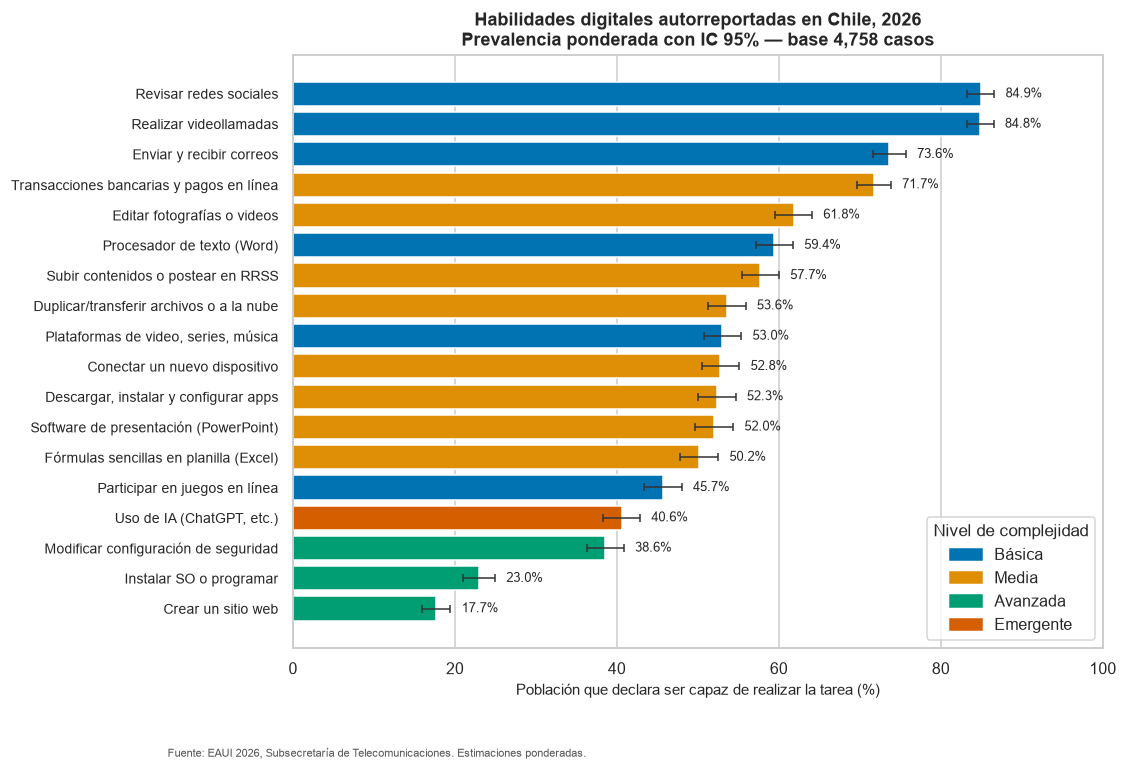

In [ ]:
# ---------------------------------------------------------------------------
# 8.2 Figura: prevalencia por ítem, coloreada por nivel de complejidad
# ---------------------------------------------------------------------------
datos_fig = prevalencia_q8[prevalencia_q8["variable"] != Q8_NINGUNA].copy()
colores_nivel = dict(zip(ORDEN_NIVEL_ITEM, sns.color_palette(PALETA, len(ORDEN_NIVEL_ITEM))))

fig, ax = plt.subplots(figsize=(9.5, 7))
posiciones = np.arange(len(datos_fig))[::-1]
ax.barh(posiciones, datos_fig["pct"],
        xerr=[datos_fig["pct"] - datos_fig["ic_inf"], datos_fig["ic_sup"] - datos_fig["pct"]],
        color=[colores_nivel[n] for n in datos_fig["nivel"]],
        error_kw={"ecolor": "#333333", "elinewidth": 1, "capsize": 2.5})

# La etiqueta se ubica tras el límite superior del IC para no chocar con el bigote
for y, pct, ic_sup in zip(posiciones, datos_fig["pct"], datos_fig["ic_sup"]):
    ax.text(ic_sup + 1.4, y, f"{pct:.1f}%", va="center", fontsize=8.5)

ax.set_yticks(posiciones)
ax.set_yticklabels(datos_fig["tarea"], fontsize=9)
ax.set_xlabel("Población que declara ser capaz de realizar la tarea (%)")
ax.set_title("Habilidades digitales autorreportadas en Chile, 2026\n"
             f"Prevalencia ponderada con IC 95% — base {int(datos_fig['base_n'].max()):,} casos")
ax.set_xlim(0, 100)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=colores_nivel[n]) for n in ORDEN_NIVEL_ITEM],
          labels=ORDEN_NIVEL_ITEM, title="Nivel de complejidad", loc="lower right", frameon=True)
ax.grid(axis="y", visible=False)

print(guardar_figura(fig, "01_prevalencia_habilidades_q8"))
plt.show()

ÍNDICE SUMATIVO DE HABILIDADES (0-18)
Media ponderada : 9.73  IC95% [9.47, 10.00]
Base muestral   : 4,758 | n efectivo 1,769

Distribución ponderada del nivel de habilidades:


,n,casos_expandidos,pct,ic_inf,ic_sup
categoria,,,,,
Sin habilidades,179,"308,563",2.3,1.6,3.0
Básico,801,"1,596,960",12.0,10.5,13.5
Intermedio,2230,"5,699,059",42.9,40.6,45.2
Avanzado,1548,"5,681,644",42.8,40.5,45.1


/Users/tomas/github/eaui2026/outputs/habilidades/02_distribucion_indice_habilidades.png


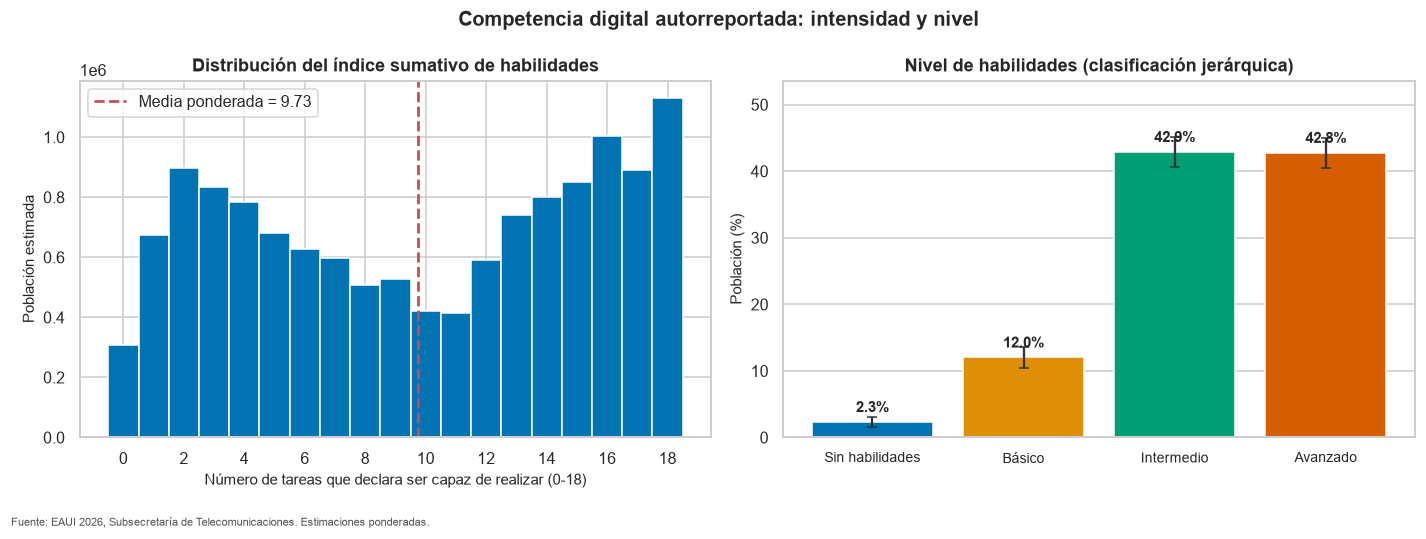

PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/02_nivel_habilidades.csv')

In [ ]:
# ---------------------------------------------------------------------------
# 8.3 Distribución del índice sumativo y del nivel de habilidades
# ---------------------------------------------------------------------------
media, li, ls, n, n_ef = media_ponderada(df["hab_total"], df[PESO_PERSONA])
dist_nivel = distribucion_ponderada(df, "nivel_habilidades", PESO_PERSONA)

titulo("ÍNDICE SUMATIVO DE HABILIDADES (0-18)")
print(f"Media ponderada : {media:.2f}  IC95% [{li:.2f}, {ls:.2f}]")
print(f"Base muestral   : {n:,} | n efectivo {n_ef:,.0f}")
print("\nDistribución ponderada del nivel de habilidades:")
display(dist_nivel.style.format({"casos_expandidos": "{:,.0f}", "pct": "{:.1f}",
                                 "ic_inf": "{:.1f}", "ic_sup": "{:.1f}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

sub_hist = df[["hab_total", PESO_PERSONA]].dropna()
axes[0].hist(sub_hist["hab_total"], bins=np.arange(-0.5, 19.5, 1),
             weights=sub_hist[PESO_PERSONA], color=sns.color_palette(PALETA)[0],
             edgecolor="white")
axes[0].axvline(media, color="#c44e52", linestyle="--", linewidth=1.8,
                label=f"Media ponderada = {media:.2f}")
axes[0].set_xlabel("Número de tareas que declara ser capaz de realizar (0-18)")
axes[0].set_ylabel("Población estimada")
axes[0].set_title("Distribución del índice sumativo de habilidades")
axes[0].set_xticks(range(0, 19, 2))
axes[0].legend()

colores_nivel_hab = sns.color_palette(PALETA, len(ORDEN_NIVEL_HAB))
barras = axes[1].bar(range(len(dist_nivel)), dist_nivel["pct"],
                     yerr=[dist_nivel["pct"] - dist_nivel["ic_inf"],
                           dist_nivel["ic_sup"] - dist_nivel["pct"]],
                     color=colores_nivel_hab, error_kw={"ecolor": "#333333", "capsize": 3})
for barra, pct in zip(barras, dist_nivel["pct"]):
    axes[1].text(barra.get_x() + barra.get_width() / 2, pct + 1.5, f"{pct:.1f}%",
                 ha="center", fontsize=9.5, fontweight="bold")
axes[1].set_xticks(range(len(dist_nivel)))
axes[1].set_xticklabels(dist_nivel.index, fontsize=9)
axes[1].set_ylabel("Población (%)")
axes[1].set_title("Nivel de habilidades (clasificación jerárquica)")
axes[1].set_ylim(0, max(dist_nivel["pct"]) * 1.25)
axes[1].grid(axis="x", visible=False)

fig.suptitle("Competencia digital autorreportada: intensidad y nivel", fontsize=13, fontweight="bold")
fig.tight_layout()
print(guardar_figura(fig, "02_distribucion_indice_habilidades"))
plt.show()
guardar_tabla(dist_nivel, "02_nivel_habilidades")

---
## 9. Dimensionalidad y consistencia del índice

Antes de usar `hab_total` como medida única hay que verificar que los 18 ítems midan algo común.
Tres controles:

1. **Consistencia interna:** KR-20 (equivalente a alfa de Cronbach para ítems dicotómicos).
2. **Estructura de correlaciones:** matriz phi entre ítems y componentes principales.
3. **Jerarquía acumulativa:** coeficiente de reproducibilidad de Guttman. Si las habilidades se
   acumulan jerárquicamente, quien declara una tarea difícil debería declarar también las fáciles.

CONSISTENCIA INTERNA DE LA BATERÍA Q8
KR-20                       : 0.932
Correlación phi media       : 0.422
Ítems / casos               : 18 / 4,758

KR-20 > 0,80 indica que los ítems miden un constructo suficientemente común
como para justificar un índice sumativo único.


/Users/tomas/github/eaui2026/outputs/habilidades/03_correlaciones_q8.png


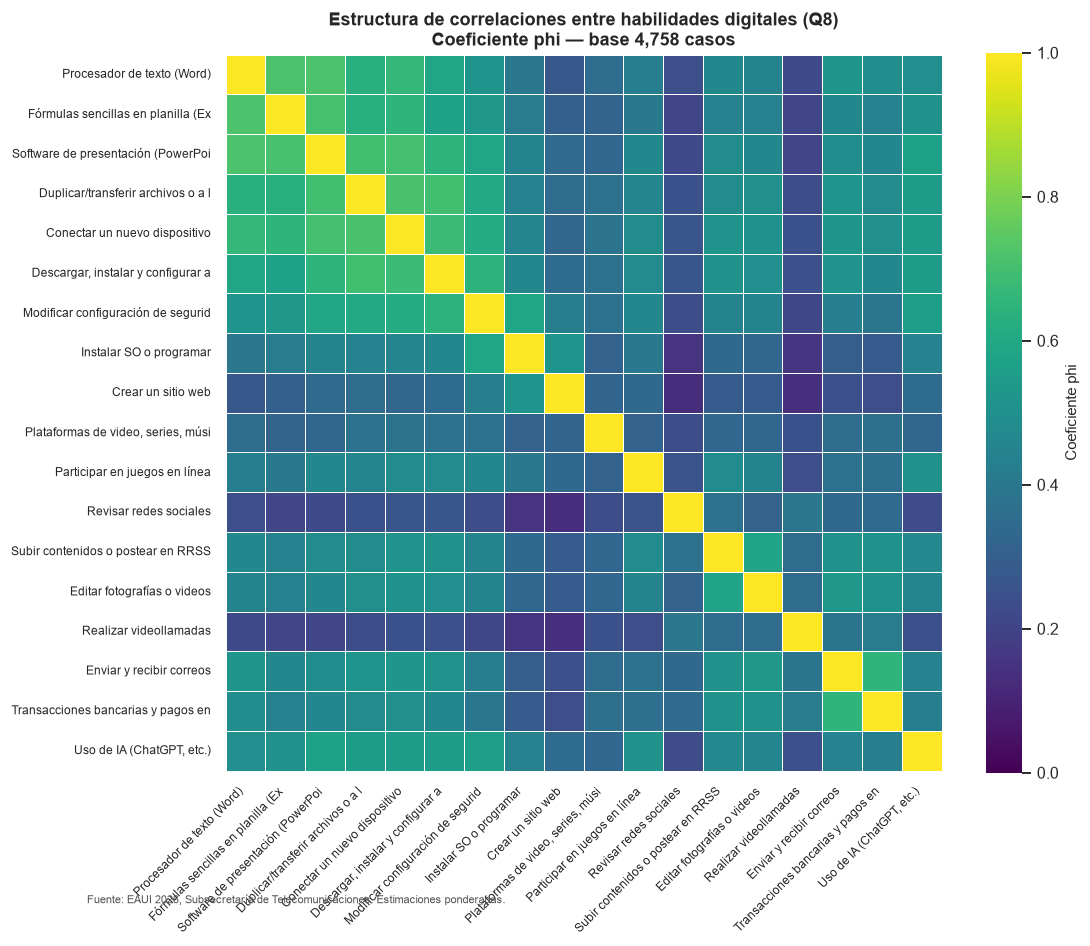

In [ ]:
# ---------------------------------------------------------------------------
# 9.1 Consistencia interna (KR-20) y correlaciones entre ítems
# ---------------------------------------------------------------------------
matriz_q8 = df.loc[en_base_q8, Q8_VARS].astype(float)


def kr20(matriz):
    """KR-20: consistencia interna para ítems dicotómicos."""
    k = matriz.shape[1]
    p = matriz.mean()
    varianza_total = matriz.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - (p * (1 - p)).sum() / varianza_total)


correlaciones = matriz_q8.corr()          # con ítems 0/1 la r de Pearson equivale al coeficiente phi
correlacion_media = correlaciones.to_numpy()[np.triu_indices(len(Q8_VARS), k=1)].mean()

titulo("CONSISTENCIA INTERNA DE LA BATERÍA Q8")
print(f"KR-20                       : {kr20(matriz_q8):.3f}")
print(f"Correlación phi media       : {correlacion_media:.3f}")
print(f"Ítems / casos               : {len(Q8_VARS)} / {len(matriz_q8):,}")
print("\nKR-20 > 0,80 indica que los ítems miden un constructo suficientemente común")
print("como para justificar un índice sumativo único.")

etiquetas_cortas = [Q8_ETIQUETA[v][:34] for v in Q8_VARS]
fig, ax = plt.subplots(figsize=(10.5, 8.5))
sns.heatmap(correlaciones, cmap="viridis", vmin=0, vmax=1, square=True,
            xticklabels=etiquetas_cortas, yticklabels=etiquetas_cortas,
            cbar_kws={"label": "Coeficiente phi"}, linewidths=0.4, ax=ax)
ax.set_title("Estructura de correlaciones entre habilidades digitales (Q8)\n"
             f"Coeficiente phi — base {len(matriz_q8):,} casos")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)
print(guardar_figura(fig, "03_correlaciones_q8"))
plt.show()

DIMENSIONALIDAD Y JERARQUÍA
Varianza explicada CP1 : 49.5%
Varianza explicada CP2 : 7.6%
Componentes con autovalor > 1 : 1

Coeficiente de reproducibilidad de Guttman : 0.854
Reproducibilidad mínima marginal           : 0.649
Ganancia sobre el piso marginal            : +0.205

CR = 0.854, por debajo del umbral convencional de 0,90. La batería es
marcadamente unidimensional (un solo autovalor > 1, CP1 explica la mitad de la
varianza) pero NO cumple una jerarquía de Guttman estricta: hay perfiles de
habilidad no anidados, típicamente quienes dominan tareas de comunicación y
entretenimiento sin las ofimáticas. El índice sumativo sigue siendo defendible;
interpretarlo como una escala ordinal estricta, no.


/Users/tomas/github/eaui2026/outputs/habilidades/04_dimensionalidad_guttman.png


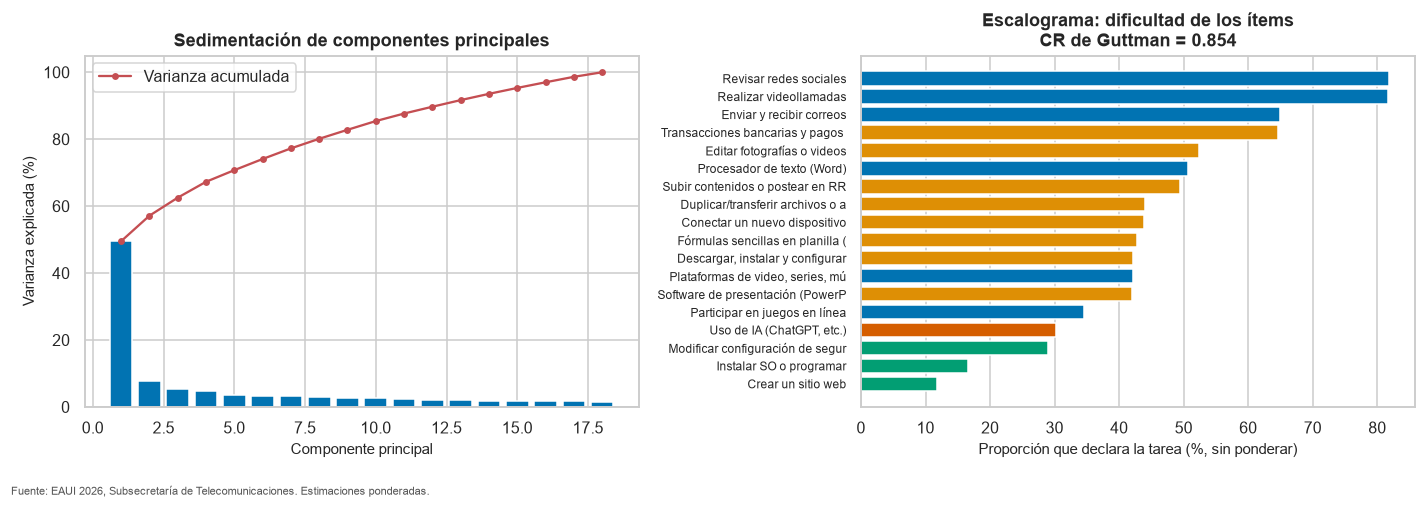

In [ ]:
# ---------------------------------------------------------------------------
# 9.2 Componentes principales y escalograma de Guttman
# ---------------------------------------------------------------------------
from sklearn.decomposition import PCA

pca = PCA(random_state=SEMILLA).fit(matriz_q8)
varianza = pca.explained_variance_ratio_

# Coeficiente de reproducibilidad de Guttman: ordena los ítems por dificultad y compara
# el patrón observado con el patrón acumulativo perfecto implicado por el puntaje total.
orden_dificultad = matriz_q8.mean().sort_values(ascending=False).index.tolist()
observado = matriz_q8[orden_dificultad].to_numpy()
puntajes = observado.sum(axis=1).astype(int)
esperado = (np.arange(len(orden_dificultad))[None, :] < puntajes[:, None]).astype(int)
reproducibilidad = 1 - np.abs(observado - esperado).sum() / observado.size

# Reproducibilidad mínima marginal: media de max(p, 1-p) por ítem. Es el piso que se
# alcanzaría prediciendo siempre la respuesta modal, y sirve de referencia para el CR.
proporciones = matriz_q8[orden_dificultad].mean().to_numpy()
reproducibilidad_minima = np.maximum(proporciones, 1 - proporciones).mean()

titulo("DIMENSIONALIDAD Y JERARQUÍA")
print(f"Varianza explicada CP1 : {varianza[0]*100:.1f}%")
print(f"Varianza explicada CP2 : {varianza[1]*100:.1f}%")
print(f"Componentes con autovalor > 1 : {(pca.explained_variance_ > 1).sum()}")
print(f"\nCoeficiente de reproducibilidad de Guttman : {reproducibilidad:.3f}")
print(f"Reproducibilidad mínima marginal           : {reproducibilidad_minima:.3f}")
print(f"Ganancia sobre el piso marginal            : {reproducibilidad - reproducibilidad_minima:+.3f}")
print()
if reproducibilidad >= 0.90:
    print("CR >= 0,90: la batería se comporta como una escala acumulativa estricta.")
    print("Declarar una tarea difícil implica, casi siempre, declarar también las fáciles.")
else:
    print(f"CR = {reproducibilidad:.3f}, por debajo del umbral convencional de 0,90. La batería es")
    print("marcadamente unidimensional (un solo autovalor > 1, CP1 explica la mitad de la")
    print("varianza) pero NO cumple una jerarquía de Guttman estricta: hay perfiles de")
    print("habilidad no anidados, típicamente quienes dominan tareas de comunicación y")
    print("entretenimiento sin las ofimáticas. El índice sumativo sigue siendo defendible;")
    print("interpretarlo como una escala ordinal estricta, no.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

axes[0].bar(range(1, len(varianza) + 1), varianza * 100,
            color=sns.color_palette(PALETA)[0])
axes[0].plot(range(1, len(varianza) + 1), np.cumsum(varianza) * 100,
             color="#c44e52", marker="o", markersize=3.5, linewidth=1.5,
             label="Varianza acumulada")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Sedimentación de componentes principales")
axes[0].legend()

dificultad = matriz_q8.mean().sort_values()
colores_dif = [colores_nivel[Q8_NIVEL[v]] for v in dificultad.index]
axes[1].barh(range(len(dificultad)), dificultad.to_numpy() * 100, color=colores_dif)
axes[1].set_yticks(range(len(dificultad)))
axes[1].set_yticklabels([Q8_ETIQUETA[v][:32] for v in dificultad.index], fontsize=8)
axes[1].set_xlabel("Proporción que declara la tarea (%, sin ponderar)")
axes[1].set_title(f"Escalograma: dificultad de los ítems\nCR de Guttman = {reproducibilidad:.3f}")
axes[1].grid(axis="y", visible=False)

fig.tight_layout()
print(guardar_figura(fig, "04_dimensionalidad_guttman"))
plt.show()

---
## 10. Inventario de variables de cruce

Resultado de la revisión sistemática de las 587 variables del archivo. Se listan aquí todas las
variables demográficas, educacionales, laborales, ocupacionales, territoriales y de contexto que
son cruzables con las baterías de habilidad, con su nivel de medición y su base válida.

**Hallazgo relevante:** `Q2` (actividad principal: ocupado, cesante, jubilado, estudiante…) está
**completamente vacía** en el archivo. Es la variable que faltaría para una caracterización laboral
canónica. Se sustituye por `Q1_4` (ocupación en la escala ESOMAR del respondente) y por la batería
`A14_*` (situaciones laborales presentes en el hogar), que sí tienen datos.

In [ ]:
# ---------------------------------------------------------------------------
# 10.1 Registro de variables de cruce disponibles
# ---------------------------------------------------------------------------
# (variable derivada, etiqueta, dominio, nivel de medición, variable SPSS de origen)
VARIABLES_CRUCE = [
    # --- Demográficas (persona) ---
    ("sexo",                     "Sexo",                              "Demográfica",  "Persona", "Q1_2"),
    ("tramo_edad",               "Tramo de edad",                     "Demográfica",  "Persona", "Q1_1"),
    ("generacion",               "Generación",                        "Demográfica",  "Persona", "Q1_1"),
    ("pueblo_originario",        "Pertenencia a pueblo originario",   "Demográfica",  "Persona", "Q1_5_*"),
    ("condicion_larga_duracion", "Condición de larga duración",       "Demográfica",  "Persona", "Q1_6_*"),
    ("parentesco_jh",            "Parentesco con el jefe/a de hogar", "Demográfica",  "Persona", "A9"),
    # --- Territoriales ---
    ("zona",                     "Zona urbana / rural",               "Territorial",  "Hogar",   "ZONA"),
    ("region",                   "Región",                            "Territorial",  "Hogar",   "COD_REGION"),
    ("macrozona",                "Macrozona",                         "Territorial",  "Hogar",   "COD_REGION"),
    # --- Educacionales ---
    ("educ",                     "Nivel educacional del respondente", "Educación",    "Persona", "Q1_3"),
    ("educ_grupo",               "Nivel educacional agrupado",        "Educación",    "Persona", "Q1_3"),
    ("educ_jh",                  "Nivel educacional del jefe/a de hogar", "Educación","Hogar",   "A10"),
    ("educ_jh_grupo",            "Educación del jefe/a agrupada",     "Educación",    "Hogar",   "A10"),
    ("hogar_con_estudiantes",    "Hay estudiantes en el hogar",       "Educación",    "Hogar",   "A14_5"),
    # --- Laborales y ocupacionales ---
    ("ocupacion_encuestado",     "Ocupación del respondente (ESOMAR)","Ocupacional",  "Persona", "Q1_4"),
    ("ocupado",                  "Tiene trabajo remunerado",          "Laboral",      "Persona", "Q1_4"),
    ("ocupacion_jh",             "Ocupación del jefe/a de hogar",     "Ocupacional",  "Hogar",   "A11"),
    ("situacion_laboral_hogar",  "Situación laboral del hogar",       "Laboral",      "Hogar",   "A14_*"),
    ("hogar_con_cesantes",       "Hay cesantes en el hogar",          "Laboral",      "Hogar",   "A14_3/A14_4"),
    # --- Socioeconómicas ---
    ("gse",                      "Grupo socioeconómico (AIM-ESOMAR)", "Socioeconómica","Hogar",  "A10 × A11"),
    ("gse_grupo",                "GSE agrupado",                      "Socioeconómica","Hogar",  "A10 × A11"),
    ("ingreso_tramo_rel",        "Tramo de ingreso (posición relativa)","Socioeconómica","Hogar", "A12_1"),
    ("quintil_ingreso",          "Quintil de ingreso familiar",       "Socioeconómica","Hogar",  "A12_1"),
    # --- Composición y equipamiento del hogar ---
    ("hogar_con_menores",        "Hay menores de edad en el hogar",   "Hogar",        "Hogar",   "filtro P7"),
    ("acceso_internet_hogar",    "Acceso a internet en el hogar",     "Hogar",        "Hogar",   "P1"),
    ("tiene_computador",         "Hay computador en el hogar",        "Hogar",        "Hogar",   "P2_1"),
    # --- Exposición y uso ---
    ("uso_computador",           "Usó computador la última semana",   "Exposición",   "Persona", "Q5"),
    ("uso_smartphone",           "Usa smartphone habitualmente",      "Exposición",   "Persona", "Q7"),
    ("smartphone_propio",        "El smartphone es propio",           "Exposición",   "Persona", "Q7_1"),
    ("computador_uso",           "El computador es propio o compartido","Exposición",  "Persona", "Q6_1"),
    ("usuario_internet",         "Usuario de internet",               "Exposición",   "Persona", "Q9"),
    ("ultimo_uso_internet",      "Última vez que usó internet",       "Exposición",   "Persona", "Q9"),
    ("frecuencia_internet",      "Frecuencia de uso de internet",     "Exposición",   "Persona", "Q10"),
    ("tiempo_diario_internet",   "Tiempo diario de conexión",         "Exposición",   "Persona", "Q11"),
    # --- Percepción ---
    ("percepcion_proteccion",    "Percepción de protección",          "Percepción",   "Persona", "Q31"),
    ("internet_facilita_trabajo","Internet facilita trabajo/estudio", "Percepción",   "Persona", "Q23"),
]

inventario = pd.DataFrame(VARIABLES_CRUCE,
                          columns=["variable", "etiqueta", "dominio", "nivel", "origen_spss"])
inventario["n_valido"] = [int(df[v].notna().sum()) for v in inventario["variable"]]
inventario["pct_valido"] = 100 * inventario["n_valido"] / len(df)
inventario["n_categorias"] = [int(df[v].nunique()) for v in inventario["variable"]]
inventario = inventario.set_index("variable")

titulo("INVENTARIO DE VARIABLES DE CRUCE")
display(inventario)
print("\nPor dominio:")
print(inventario["dominio"].value_counts().to_string())
guardar_tabla(inventario, "05_inventario_variables_cruce")

INVENTARIO DE VARIABLES DE CRUCE


,etiqueta,dominio,nivel,origen_spss,n_valido,pct_valido,n_categorias
variable,,,,,,,
sexo,Sexo,Demográfica,Persona,Q1_2,5000,100.00,2
tramo_edad,Tramo de edad,Demográfica,Persona,Q1_1,5000,100.00,5
generacion,Generación,Demográfica,Persona,Q1_1,5000,100.00,5
pueblo_originario,Pertenencia a pueblo originario,Demográfica,Persona,Q1_5_*,5000,100.00,2
condicion_larga_duracion,Condición de larga duración,Demográfica,Persona,Q1_6_*,5000,100.00,2
parentesco_jh,Parentesco con el jefe/a de hogar,Demográfica,Persona,A9,5000,100.00,12
zona,Zona urbana / rural,Territorial,Hogar,ZONA,5000,100.00,2
region,Región,Territorial,Hogar,COD_REGION,5000,100.00,16
macrozona,Macrozona,Territorial,Hogar,COD_REGION,5000,100.00,4



Por dominio:
dominio
Exposición        8
Demográfica       6
Educación         5
Socioeconómica    4
Territorial       3
Laboral           3
Hogar             3
Ocupacional       2
Percepción        2


PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/05_inventario_variables_cruce.csv')

In [ ]:
# ---------------------------------------------------------------------------
# 10.2 Variables descartadas y por qué
# ---------------------------------------------------------------------------
DESCARTADAS = [
    ("Q2",      "Actividad principal (ocupado, cesante, jubilado, estudiante)",
     "Sin ningún dato válido en el archivo (n = 0). Es la pérdida más relevante para el análisis laboral."),
    ("Q40_1",   "Disposición a pagar por computador fijo", "Sin datos válidos (n = 0)."),
    ("Q40_2",   "Disposición a pagar por laptop",          "Sin datos válidos (n = 0)."),
    ("Q40_3",   "Disposición a pagar por netbook",         "Sin datos válidos (n = 0)."),
    ("Q1",      "Parentesco con el jefe de hogar (módulo Q)",
     "Solo 3 casos válidos. Se usa A9, que está completa."),
    ("Q1_3_1",  "Duplicado de nivel educacional", "Constante (un solo valor)."),
    ("Q1_4_1",  "Duplicado de ocupación",         "Constante (un solo valor)."),
    ("COMUNA_DEF", "Comuna",
     "90 categorías con muy pocos casos por celda. No admite cruces con control de error."),
    ("Q38_1..Q38_6", "Jerarquización de actividades delegadas",
     "Sin enunciado matriz en las etiquetas y n entre 2 y 43. No interpretable sin el cuestionario."),
]

tabla_descartadas = pd.DataFrame(DESCARTADAS, columns=["variable", "contenido", "motivo de descarte"])
titulo("VARIABLES REVISADAS Y DESCARTADAS COMO CRUCE")
display(tabla_descartadas.set_index("variable"))
guardar_tabla(tabla_descartadas.set_index("variable"), "05b_variables_descartadas")

VARIABLES REVISADAS Y DESCARTADAS COMO CRUCE


,contenido,motivo de descarte
variable,,
Q2,"Actividad principal (ocupado, cesante, jubilad...",Sin ningún dato válido en el archivo (n = 0). ...
Q40_1,Disposición a pagar por computador fijo,Sin datos válidos (n = 0).
Q40_2,Disposición a pagar por laptop,Sin datos válidos (n = 0).
Q40_3,Disposición a pagar por netbook,Sin datos válidos (n = 0).
Q1,Parentesco con el jefe de hogar (módulo Q),"Solo 3 casos válidos. Se usa A9, que está comp..."
Q1_3_1,Duplicado de nivel educacional,Constante (un solo valor).
Q1_4_1,Duplicado de ocupación,Constante (un solo valor).
COMUNA_DEF,Comuna,90 categorías con muy pocos casos por celda. N...
Q38_1..Q38_6,Jerarquización de actividades delegadas,Sin enunciado matriz en las etiquetas y n entr...


PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/05b_variables_descartadas.csv')

---
## 11. Cruces sistemáticos: brechas de habilidad digital

Dos salidas complementarias:

- **Mapa de asociaciones:** para cada variable de cruce, la V de Cramér contra `nivel_habilidades`,
  con p-valor corregido por Benjamini-Hochberg. Permite ordenar los factores por su capacidad
  estructurante, en lugar de mirar cruces de a uno.
- **Perfiles detallados:** para los factores más relevantes, la media ponderada de `hab_total` con
  intervalo de confianza y la distribución interna de niveles.

In [ ]:
# ---------------------------------------------------------------------------
# 11.1 Mapa de asociaciones: qué estructura la competencia digital
# ---------------------------------------------------------------------------
CRUCES_PERSONA = [
    "sexo", "tramo_edad", "generacion", "educ_grupo", "educ", "ocupacion_encuestado", "ocupado",
    "gse", "gse_grupo", "quintil_ingreso", "ingreso_tramo_rel", "zona", "macrozona", "region",
    "pueblo_originario", "condicion_larga_duracion", "situacion_laboral_hogar",
    "hogar_con_cesantes", "hogar_con_estudiantes", "hogar_con_menores",
    "educ_jh_grupo", "ocupacion_jh", "acceso_internet_hogar", "tiene_computador",
    "uso_computador", "uso_smartphone", "smartphone_propio", "computador_uso",
    "frecuencia_internet", "tiempo_diario_internet", "percepcion_proteccion",
    "internet_facilita_trabajo",
]

resultados = [asociacion(df, cruce, "nivel_habilidades", PESO_PERSONA) for cruce in CRUCES_PERSONA]
mapa_asociaciones = pd.DataFrame(resultados)
significativo, p_ajustado = correccion_bh(mapa_asociaciones["p"].to_numpy())
mapa_asociaciones["p_ajustado_bh"] = p_ajustado
mapa_asociaciones["significativo"] = significativo
mapa_asociaciones = (mapa_asociaciones
                     .merge(inventario[["etiqueta", "dominio"]], left_on="variable",
                            right_index=True, how="left")
                     .sort_values("cramers_v", ascending=False)
                     .reset_index(drop=True))

titulo("ASOCIACIÓN DE CADA FACTOR CON EL NIVEL DE HABILIDADES DIGITALES")
display(mapa_asociaciones[["variable", "etiqueta", "dominio", "n", "cramers_v",
                           "interpretacion", "p_ajustado_bh", "significativo"]]
        .style.format({"cramers_v": "{:.3f}", "p_ajustado_bh": "{:.2e}"}))
print(f"\nFactores evaluados: {len(mapa_asociaciones)} | "
      f"significativos tras BH: {int(mapa_asociaciones['significativo'].sum())}")
guardar_tabla(mapa_asociaciones.set_index("variable"), "06_mapa_asociaciones")

ASOCIACIÓN DE CADA FACTOR CON EL NIVEL DE HABILIDADES DIGITALES


,variable,etiqueta,dominio,n,cramers_v,interpretacion,p_ajustado_bh,significativo
0,uso_computador,Usó computador la última semana,Exposición,4758,0.474,fuerte,8.65e-231,True
1,tiene_computador,Hay computador en el hogar,Hogar,4697,0.383,fuerte,5.39e-148,True
2,educ_grupo,Nivel educacional agrupado,Educación,4758,0.373,fuerte,3.57e-282,True
3,internet_facilita_trabajo,Internet facilita trabajo/estudio,Percepción,4652,0.358,fuerte,7.87e-129,True
4,educ,Nivel educacional del respondente,Educación,4758,0.338,fuerte,0.00e+00,True
5,generacion,Generación,Demográfica,4758,0.293,moderada,2.19e-253,True
6,tramo_edad,Tramo de edad,Demográfica,4758,0.289,moderada,1.28e-246,True
7,educ_jh_grupo,Educación del jefe/a agrupada,Educación,4758,0.265,moderada,1.23e-140,True
8,computador_uso,El computador es propio o compartido,Exposición,3678,0.247,moderada,1.07e-93,True
9,tiempo_diario_internet,Tiempo diario de conexión,Exposición,4171,0.233,moderada,1.96e-140,True



Factores evaluados: 32 | significativos tras BH: 30


PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/06_mapa_asociaciones.csv')

/Users/tomas/github/eaui2026/outputs/habilidades/05_ranking_factores.png


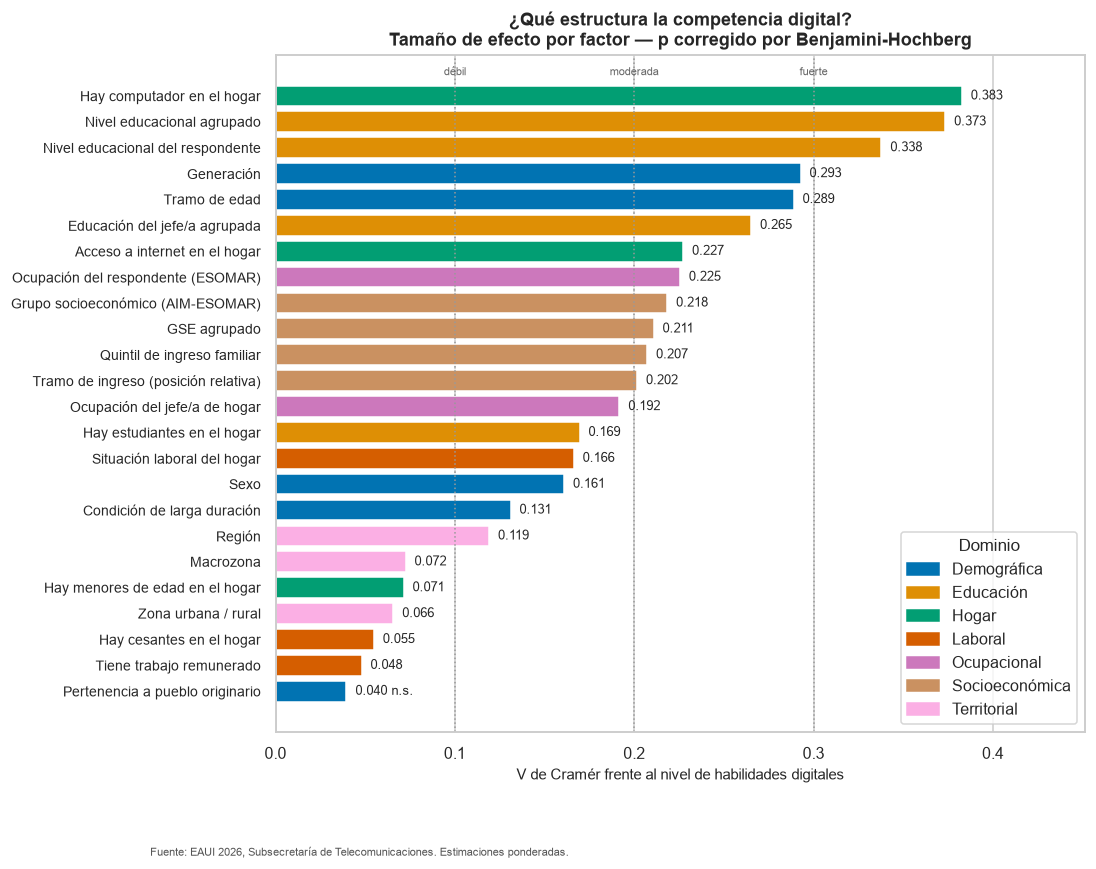

In [ ]:
# ---------------------------------------------------------------------------
# 11.2 Figura: ranking de factores por tamaño de efecto
# ---------------------------------------------------------------------------
# Se excluyen las variables de exposición al uso: su asociación con la habilidad es en parte
# tautológica (quien no usa internet difícilmente declara saber usarlo).
ESTRUCTURALES = mapa_asociaciones[
    ~mapa_asociaciones["dominio"].isin(["Exposición", "Percepción"])].copy()

paleta_dominio = dict(zip(sorted(ESTRUCTURALES["dominio"].unique()),
                          sns.color_palette(PALETA, ESTRUCTURALES["dominio"].nunique())))

fig, ax = plt.subplots(figsize=(9.5, 8))
posiciones = np.arange(len(ESTRUCTURALES))[::-1]
ax.barh(posiciones, ESTRUCTURALES["cramers_v"],
        color=[paleta_dominio[d] for d in ESTRUCTURALES["dominio"]])
for y, (v, sig) in zip(posiciones, zip(ESTRUCTURALES["cramers_v"], ESTRUCTURALES["significativo"])):
    ax.text(v + 0.005, y, f"{v:.3f}{'' if sig else ' n.s.'}", va="center", fontsize=8.5)

for corte, etiqueta_corte in [(0.10, "débil"), (0.20, "moderada"), (0.30, "fuerte")]:
    ax.axvline(corte, color="#999999", linestyle=":", linewidth=1)
    ax.text(corte, len(ESTRUCTURALES) - 0.2, etiqueta_corte, fontsize=7.5,
            color="#666666", ha="center")

ax.set_yticks(posiciones)
ax.set_yticklabels(ESTRUCTURALES["etiqueta"], fontsize=9)
ax.set_xlabel("V de Cramér frente al nivel de habilidades digitales")
ax.set_title("¿Qué estructura la competencia digital?\n"
             "Tamaño de efecto por factor — p corregido por Benjamini-Hochberg")
ax.set_xlim(0, max(ESTRUCTURALES["cramers_v"]) * 1.18)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in paleta_dominio.values()],
          labels=list(paleta_dominio), title="Dominio", loc="lower right")
ax.grid(axis="y", visible=False)

print(guardar_figura(fig, "05_ranking_factores"))
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# 11.3 Perfiles detallados: media del índice por categoría
# ---------------------------------------------------------------------------
def perfil_habilidades(datos, variable, peso=None, indice="hab_total"):
    """Media ponderada del índice por categoría, con IC 95% y n."""
    peso = peso or PESO_PERSONA
    sub = datos[[variable, indice, peso]].dropna()
    categorias = (sub[variable].cat.categories
                  if isinstance(sub[variable].dtype, pd.CategoricalDtype)
                  else sorted(sub[variable].unique(), key=str))
    filas = []
    for categoria in categorias:
        bloque = sub[sub[variable] == categoria]
        if bloque.empty:
            continue
        media_c, li, ls, n_c, n_ef = media_ponderada(bloque[indice], bloque[peso])
        filas.append({"categoria": categoria, "media": media_c, "ic_inf": li, "ic_sup": ls,
                      "n": n_c, "n_efectivo": n_ef,
                      "poblacion": float(bloque[peso].sum())})
    tabla = pd.DataFrame(filas).set_index("categoria")
    media_global = media_ponderada(sub[indice], sub[peso])[0]
    tabla["dif_vs_total"] = tabla["media"] - media_global
    tabla.attrs["media_global"] = media_global
    return tabla


FACTORES_CLAVE = ["tramo_edad", "educ_grupo", "gse", "quintil_ingreso",
                  "ocupacion_encuestado", "zona"]

for factor in FACTORES_CLAVE:
    tabla = perfil_habilidades(df, factor)
    titulo(f"HABILIDADES POR {inventario.loc[factor, 'etiqueta'].upper()}")
    print(f"Media global ponderada: {tabla.attrs['media_global']:.2f} tareas de 18\n")
    display(tabla.style.format({"media": "{:.2f}", "ic_inf": "{:.2f}", "ic_sup": "{:.2f}",
                                "dif_vs_total": "{:+.2f}", "poblacion": "{:,.0f}",
                                "n_efectivo": "{:,.0f}"}))
    guardar_tabla(tabla, f"07_perfil_{factor}")

HABILIDADES POR TRAMO DE EDAD
Media global ponderada: 9.73 tareas de 18



,media,ic_inf,ic_sup,n,n_efectivo,poblacion,dif_vs_total
categoria,,,,,,,
Menor de 18,12.30,10.30,14.30,40,16,"165,664",+2.57
18-29,12.44,11.93,12.96,876,346,"3,548,813",+2.71
30-44,11.55,11.11,11.99,1335,522,"4,095,067",+1.81
45-59,8.16,7.69,8.64,1248,494,"2,825,372",-1.57
60 y más,4.82,4.44,5.20,1259,524,"2,651,309",-4.92


HABILIDADES POR NIVEL EDUCACIONAL AGRUPADO
Media global ponderada: 9.73 tareas de 18



,media,ic_inf,ic_sup,n,n_efectivo,poblacion,dif_vs_total
categoria,,,,,,,
Básica o menos,3.72,3.26,4.19,651,229,"1,274,192",-6.01
Media,7.69,7.36,8.03,2303,911,"5,603,490",-2.04
Superior,12.71,12.35,13.07,1804,705,"6,408,544",+2.98


HABILIDADES POR GRUPO SOCIOECONÓMICO (AIM-ESOMAR)
Media global ponderada: 9.73 tareas de 18



...

,media,ic_inf,ic_sup,n,n_efectivo,poblacion,dif_vs_total
categoria,,,,,,,
Q1 (menor),7.53,6.87,8.18,850,315,"2,199,282",-2.55
Q2,7.97,7.42,8.53,905,371,"1,990,665",-2.10
Q3,9.51,8.96,10.06,902,370,"2,150,168",-0.57
Q4,11.32,10.78,11.85,833,356,"2,391,344",+1.24
Q5 (mayor),14.00,13.42,14.57,515,197,"2,048,738",+3.92


HABILIDADES POR OCUPACIÓN DEL RESPONDENTE (ESOMAR)
Media global ponderada: 9.73 tareas de 18



,media,ic_inf,ic_sup,n,n_efectivo,poblacion,dif_vs_total
categoria,,,,,,,
Alto ejecutivo - empresario - directivo,12.76,9.77,15.75,25,13,"142,136",+3.03
Ejecutivo medio - prof. universitario,14.04,13.32,14.76,337,141,"1,297,550",+4.31
Empleado medio - técnico - prof. independiente,11.49,11.02,11.96,1279,487,"4,174,293",+1.75
Obrero calificado - microempresario,7.57,7.11,8.03,1234,489,"3,083,058",-2.16
Oficio menor - obrero no calificado,5.64,5.00,6.28,446,227,"856,643",-4.09
Sin trabajo remunerado,10.14,9.51,10.76,813,286,"2,534,172",+0.40
Trabajos ocasionales e informales,6.24,5.60,6.88,624,268,"1,198,373",-3.49


HABILIDADES POR ZONA URBANA / RURAL
Media global ponderada: 9.73 tareas de 18



,media,ic_inf,ic_sup,n,n_efectivo,poblacion,dif_vs_total
categoria,,,,,,,
Rural,8.88,8.57,9.20,1312,"1,190","1,620,967",-0.85
Urbana,9.85,9.55,10.16,3446,"1,395","11,665,259",+0.12


/Users/tomas/github/eaui2026/outputs/habilidades/06_brechas_por_factor.png


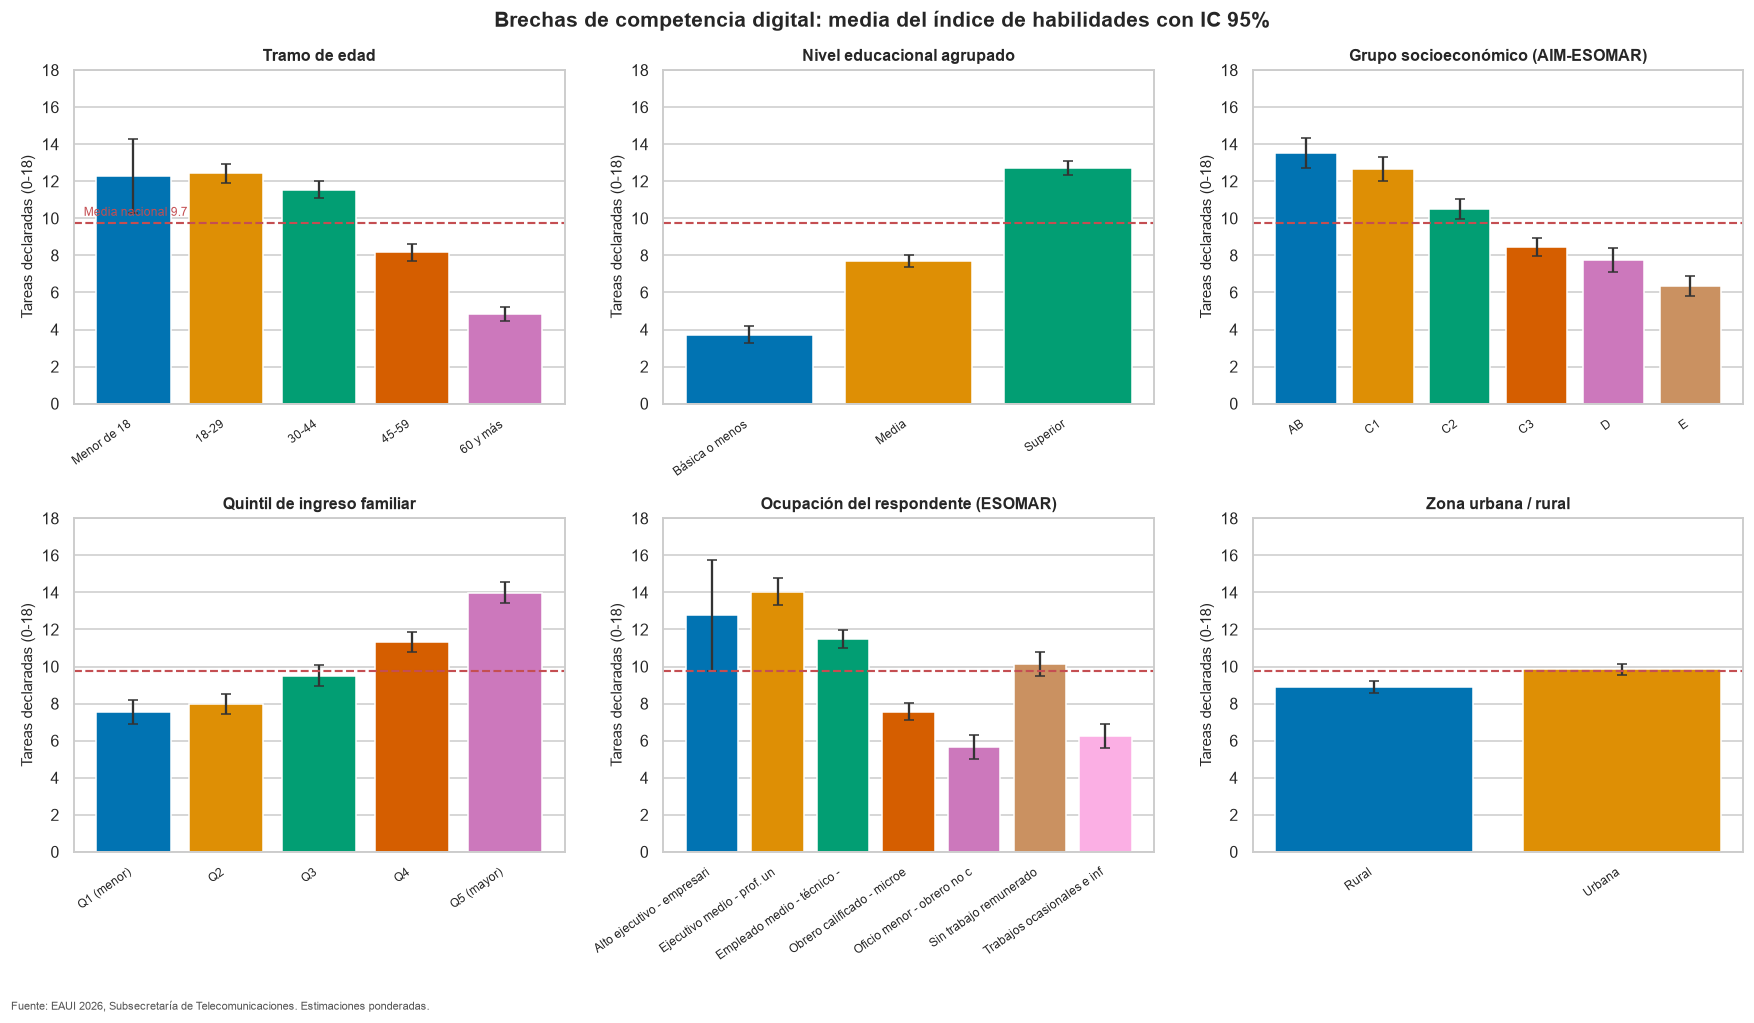

In [ ]:
# ---------------------------------------------------------------------------
# 11.4 Figura: medias del índice por factor sociodemográfico
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
media_global = media_ponderada(df["hab_total"], df[PESO_PERSONA])[0]

for ax, factor in zip(axes.ravel(), FACTORES_CLAVE):
    tabla = perfil_habilidades(df, factor)
    etiquetas = [str(c)[:26] for c in tabla.index]
    posiciones = np.arange(len(tabla))
    ax.bar(posiciones, tabla["media"],
           yerr=[tabla["media"] - tabla["ic_inf"], tabla["ic_sup"] - tabla["media"]],
           color=sns.color_palette(PALETA, len(tabla)),
           error_kw={"ecolor": "#333333", "capsize": 3})
    ax.axhline(media_global, color="#c44e52", linestyle="--", linewidth=1.4)
    ax.set_xticks(posiciones)
    ax.set_xticklabels(etiquetas, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Tareas declaradas (0-18)")
    ax.set_title(inventario.loc[factor, "etiqueta"], fontsize=10.5)
    ax.set_ylim(0, 18)
    ax.grid(axis="x", visible=False)

axes.ravel()[0].text(0.02, media_global + 0.4, f"Media nacional {media_global:.1f}",
                     color="#c44e52", fontsize=8, transform=axes.ravel()[0].get_yaxis_transform())
fig.suptitle("Brechas de competencia digital: media del índice de habilidades con IC 95%",
             fontsize=13.5, fontweight="bold")
fig.tight_layout()
print(guardar_figura(fig, "06_brechas_por_factor"))
plt.show()

/Users/tomas/github/eaui2026/outputs/habilidades/07_composicion_nivel_por_factor.png


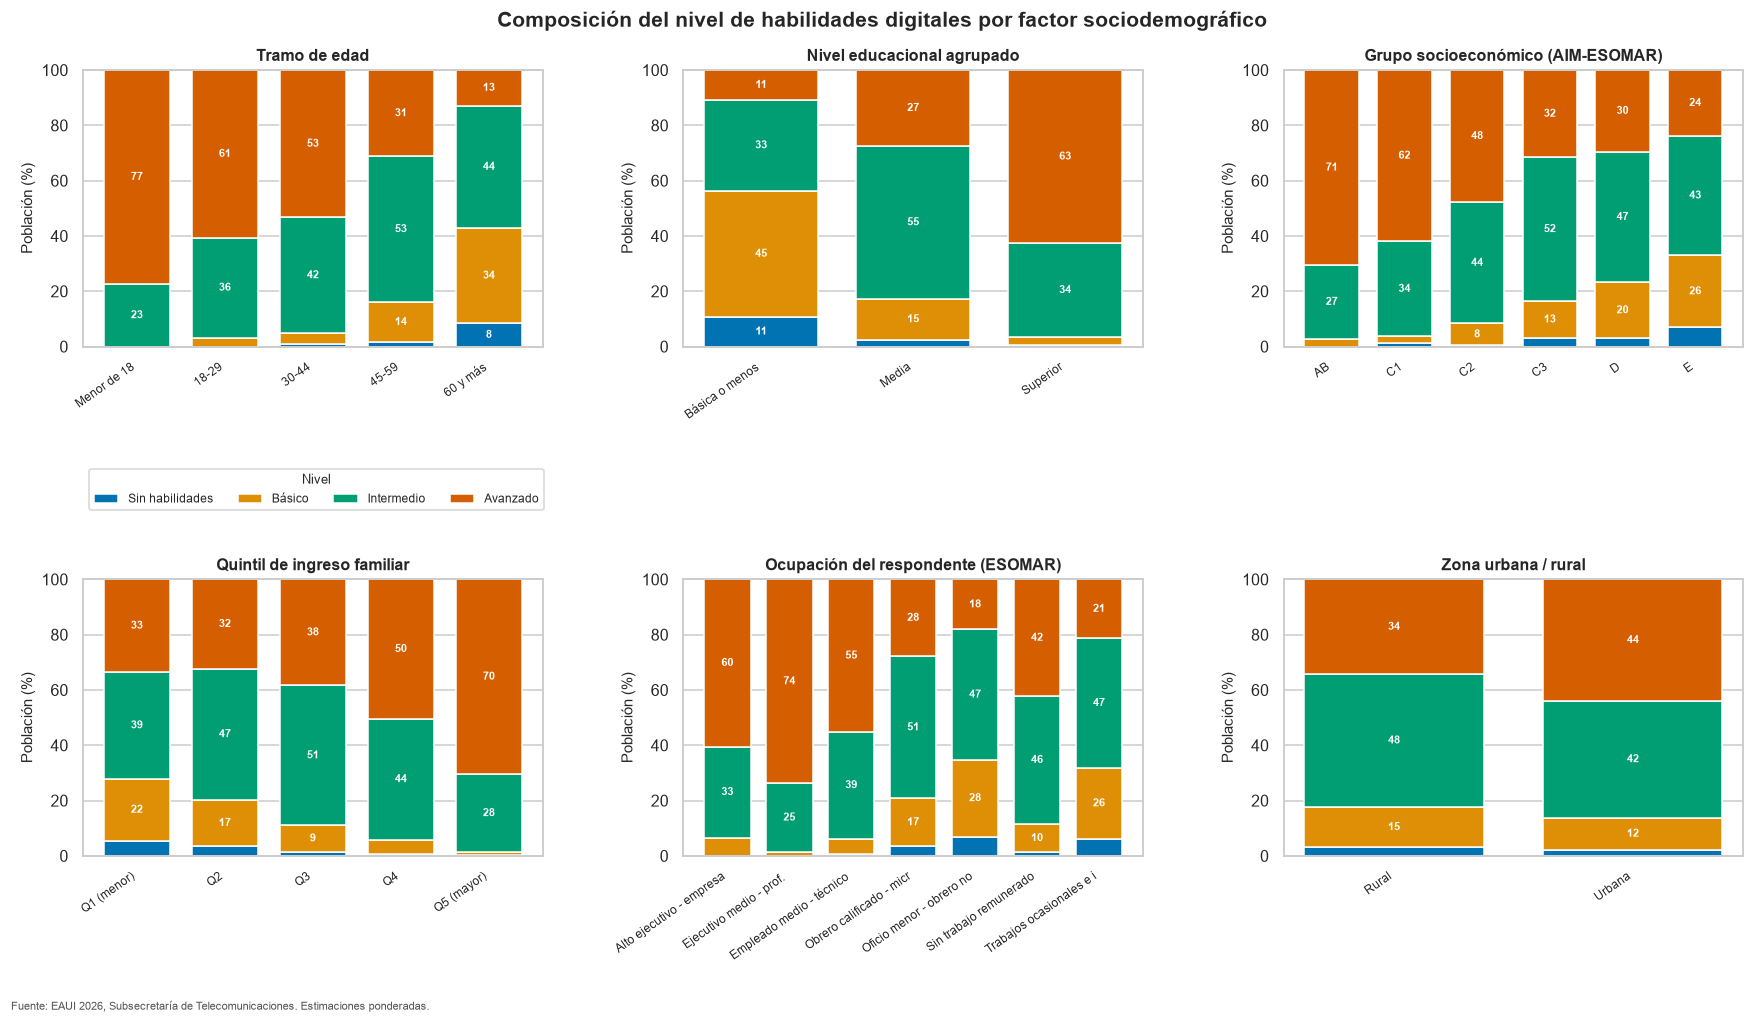

In [ ]:
# ---------------------------------------------------------------------------
# 11.5 Composición del nivel de habilidades dentro de cada factor
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
colores_nivel_hab = dict(zip(ORDEN_NIVEL_HAB, sns.color_palette(PALETA, len(ORDEN_NIVEL_HAB))))

for ax, factor in zip(axes.ravel(), FACTORES_CLAVE):
    tabla = tabla_cruzada_ponderada(df, factor, "nivel_habilidades", PESO_PERSONA)
    tabla = tabla.reindex(columns=[c for c in ORDEN_NIVEL_HAB if c in tabla.columns])
    acumulado = np.zeros(len(tabla))
    posiciones = np.arange(len(tabla))
    for nivel in tabla.columns:
        ax.bar(posiciones, tabla[nivel], bottom=acumulado,
               color=colores_nivel_hab[nivel], label=nivel, width=0.75)
        for x, (valor, base) in enumerate(zip(tabla[nivel], acumulado)):
            if valor >= 7:
                ax.text(x, base + valor / 2, f"{valor:.0f}", ha="center", va="center",
                        fontsize=7.5, color="white", fontweight="bold")
        acumulado += tabla[nivel].to_numpy()
    ax.set_xticks(posiciones)
    ax.set_xticklabels([str(c)[:24] for c in tabla.index], rotation=35, ha="right", fontsize=8)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Población (%)")
    ax.set_title(inventario.loc[factor, "etiqueta"], fontsize=10.5)
    ax.grid(axis="x", visible=False)

axes.ravel()[0].legend(title="Nivel", fontsize=8, title_fontsize=8.5,
                       loc="upper left", bbox_to_anchor=(0, -0.42), ncol=4)
fig.suptitle("Composición del nivel de habilidades digitales por factor sociodemográfico",
             fontsize=13.5, fontweight="bold")
fig.tight_layout()
print(guardar_figura(fig, "07_composicion_nivel_por_factor"))
plt.show()

/Users/tomas/github/eaui2026/outputs/habilidades/08_heatmap_items_edad_educacion.png


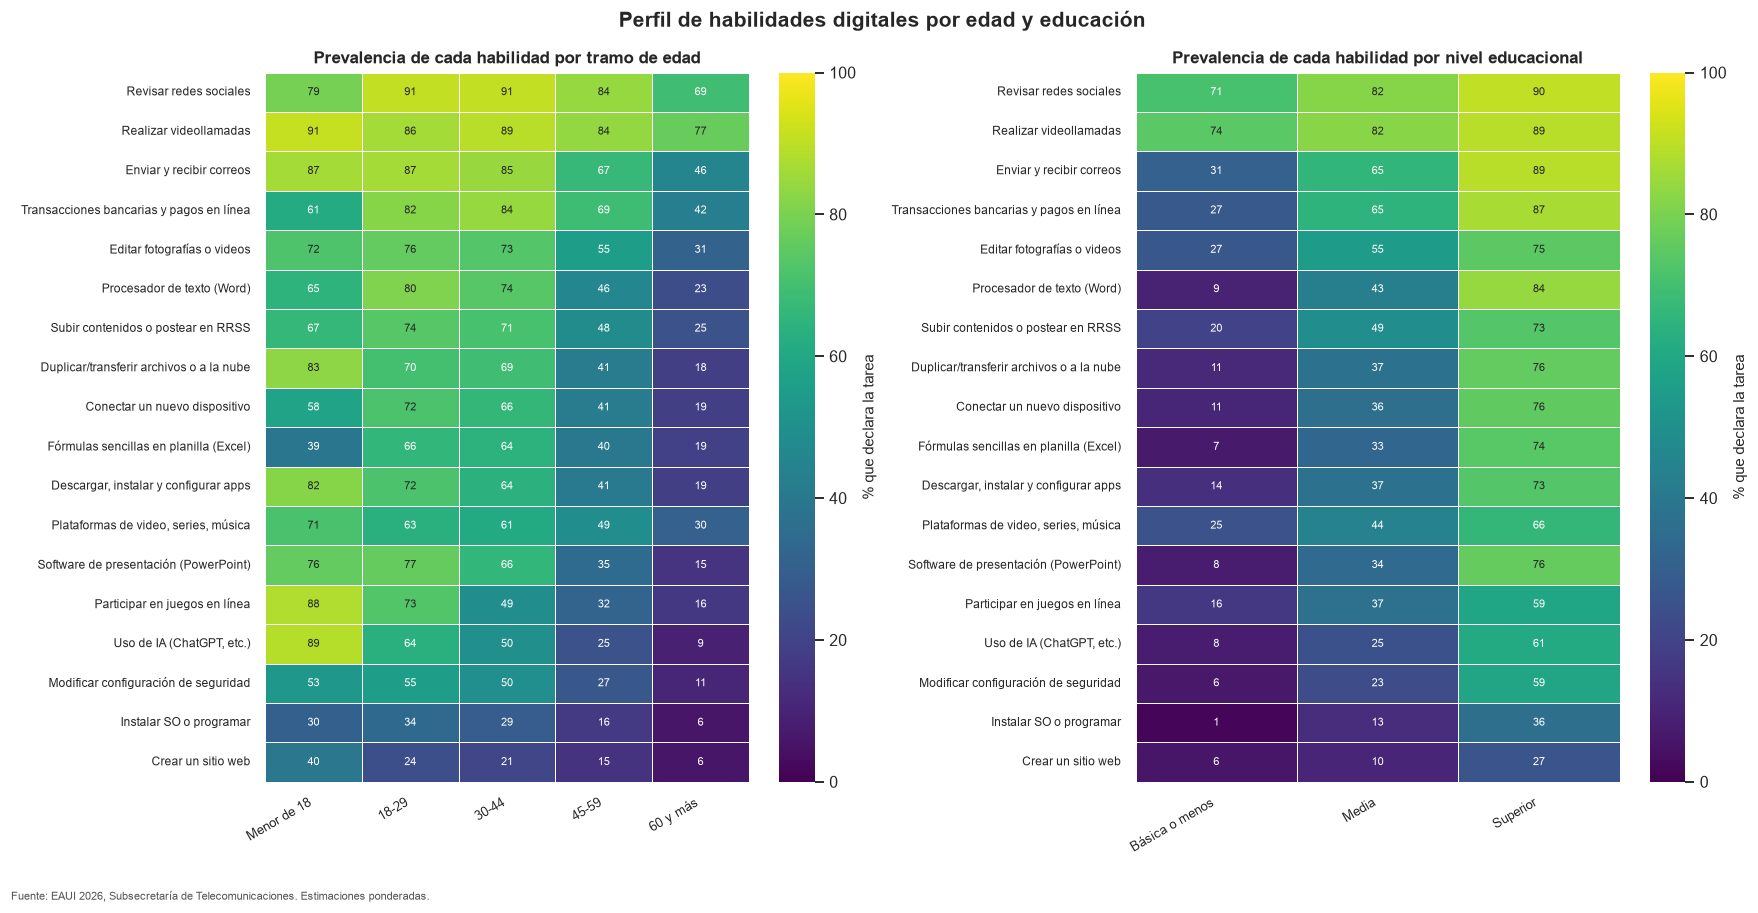

PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/08_items_por_educacion.csv')

In [ ]:
# ---------------------------------------------------------------------------
# 11.6 Mapa de calor: cada tarea por tramo de edad y por educación
# ---------------------------------------------------------------------------
def matriz_prevalencia(datos, variables, factor, peso):
    """Prevalencia ponderada de cada ítem dentro de cada categoría del factor."""
    sub = datos[datos[factor].notna()]
    categorias = (sub[factor].cat.categories
                  if isinstance(sub[factor].dtype, pd.CategoricalDtype)
                  else sorted(sub[factor].dropna().unique(), key=str))
    matriz = pd.DataFrame(index=[Q8_ETIQUETA.get(v, v) for v in variables],
                          columns=list(categorias), dtype=float)
    for categoria in categorias:
        bloque = sub[sub[factor] == categoria]
        for var in variables:
            matriz.loc[Q8_ETIQUETA.get(var, var), categoria] = \
                100 * proporcion_ponderada(bloque[var], bloque[peso])[0]
    return matriz


orden_items = (matriz_q8.mean().sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, factor, titulo_panel in [(axes[0], "tramo_edad", "por tramo de edad"),
                                 (axes[1], "educ_grupo", "por nivel educacional")]:
    matriz = matriz_prevalencia(df, orden_items, factor, PESO_PERSONA)
    sns.heatmap(matriz, cmap="viridis", vmin=0, vmax=100, annot=True, fmt=".0f",
                annot_kws={"size": 7.5}, linewidths=0.4,
                cbar_kws={"label": "% que declara la tarea"}, ax=ax)
    ax.set_title(f"Prevalencia de cada habilidad {titulo_panel}", fontsize=11)
    ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8.5)
    plt.setp(ax.get_yticklabels(), fontsize=8)

fig.suptitle("Perfil de habilidades digitales por edad y educación",
             fontsize=13.5, fontweight="bold")
fig.tight_layout()
print(guardar_figura(fig, "08_heatmap_items_edad_educacion"))
plt.show()

guardar_tabla(matriz_prevalencia(df, orden_items, "tramo_edad", PESO_PERSONA),
              "08_items_por_edad")
guardar_tabla(matriz_prevalencia(df, orden_items, "educ_grupo", PESO_PERSONA),
              "08_items_por_educacion")

BRECHA DE GÉNERO EN HABILIDADES POR TRAMO DE EDAD


,media_hombre,n_hombre,media_mujer,n_mujer,brecha
tramo_edad,,,,,
Menor de 18,12.46,25,11.98,15,+0.48
18-29,13.31,432,11.45,444,+1.86
30-44,12.29,547,10.88,788,+1.41
45-59,8.76,526,7.67,722,+1.10
60 y más,5.27,545,4.42,714,+0.84


/Users/tomas/github/eaui2026/outputs/habilidades/09_brecha_genero.png


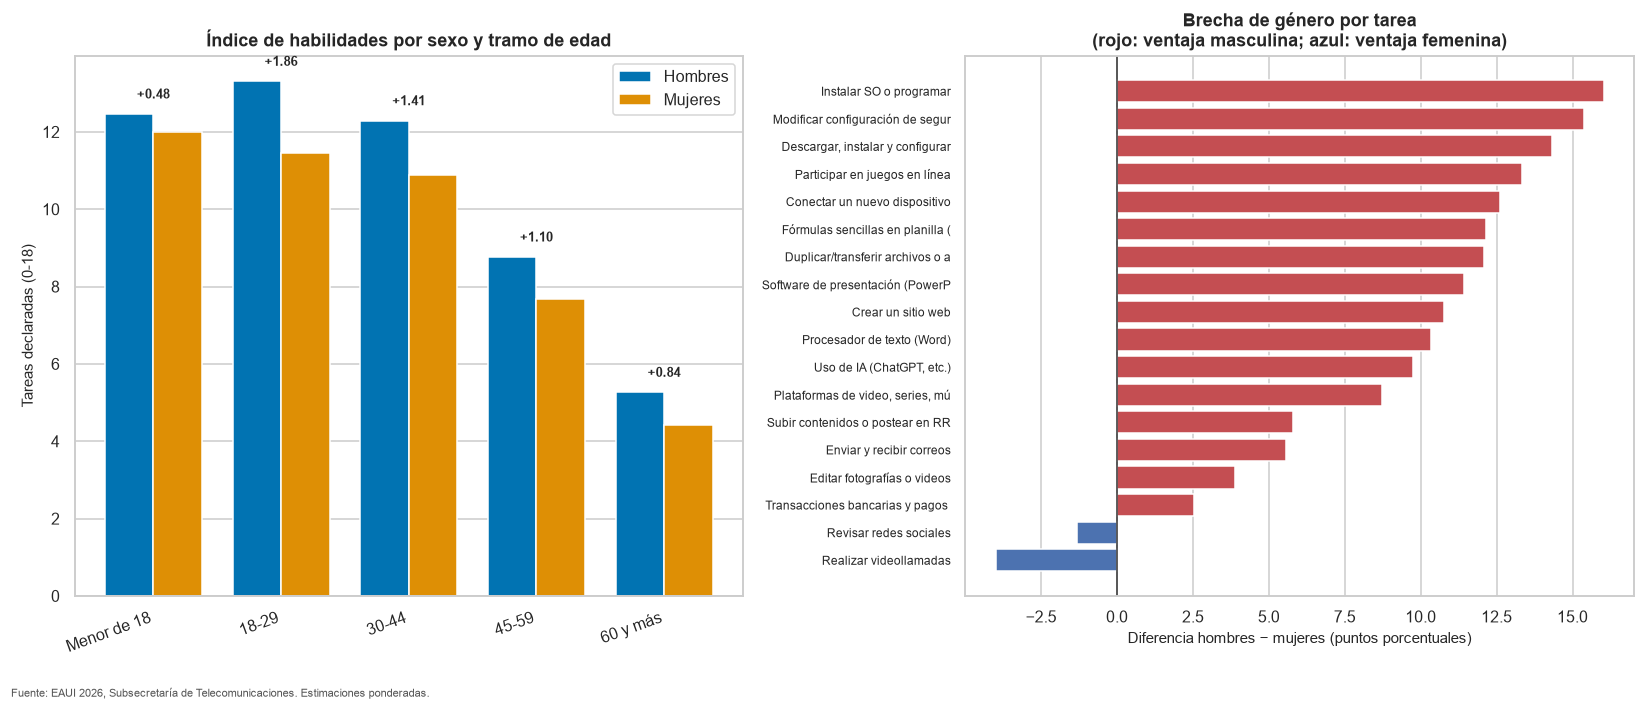

PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/09_brecha_genero_por_item.csv')

In [ ]:
# ---------------------------------------------------------------------------
# 11.7 Brecha de género y su interacción con la edad
# ---------------------------------------------------------------------------
# El marco conceptual advierte que el autorreporte sobreestima en hombres y subestima en
# mujeres. La brecha observada es de declaración, no necesariamente de competencia efectiva.
filas = []
for tramo in df["tramo_edad"].cat.categories:
    bloque = df[df["tramo_edad"] == tramo]
    fila = {"tramo_edad": tramo}
    for sexo_valor in ["Hombre", "Mujer"]:
        celda = bloque[bloque["sexo"] == sexo_valor]
        media_c, li, ls, n_c, _ = media_ponderada(celda["hab_total"], celda[PESO_PERSONA])
        fila[f"media_{sexo_valor.lower()}"] = media_c
        fila[f"n_{sexo_valor.lower()}"] = n_c
    fila["brecha"] = fila["media_hombre"] - fila["media_mujer"]
    filas.append(fila)

brecha_genero = pd.DataFrame(filas).set_index("tramo_edad")

titulo("BRECHA DE GÉNERO EN HABILIDADES POR TRAMO DE EDAD")
display(brecha_genero.style.format({"media_hombre": "{:.2f}", "media_mujer": "{:.2f}",
                                    "brecha": "{:+.2f}"}))

# Brecha por ítem
brecha_items = []
for var in Q8_VARS:
    p_h = proporcion_ponderada(df.loc[df["sexo"] == "Hombre", var],
                               df.loc[df["sexo"] == "Hombre", PESO_PERSONA])[0]
    p_m = proporcion_ponderada(df.loc[df["sexo"] == "Mujer", var],
                               df.loc[df["sexo"] == "Mujer", PESO_PERSONA])[0]
    brecha_items.append({"tarea": Q8_ETIQUETA[var], "nivel": Q8_NIVEL[var],
                         "hombres": 100 * p_h, "mujeres": 100 * p_m,
                         "brecha_pp": 100 * (p_h - p_m)})
brecha_items = pd.DataFrame(brecha_items).sort_values("brecha_pp")

fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))

ancho = 0.38
posiciones = np.arange(len(brecha_genero))
axes[0].bar(posiciones - ancho / 2, brecha_genero["media_hombre"], ancho,
            label="Hombres", color=sns.color_palette(PALETA)[0])
axes[0].bar(posiciones + ancho / 2, brecha_genero["media_mujer"], ancho,
            label="Mujeres", color=sns.color_palette(PALETA)[1])
for x, brecha in enumerate(brecha_genero["brecha"]):
    axes[0].text(x, max(brecha_genero.loc[brecha_genero.index[x],
                        ["media_hombre", "media_mujer"]]) + 0.4,
                 f"{brecha:+.2f}", ha="center", fontsize=8.5, fontweight="bold")
axes[0].set_xticks(posiciones)
axes[0].set_xticklabels(brecha_genero.index, rotation=20, ha="right")
axes[0].set_ylabel("Tareas declaradas (0-18)")
axes[0].set_title("Índice de habilidades por sexo y tramo de edad")
axes[0].legend()
axes[0].grid(axis="x", visible=False)

colores_brecha = ["#c44e52" if b > 0 else "#4c72b0" for b in brecha_items["brecha_pp"]]
axes[1].barh(range(len(brecha_items)), brecha_items["brecha_pp"], color=colores_brecha)
axes[1].axvline(0, color="#333333", linewidth=1)
axes[1].set_yticks(range(len(brecha_items)))
axes[1].set_yticklabels([t[:32] for t in brecha_items["tarea"]], fontsize=8)
axes[1].set_xlabel("Diferencia hombres − mujeres (puntos porcentuales)")
axes[1].set_title("Brecha de género por tarea\n(rojo: ventaja masculina; azul: ventaja femenina)")
axes[1].grid(axis="y", visible=False)

fig.tight_layout()
print(guardar_figura(fig, "09_brecha_genero"))
plt.show()
guardar_tabla(brecha_items.set_index("tarea"), "09_brecha_genero_por_item")

---
## 12. Adquisición de la competencia (Q6)

Q6 mide **por qué vía** se adquirió la habilidad, no su nivel. Es la variable que permite separar
capital digital adquirido informalmente del adquirido a través del sistema educativo o de formación
formal. Base = 5.000 (no tiene filtro).

`Q6_7` ("no sé usar computador o nunca he usado uno") es una declaración directa de ausencia de
competencia y se trata como dato sustantivo, no como no-respuesta. `Q6_8` y `Q6_9` refieren a
acceso, no a habilidad, y se mantienen separadas.

In [ ]:
# ---------------------------------------------------------------------------
# 12.1 Vías de adquisición de la competencia
# ---------------------------------------------------------------------------
filas = []
for var, etiqueta_via in {**Q6_ADQUISICION, **Q6_SIN_COMPETENCIA, **Q6_ACCESO, **Q6_NS}.items():
    if var not in df.columns:
        continue
    p, li, ls, n, _ = proporcion_ponderada(df[var], df[PESO_PERSONA])
    if var in Q6_ADQUISICION:
        tipo = ("Formal" if var in Q6_FORMALES else
                "Laboral" if var in Q6_LABORAL else
                "Informal" if var in Q6_INFORMALES else "Otro")
    elif var in Q6_SIN_COMPETENCIA:
        tipo = "Ausencia de competencia"
    elif var in Q6_ACCESO:
        tipo = "Acceso (no habilidad)"
    else:
        tipo = "No sabe"
    filas.append({"variable": var, "via": etiqueta_via, "tipo": tipo,
                  "pct": 100 * p, "ic_inf": 100 * li, "ic_sup": 100 * ls, "n_declara": int(df[var].sum())})

adquisicion = pd.DataFrame(filas).sort_values("pct", ascending=False).reset_index(drop=True)

titulo("VÍAS DE ADQUISICIÓN DE LA COMPETENCIA DIGITAL (Q6)")
display(adquisicion.style.format({"pct": "{:.1f}", "ic_inf": "{:.1f}", "ic_sup": "{:.1f}"}))

p_formal   = proporcion_ponderada((df[Q6_FORMALES].sum(axis=1) > 0).astype(float), df[PESO_PERSONA])
p_informal = proporcion_ponderada((df[Q6_INFORMALES].sum(axis=1) > 0).astype(float), df[PESO_PERSONA])
p_laboral  = proporcion_ponderada((df[Q6_LABORAL].sum(axis=1) > 0).astype(float), df[PESO_PERSONA])
print(f"\nAlguna vía FORMAL   (currículum, optativas, curso): {100*p_formal[0]:.1f}%")
print(f"Alguna vía INFORMAL (autodidacta, red social, ciber): {100*p_informal[0]:.1f}%")
print(f"Vía LABORAL         (aprendió en el trabajo)        : {100*p_laboral[0]:.1f}%")
guardar_tabla(adquisicion.set_index("variable"), "10_adquisicion_q6")

VÍAS DE ADQUISICIÓN DE LA COMPETENCIA DIGITAL (Q6)


,variable,via,tipo,pct,ic_inf,ic_sup,n_declara
0,Q6_11,Aprendí solo (autodidacta),Informal,37.7,35.5,39.9,1540
1,Q6_3,Currículum central escolar/superior,Formal,29.1,27.1,31.2,1425
2,Q6_7,No sé usar computador / nunca he usado uno,Ausencia de competencia,19.5,17.7,21.3,1280
3,Q6_2,"Me enseñó familiar, amigo o contacto",Informal,16.2,14.5,17.9,768
4,Q6_4,Clases optativas o complementarias,Formal,7.2,6.1,8.4,331
5,Q6_5,Curso particular / municipio / centro social,Formal,5.1,4.1,6.1,279
6,Q6_10,En el trabajo,Laboral,1.3,0.8,1.8,67
7,Q6_8,No usa,Acceso (no habilidad),0.0,0.0,0.1,4
8,Q6_6,Otro,Otro,0.0,0.0,0.1,2
9,Q6_12,No sabe,No sabe,0.0,0.0,0.1,2



Alguna vía FORMAL   (currículum, optativas, curso): 38.1%
Alguna vía INFORMAL (autodidacta, red social, ciber): 50.3%
Vía LABORAL         (aprendió en el trabajo)        : 1.3%


PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/10_adquisicion_q6.csv')

VÍA DE ADQUISICIÓN POR GENERACIÓN (% de cada generación)


,Gen Z (≤27),Millennial (28-43),Gen X (44-59),Boomer (60-78),Silent (79+)
Aprendí solo (autodidacta),56.0,44.4,30.7,16.7,10.2
"Me enseñó familiar, amigo o contacto",21.9,12.3,17.1,16.0,6.4
Currículum central escolar/superior,35.3,44.4,22.7,7.9,1.1
Clases optativas o complementarias,7.8,9.4,5.7,5.3,3.7
Curso particular / municipio / centro social,1.5,3.9,9.9,6.1,3.1
En el trabajo,0.0,0.3,1.6,4.0,1.2
A través del ciber,0.0,0.0,0.0,0.0,0.0
Otro,0.1,0.1,0.0,0.0,0.0


/Users/tomas/github/eaui2026/outputs/habilidades/10_adquisicion_por_generacion.png


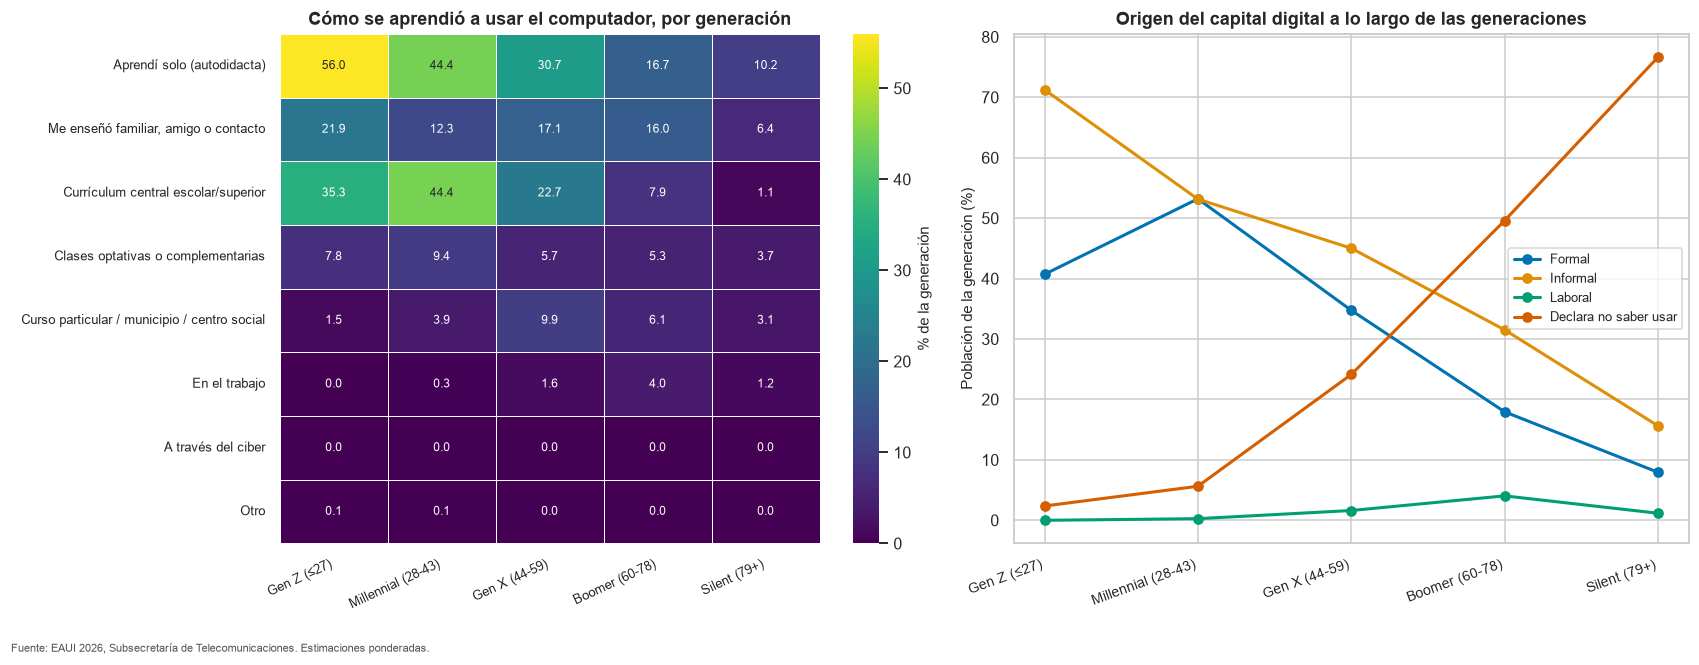

PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/10_via_por_generacion.csv')

In [ ]:
# ---------------------------------------------------------------------------
# 12.2 Vía de adquisición por generación y educación
# ---------------------------------------------------------------------------
via_generacion = pd.DataFrame(
    {via: [100 * proporcion_ponderada(df.loc[df["generacion"] == g, var],
                                      df.loc[df["generacion"] == g, PESO_PERSONA])[0]
           for g in df["generacion"].cat.categories]
     for var, via in Q6_ADQUISICION.items()},
    index=df["generacion"].cat.categories).T

titulo("VÍA DE ADQUISICIÓN POR GENERACIÓN (% de cada generación)")
display(via_generacion.style.format("{:.1f}"))

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8))

sns.heatmap(via_generacion, cmap="viridis", annot=True, fmt=".1f", annot_kws={"size": 8},
            linewidths=0.4, cbar_kws={"label": "% de la generación"}, ax=axes[0])
axes[0].set_title("Cómo se aprendió a usar el computador, por generación")
plt.setp(axes[0].get_xticklabels(), rotation=25, ha="right", fontsize=8.5)
plt.setp(axes[0].get_yticklabels(), fontsize=8.5)

resumen_tipo = pd.DataFrame({
    "Formal": [100 * proporcion_ponderada(df.loc[df["generacion"] == g, Q6_FORMALES].sum(axis=1) > 0,
                                          df.loc[df["generacion"] == g, PESO_PERSONA])[0]
               for g in df["generacion"].cat.categories],
    "Informal": [100 * proporcion_ponderada(df.loc[df["generacion"] == g, Q6_INFORMALES].sum(axis=1) > 0,
                                            df.loc[df["generacion"] == g, PESO_PERSONA])[0]
                 for g in df["generacion"].cat.categories],
    "Laboral": [100 * proporcion_ponderada(df.loc[df["generacion"] == g, Q6_LABORAL].sum(axis=1) > 0,
                                           df.loc[df["generacion"] == g, PESO_PERSONA])[0]
                for g in df["generacion"].cat.categories],
    "Declara no saber usar": [100 * proporcion_ponderada(df.loc[df["generacion"] == g, "Q6_7"],
                                                         df.loc[df["generacion"] == g, PESO_PERSONA])[0]
                              for g in df["generacion"].cat.categories],
}, index=df["generacion"].cat.categories)

for columna, color in zip(resumen_tipo.columns, sns.color_palette(PALETA, 4)):
    axes[1].plot(range(len(resumen_tipo)), resumen_tipo[columna], marker="o",
                 linewidth=2, markersize=6, label=columna, color=color)
axes[1].set_xticks(range(len(resumen_tipo)))
axes[1].set_xticklabels(resumen_tipo.index, rotation=20, ha="right", fontsize=9)
axes[1].set_ylabel("Población de la generación (%)")
axes[1].set_title("Origen del capital digital a lo largo de las generaciones")
axes[1].legend(fontsize=8.5)

fig.tight_layout()
print(guardar_figura(fig, "10_adquisicion_por_generacion"))
plt.show()
guardar_tabla(via_generacion, "10_via_por_generacion")

---
## 13. Seguridad (Q32) y autoeficacia percibida (Q31)

Q32 registra conductas, pero cada una presupone una competencia de gestión de seguridad. Q31 mide
autoeficacia percibida. El cruce identifica el **cuadrante de riesgo**: personas que se sienten
protegidas sin ejecutar ninguna práctica efectiva de protección.

`Q32_7` es un NET agregado y está excluido del índice, según advierte el marco conceptual.

In [ ]:
# ---------------------------------------------------------------------------
# 13.1 Prácticas de seguridad y autoeficacia percibida
# ---------------------------------------------------------------------------
filas = []
for var, etiqueta_practica in Q32_NUCLEO.items():
    p, li, ls, n, _ = proporcion_ponderada(df[var], df[PESO_PERSONA])
    filas.append({"variable": var, "practica": etiqueta_practica, "pct": 100 * p,
                  "ic_inf": 100 * li, "ic_sup": 100 * ls})
p_ninguna = proporcion_ponderada(df[Q32_NINGUNA], df[PESO_PERSONA])
filas.append({"variable": Q32_NINGUNA, "practica": "NINGUNA de las anteriores",
              "pct": 100 * p_ninguna[0], "ic_inf": 100 * p_ninguna[1], "ic_sup": 100 * p_ninguna[2]})

practicas_seguridad = pd.DataFrame(filas).sort_values("pct", ascending=False)

titulo("PRÁCTICAS DE SEGURIDAD Y PRIVACIDAD (Q32, base 4.731)")
display(practicas_seguridad.set_index("variable").style.format(
    {"pct": "{:.1f}", "ic_inf": "{:.1f}", "ic_sup": "{:.1f}"}))

media_seg, li_seg, ls_seg, n_seg, _ = media_ponderada(df["idx_seguridad"], df[PESO_PERSONA])
print(f"\nÍndice de seguridad (0-6): media {media_seg:.2f}  IC95% [{li_seg:.2f}, {ls_seg:.2f}] | n = {n_seg:,}")
print("\nAutoeficacia percibida (Q31):")
display(distribucion_ponderada(df, "percepcion_proteccion", PESO_PERSONA)
        .style.format({"casos_expandidos": "{:,.0f}", "pct": "{:.1f}",
                       "ic_inf": "{:.1f}", "ic_sup": "{:.1f}"}))
guardar_tabla(practicas_seguridad.set_index("variable"), "11_practicas_seguridad")

PRÁCTICAS DE SEGURIDAD Y PRIVACIDAD (Q32, base 4.731)


,practica,pct,ic_inf,ic_sup
variable,,,,
Q32_2,No abrir archivos o links sospechosos,55.1,52.8,57.4
Q32_6,Cambio de contraseñas,41.5,39.2,43.8
Q32_1,Herramientas de protección (antivirus/firewall),35.0,32.8,37.2
Q32_4,Cambiar ajustes de privacidad en RRSS,32.0,29.8,34.2
Q32_5,Borrar historial de búsqueda,30.4,28.3,32.6
Q32_3,Borrar/editar contenido propio publicado,22.2,20.2,24.1
Q32_18,NINGUNA de las anteriores,21.4,19.5,23.3



Índice de seguridad (0-6): media 2.16  IC95% [2.08, 2.25] | n = 4,731

Autoeficacia percibida (Q31):


,n,casos_expandidos,pct,ic_inf,ic_sup
categoria,,,,,
Muy protegido,381,"1,531,333",12.0,10.4,13.5
Protegido,2077,"6,175,436",48.3,45.9,50.6
Desprotegido,1653,"4,017,412",31.4,29.2,33.6
Muy desprotegido,389,"1,071,701",8.4,7.1,9.7


PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/11_practicas_seguridad.csv')

CUADRANTE DE RIESGO: PERCEPCIÓN vs. PRÁCTICA


practica_efectiva,Practica 3 o más,Practica menos de 3
se_siente_protegido,,
Se siente desprotegido,14.3,25.5
Se siente protegido,26.4,33.8



FALSA SEGURIDAD: 33.8% de los usuarios se sienten protegidos pese a
ejecutar menos de 3 de las 6 prácticas de protección del listado.

Asociación percepción × práctica: V de Cramér = 0.078 (despreciable), p = 0.0000, n = 4,500


/Users/tomas/github/eaui2026/outputs/habilidades/11_cuadrante_riesgo.png


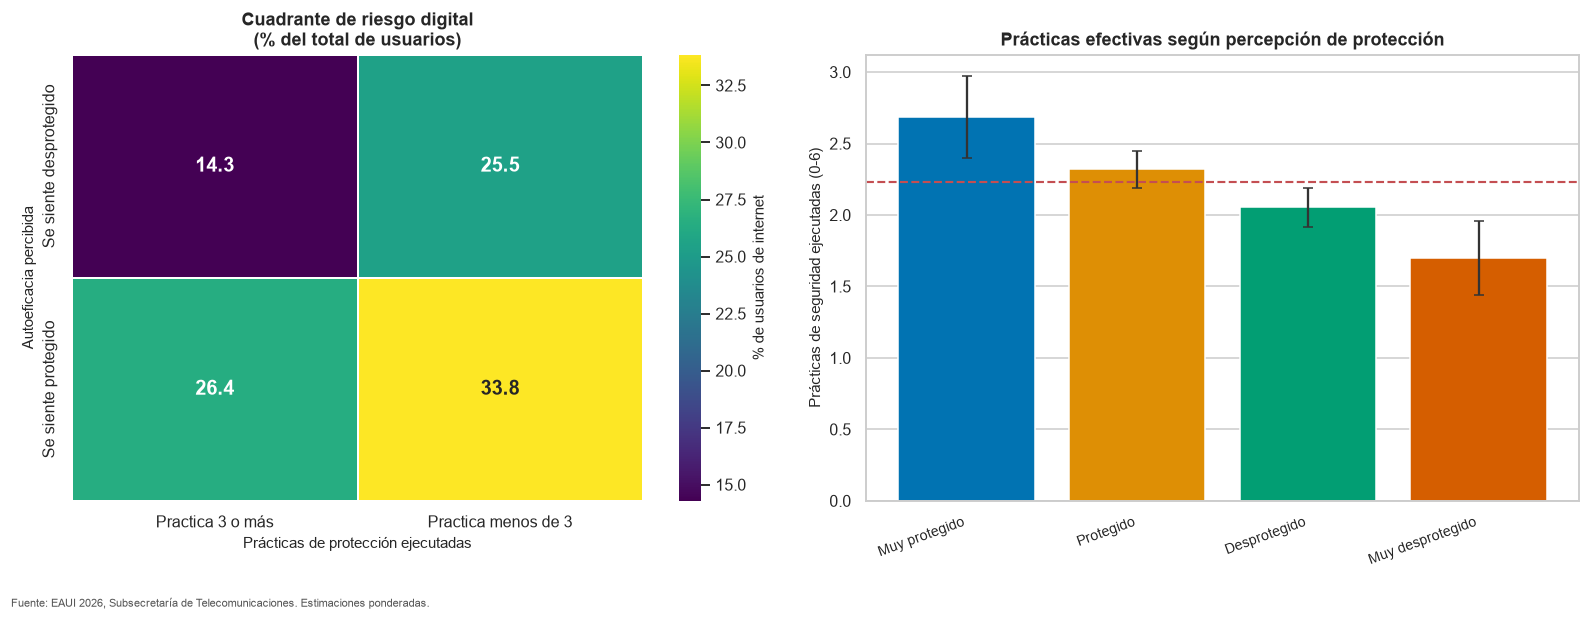

PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/11_cuadrante_riesgo.csv')

In [ ]:
# ---------------------------------------------------------------------------
# 13.2 Cuadrante de riesgo: autoeficacia percibida frente a práctica efectiva
# ---------------------------------------------------------------------------
sub_riesgo = df[df["se_siente_protegido"].notna() & df["idx_seguridad"].notna()].copy()
sub_riesgo["practica_efectiva"] = np.where(sub_riesgo["idx_seguridad"] >= 3,
                                           "Practica 3 o más", "Practica menos de 3")
sub_riesgo["cuadrante"] = sub_riesgo["se_siente_protegido"] + " / " + sub_riesgo["practica_efectiva"]

cuadrantes = tabla_cruzada_ponderada(sub_riesgo, "se_siente_protegido",
                                     "practica_efectiva", PESO_PERSONA, normalizar=None)
cuadrantes_pct = 100 * cuadrantes / cuadrantes.to_numpy().sum()

titulo("CUADRANTE DE RIESGO: PERCEPCIÓN vs. PRÁCTICA")
display(cuadrantes_pct.style.format("{:.1f}"))

falsa_seguridad = cuadrantes_pct.loc["Se siente protegido", "Practica menos de 3"]
print(f"\nFALSA SEGURIDAD: {falsa_seguridad:.1f}% de los usuarios se sienten protegidos pese a")
print("ejecutar menos de 3 de las 6 prácticas de protección del listado.")
prueba = asociacion(sub_riesgo, "se_siente_protegido", "practica_efectiva", PESO_PERSONA)
print(f"\nAsociación percepción × práctica: V de Cramér = {prueba['cramers_v']:.3f} "
      f"({prueba['interpretacion']}), p = {prueba['p']:.4f}, n = {prueba['n']:,}")

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))

sns.heatmap(cuadrantes_pct, annot=True, fmt=".1f", cmap="viridis", linewidths=1.2,
            cbar_kws={"label": "% de usuarios de internet"}, ax=axes[0],
            annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title("Cuadrante de riesgo digital\n(% del total de usuarios)")
axes[0].set_xlabel("Prácticas de protección ejecutadas")
axes[0].set_ylabel("Autoeficacia percibida")

perfil_prot = perfil_habilidades(df, "percepcion_proteccion", indice="idx_seguridad")
posiciones = np.arange(len(perfil_prot))
axes[1].bar(posiciones, perfil_prot["media"],
            yerr=[perfil_prot["media"] - perfil_prot["ic_inf"],
                  perfil_prot["ic_sup"] - perfil_prot["media"]],
            color=sns.color_palette(PALETA, len(perfil_prot)),
            error_kw={"ecolor": "#333333", "capsize": 3})
axes[1].axhline(perfil_prot.attrs["media_global"], color="#c44e52", linestyle="--", linewidth=1.4)
axes[1].set_xticks(posiciones)
axes[1].set_xticklabels(perfil_prot.index, rotation=20, ha="right", fontsize=9)
axes[1].set_ylabel("Prácticas de seguridad ejecutadas (0-6)")
axes[1].set_title("Prácticas efectivas según percepción de protección")
axes[1].grid(axis="x", visible=False)

fig.tight_layout()
print(guardar_figura(fig, "11_cuadrante_riesgo"))
plt.show()
guardar_tabla(cuadrantes_pct, "11_cuadrante_riesgo")

In [ ]:
# ---------------------------------------------------------------------------
# 13.3 Seguridad y competencia digital general
# ---------------------------------------------------------------------------
correlacion = df[["hab_total", "idx_seguridad"]].corr().iloc[0, 1]
perfil_seg = perfil_habilidades(df, "nivel_habilidades", indice="idx_seguridad")

titulo("SEGURIDAD × COMPETENCIA DIGITAL")
print(f"Correlación de Pearson hab_total × idx_seguridad: r = {correlacion:.3f}")
print("\nPrácticas de seguridad por nivel de habilidades:")
display(perfil_seg.style.format({"media": "{:.2f}", "ic_inf": "{:.2f}", "ic_sup": "{:.2f}",
                                 "dif_vs_total": "{:+.2f}", "poblacion": "{:,.0f}",
                                 "n_efectivo": "{:,.0f}"}))

# Exposición a incidentes (Q33) por nivel de habilidades: no es habilidad, es consecuencia
Q33_INCIDENTES = {"Q33_1": "Ataque de virus", "Q33_2": "Mal uso de información personal",
                  "Q33_3": "Pérdidas financieras por fraude", "Q33_4": "Suplantación de identidad"}
incidentes = pd.DataFrame(
    {etiqueta_inc: [100 * proporcion_ponderada(df.loc[df["nivel_habilidades"] == nivel, var],
                                               df.loc[df["nivel_habilidades"] == nivel, PESO_PERSONA])[0]
                    for nivel in ORDEN_NIVEL_HAB]
     for var, etiqueta_inc in Q33_INCIDENTES.items()},
    index=ORDEN_NIVEL_HAB)

print("\nExposición a incidentes de seguridad por nivel de habilidades (%):")
display(incidentes.style.format("{:.1f}"))
guardar_tabla(incidentes, "11_incidentes_por_nivel")

SEGURIDAD × COMPETENCIA DIGITAL
Correlación de Pearson hab_total × idx_seguridad: r = 0.521

Prácticas de seguridad por nivel de habilidades:


,media,ic_inf,ic_sup,n,n_efectivo,poblacion,dif_vs_total
categoria,,,,,,,
Sin habilidades,0.47,0.18,0.77,104,45,"176,875",-1.71
Básico,0.70,0.59,0.81,776,321,"1,557,768",-1.48
Intermedio,1.82,1.71,1.92,2225,849,"5,691,359",-0.37
Avanzado,3.01,2.87,3.15,1547,613,"5,680,820",+0.83



Exposición a incidentes de seguridad por nivel de habilidades (%):


,Ataque de virus,Mal uso de información personal,Pérdidas financieras por fraude,Suplantación de identidad
Sin habilidades,9.1,2.0,3.5,1.3
Básico,6.8,2.7,2.0,1.5
Intermedio,11.4,5.7,5.7,3.1
Avanzado,11.8,7.2,7.7,4.1


PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/11_incidentes_por_nivel.csv')

---
## 14. Barreras atribuidas a falta de habilidad

Tres fuentes con bases muy distintas:

- **Q34** (n = 269): razones de no uso de internet, entre no usuarios. Nivel persona.
- **Q36_CODIF** (n = 48): atribución espontánea de desinterés. Nivel persona.
- **P13** (n = 1.645): razones de no tener banda ancha fija. **Nivel hogar**.

Las bases de Q34 y Q36 no admiten desagregación. Se reportan como caracterización descriptiva
ponderada con n explícito en cada estimación.

In [ ]:
# ---------------------------------------------------------------------------
# 14.1 Q34: razones de no uso entre no usuarios (n = 269)
# ---------------------------------------------------------------------------
base_q34 = df[df["Q34_6"].notna()]
titulo(f"BARRERAS DE NO USO DE INTERNET (Q34, base {len(base_q34):,} no usuarios)")

filas = []
for var, etiqueta_barrera in {**Q34_HABILIDAD, **Q34_CONTEXTO_HAB}.items():
    p, li, ls, n, n_ef = proporcion_ponderada(base_q34[var], base_q34[PESO_PERSONA])
    filas.append({"variable": var, "barrera": etiqueta_barrera,
                  "tipo": "Habilidad" if var in Q34_HABILIDAD else "Contexto/disposición",
                  "pct": 100 * p, "ic_inf": 100 * li, "ic_sup": 100 * ls,
                  "n_declara": int(base_q34[var].sum()), "base_n": n})
barreras_q34 = pd.DataFrame(filas).sort_values("pct", ascending=False)
display(barreras_q34.set_index("variable").style.format(
    {"pct": "{:.1f}", "ic_inf": "{:.1f}", "ic_sup": "{:.1f}"}))

p_net = proporcion_ponderada(base_q34["Q34_5"], base_q34[PESO_PERSONA])
print(f"\nNET USABILIDAD (Q34_5, agregado del cuestionario): {100*p_net[0]:.1f}%")
print("Advertencia: n = 269 sin ponderar. No admite desagregación por región, sexo ni edad.")
print("Los IC son anchos por construcción; leer siempre junto al n de cada estimación.")
guardar_tabla(barreras_q34.set_index("variable"), "12_barreras_q34")

BARRERAS DE NO USO DE INTERNET (Q34, base 269 no usuarios)


,barrera,tipo,pct,ic_inf,ic_sup,n_declara,base_n
variable,,,,,,,
Q34_6,No sé utilizar computador/smartphone,Habilidad,30.9,21.7,40.0,93,269
Q34_7,No sé cómo utilizar internet,Habilidad,22.9,14.6,31.2,91,269
Q34_2,No sé para qué sirve internet (conocimiento),Contexto/disposición,19.9,12.0,27.8,56,269
Q34_8,No creo ser capaz de aprender (autoeficacia),Habilidad,9.7,3.8,15.5,37,269
Q34_9,No me dan ganas de aprender (disposición),Contexto/disposición,9.6,3.8,15.4,31,269
Q34_11,Discapacidad o limitación,Contexto/disposición,3.8,0.0,7.6,3,269
Q34_10,Otras personas navegan por mí (delegación),Contexto/disposición,1.3,0.0,3.5,7,269



NET USABILIDAD (Q34_5, agregado del cuestionario): 46.3%
Advertencia: n = 269 sin ponderar. No admite desagregación por región, sexo ni edad.
Los IC son anchos por construcción; leer siempre junto al n de cada estimación.


PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/12_barreras_q34.csv')

In [ ]:
# ---------------------------------------------------------------------------
# 14.2 P13: barreras de habilidad para tener banda ancha fija (nivel HOGAR)
# ---------------------------------------------------------------------------
base_p13 = df_hogar[df_hogar["P13_4"].notna()]
titulo(f"BARRERAS DE ACCESO A BANDA ANCHA FIJA (P13, nivel hogar, base {len(base_p13):,})")
print(f"Base sin filtrar por jefe de hogar: {int(df['P13_4'].notna().sum()):,} hogares.\n")

filas = []
for var, etiqueta_barrera in {**P13_HABILIDAD, **P13_CONOCIMIENTO}.items():
    p, li, ls, n, _ = proporcion_ponderada(base_p13[var], base_p13[PESO_HOGAR])
    filas.append({"variable": var, "barrera": etiqueta_barrera,
                  "tipo": "Habilidad" if var in P13_HABILIDAD else "Conocimiento/confianza",
                  "pct": 100 * p, "ic_inf": 100 * li, "ic_sup": 100 * ls,
                  "n_declara": int(base_p13[var].sum()), "base_n": n})
barreras_p13 = pd.DataFrame(filas).sort_values("pct", ascending=False)
display(barreras_p13.set_index("variable").style.format(
    {"pct": "{:.1f}", "ic_inf": "{:.1f}", "ic_sup": "{:.1f}"}))

print("\nDesconocimiento (P13_1) frente a rechazo informado (P13_2):")
p1_ = proporcion_ponderada(base_p13["P13_1"], base_p13[PESO_HOGAR])[0]
p2_ = proporcion_ponderada(base_p13["P13_2"], base_p13[PESO_HOGAR])[0]
print(f"  No conocen los beneficios          : {100*p1_:.1f}%")
print(f"  Conocen pero no lo encuentran útil : {100*p2_:.1f}%")
print("La distinción es central para el diseño de política: el primer grupo es objeto de")
print("alfabetización digital; el segundo, de una decisión informada que no se revierte informando.")

# Q36: atribución espontánea de desinterés (n = 48)
base_q36 = df[df["Q36_CODIF_2"].notna()]
if len(base_q36):
    p_no_maneja = proporcion_ponderada(base_q36["Q36_CODIF_2"], base_q36[PESO_PERSONA])
    p_desconf = proporcion_ponderada(base_q36["Q36_CODIF_9"], base_q36[PESO_PERSONA])
    print(f"\nQ36 (atribución espontánea de desinterés, base {len(base_q36)} casos):")
    print(f"  'No se maneja, no sabe usar' : {100*p_no_maneja[0]:.1f}%  (n = {int(base_q36['Q36_CODIF_2'].sum())})")
    print(f"  'Desconfianza'               : {100*p_desconf[0]:.1f}%  (n = {int(base_q36['Q36_CODIF_9'].sum())})")
    print("  Base insuficiente para cualquier inferencia. Solo valor descriptivo.")
guardar_tabla(barreras_p13.set_index("variable"), "12_barreras_p13")

BARRERAS DE ACCESO A BANDA ANCHA FIJA (P13, nivel hogar, base 1,645)
Base sin filtrar por jefe de hogar: 1,645 hogares.



,barrera,tipo,pct,ic_inf,ic_sup,n_declara,base_n
variable,,,,,,,
P13_4,No saben utilizar computador/smartphone,Habilidad,9.3,7.2,11.4,138,1645
P13_5,No saben cómo utilizar internet,Habilidad,8.4,6.4,10.4,104,1645
P13_2,Conocen beneficios pero no lo encuentran útil,Conocimiento/confianza,7.2,5.3,9.1,117,1645
P13_1,No conocen los beneficios de internet,Conocimiento/confianza,6.6,4.8,8.4,105,1645
P13_6,Falta de confianza,Conocimiento/confianza,4.4,2.9,5.9,74,1645
P13_19,Preocupación por privacidad o seguridad,Conocimiento/confianza,0.9,0.2,1.6,11,1645



Desconocimiento (P13_1) frente a rechazo informado (P13_2):
  No conocen los beneficios          : 6.6%
  Conocen pero no lo encuentran útil : 7.2%
La distinción es central para el diseño de política: el primer grupo es objeto de
alfabetización digital; el segundo, de una decisión informada que no se revierte informando.

Q36 (atribución espontánea de desinterés, base 48 casos):
  'No se maneja, no sabe usar' : 37.9%  (n = 22)
  'Desconfianza'               : 16.9%  (n = 6)
  Base insuficiente para cualquier inferencia. Solo valor descriptivo.


PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/12_barreras_p13.csv')

---
## 15. Uso por delegación (Q37)

Uso por intermediación (*proxy use*, Helsper y van Deursen): acceso a los beneficios de internet
sin poseer la competencia. Caracteriza al segmento de "conectados por delegación", invisible en
cualquier indicador dicotómico de uso.

Base = 269 no usuarios, y `Q37_1` registra solo 12 respuestas afirmativas. Se reporta el n crudo
junto a cada porcentaje.

USO POR DELEGACIÓN (Q37, base 269 no usuarios)


,actividad,pct,ic_inf,ic_sup,n_declara,base_n
variable,,,,,,
Q37_5,Realizar un trámite o pagar una cuenta,12.8,6.2,19.4,43,269
Q37_3,Recibir o enviar correo electrónico,5.5,1.0,10.0,15,269
Q37_2,Buscar información (estudio/trabajo),4.3,0.3,8.4,11,269
Q37_6,Realizar una compra,2.7,0.0,5.9,11,269
Q37_1,Obtener algún formulario,2.5,0.0,5.5,12,269
Q37_4,Revisar alguna red social,2.3,0.0,5.2,2,269



Ninguna actividad delegada: 81.9% (n = 204)
Delega al menos una actividad: 18.1%

ADVERTENCIA DE BASE: varias celdas tienen n < 20. Los porcentajes se reportan para
caracterización cualitativa del segmento, no para inferencia poblacional puntual.


/Users/tomas/github/eaui2026/outputs/habilidades/13_delegacion.png


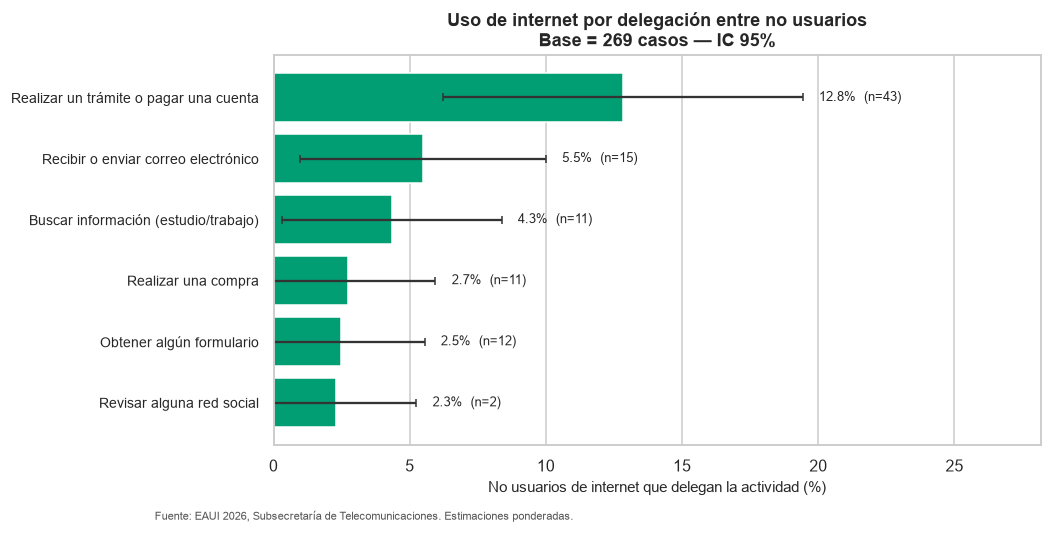

PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/13_delegacion_q37.csv')

In [ ]:
# ---------------------------------------------------------------------------
# 15.1 Actividades delegadas a terceros
# ---------------------------------------------------------------------------
base_q37 = df[df[Q37_NINGUNA].notna()]
titulo(f"USO POR DELEGACIÓN (Q37, base {len(base_q37):,} no usuarios)")

filas = []
for var, etiqueta_act in Q37_DELEGACION.items():
    p, li, ls, n, _ = proporcion_ponderada(base_q37[var], base_q37[PESO_PERSONA])
    filas.append({"variable": var, "actividad": etiqueta_act, "pct": 100 * p,
                  "ic_inf": 100 * li, "ic_sup": 100 * ls,
                  "n_declara": int(base_q37[var].sum()), "base_n": n})
delegacion = pd.DataFrame(filas).sort_values("pct", ascending=False)

p_ninguna_del = proporcion_ponderada(base_q37[Q37_NINGUNA], base_q37[PESO_PERSONA])
display(delegacion.set_index("variable").style.format(
    {"pct": "{:.1f}", "ic_inf": "{:.1f}", "ic_sup": "{:.1f}"}))
print(f"\nNinguna actividad delegada: {100*p_ninguna_del[0]:.1f}% "
      f"(n = {int(base_q37[Q37_NINGUNA].sum())})")
print(f"Delega al menos una actividad: "
      f"{100*proporcion_ponderada((base_q37[list(Q37_DELEGACION)].sum(axis=1) > 0).astype(float), base_q37[PESO_PERSONA])[0]:.1f}%")
print("\nADVERTENCIA DE BASE: varias celdas tienen n < 20. Los porcentajes se reportan para")
print("caracterización cualitativa del segmento, no para inferencia poblacional puntual.")

fig, ax = plt.subplots(figsize=(9, 4.6))
posiciones = np.arange(len(delegacion))[::-1]
ax.barh(posiciones, delegacion["pct"],
        xerr=[delegacion["pct"] - delegacion["ic_inf"], delegacion["ic_sup"] - delegacion["pct"]],
        color=sns.color_palette(PALETA)[2], error_kw={"ecolor": "#333333", "capsize": 2.5})
for y, pct, ic_sup, n_d in zip(posiciones, delegacion["pct"],
                               delegacion["ic_sup"], delegacion["n_declara"]):
    ax.text(ic_sup + 0.6, y, f"{pct:.1f}%  (n={n_d})", va="center", fontsize=8.5)
ax.set_yticks(posiciones)
ax.set_yticklabels(delegacion["actividad"], fontsize=9)
ax.set_xlim(0, max(delegacion["ic_sup"]) * 1.45)
ax.set_xlabel("No usuarios de internet que delegan la actividad (%)")
ax.set_title(f"Uso de internet por delegación entre no usuarios\nBase = {len(base_q37)} casos — IC 95%")
ax.grid(axis="y", visible=False)
print(guardar_figura(fig, "13_delegacion"))
plt.show()
guardar_tabla(delegacion.set_index("variable"), "13_delegacion_q37")

---
## 16. Módulo parental: conocimiento y mediación (P7, P8)

Nivel **hogar**, base = hogares con menores de edad, peso `fe_hogar` sobre las 5.000 filas.

El cruce que habilita este dataset y que el marco conceptual señala como el más interesante: si la
**mediación parental técnica** está condicionada por la competencia digital del adulto. Las medidas
técnicas (filtros, controles parentales, bloqueos) presuponen competencia; las conversacionales, no.

El cruce es válido porque P7 y Q8 los contesta **la misma persona** en la misma fila: el
respondente que informa las medidas del hogar es el mismo cuya competencia digital se midió. No
requiere que además sea el jefe/a de hogar. La sección 16.3 verifica que el resultado se sostiene
al restringir a informantes jefes/as.

In [ ]:
# ---------------------------------------------------------------------------
# 16.1 Índices de mediación parental y conocimiento declarado
# ---------------------------------------------------------------------------
en_base_p7 = df_hogar[list(P7_TECNICA)].notna().all(axis=1)
df_hogar["idx_mediacion_tecnica"] = df_hogar[list(P7_TECNICA)].sum(axis=1).where(en_base_p7)
df_hogar["idx_mediacion_no_tecnica"] = df_hogar[list(P7_NO_TECNICA)].sum(axis=1).where(en_base_p7)
df_hogar["usa_mediacion_tecnica"] = etiquetar(
    df_hogar["idx_mediacion_tecnica"] > 0, "Sí", "No",
    valido=df_hogar["idx_mediacion_tecnica"].notna())

n_conoce = (df_hogar[list(P8_CONOCIMIENTO)] == 1).sum(axis=1)
en_base_p8 = df_hogar[list(P8_CONOCIMIENTO)].notna().any(axis=1)
df_hogar["conoce_riesgos_nna"] = pd.Series(
    np.select([n_conoce == 2, n_conoce == 1], ["Conoce ambos", "Conoce uno"], default="No conoce"),
    index=df_hogar.index, dtype=object).where(en_base_p8)

df_hogar["detecto_situacion"] = etiquetar(
    df_hogar[list(P8_DETECCION)].sum(axis=1) > 0, "Detectó al menos una", "No detectó",
    valido=df_hogar[list(P8_DETECCION)].notna().any(axis=1))

base_parental = df_hogar[en_base_p7]
titulo(f"MÓDULO PARENTAL (base {len(base_parental):,} hogares con menores de edad)")

filas = []
for var, etiqueta_medida in {**P7_TECNICA, **P7_NO_TECNICA}.items():
    p, li, ls, n, _ = proporcion_ponderada(base_parental[var], base_parental[PESO_HOGAR])
    filas.append({"variable": var, "medida": etiqueta_medida,
                  "tipo": "Técnica" if var in P7_TECNICA else "No técnica",
                  "pct": 100 * p, "ic_inf": 100 * li, "ic_sup": 100 * ls})
mediacion = pd.DataFrame(filas).sort_values("pct", ascending=False)
display(mediacion.set_index("variable").style.format(
    {"pct": "{:.1f}", "ic_inf": "{:.1f}", "ic_sup": "{:.1f}"}))

print("\nConocimiento declarado sobre riesgos digitales de NNA (P8_1, P8_2):")
display(distribucion_ponderada(base_parental, "conoce_riesgos_nna", PESO_HOGAR)
        .style.format({"casos_expandidos": "{:,.0f}", "pct": "{:.1f}",
                       "ic_inf": "{:.1f}", "ic_sup": "{:.1f}"}))
guardar_tabla(mediacion.set_index("variable"), "14_mediacion_parental")

MÓDULO PARENTAL (base 1,452 hogares con menores de edad)


,medida,tipo,pct,ic_inf,ic_sup
variable,,,,,
P7_1,Reglas acordadas de uso,No técnica,49.8,45.7,53.8
P7_3,Supervisión y monitoreo,No técnica,41.3,37.3,45.2
P7_5,Educar sobre uso seguro y responsable,No técnica,36.1,32.2,40.0
P7_7,Bloqueo de aplicaciones o plataformas,Técnica,25.5,22.0,29.0
P7_2,Filtros / software de control parental,Técnica,22.9,19.6,26.3
P7_10,Controles parentales en dispositivos,Técnica,22.5,19.1,25.8
P7_9,Restricción de descargas/instalación,Técnica,22.1,18.8,25.5
P7_6,Filtro de contenido de sitios inapropiados,Técnica,21.3,18.0,24.6
P7_8,Restricción de RRSS y mensajería,Técnica,19.5,16.3,22.7



Conocimiento declarado sobre riesgos digitales de NNA (P8_1, P8_2):


,n,casos_expandidos,pct,ic_inf,ic_sup
categoria,,,,,
Conoce ambos,1342,"1,413,504",91.6,89.4,93.8
Conoce uno,65,"75,234",4.9,3.1,6.6
No conoce,45,"54,460",3.5,2.0,5.0


PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/14_mediacion_parental.csv')

MEDIACIÓN PARENTAL SEGÚN COMPETENCIA DIGITAL DEL ADULTO
Base: 1,428 hogares con menores cuyo respondente contestó la batería Q8

Medidas TÉCNICAS (0-6) por nivel de habilidades del adulto:


,media,ic_inf,ic_sup,n,n_efectivo,poblacion,dif_vs_total
categoria,,,,,,,
Sin habilidades,0.79,0.11,1.47,27,10,"32,595",-0.57
Básico,0.53,0.28,0.77,156,63,"174,684",-0.83
Intermedio,1.09,0.89,1.29,703,282,"695,058",-0.27
Avanzado,1.92,1.64,2.21,542,228,"615,168",+0.57



Medidas NO TÉCNICAS (0-4) por nivel de habilidades del adulto:


,media,ic_inf,ic_sup,n,n_efectivo,poblacion,dif_vs_total
categoria,,,,,,,
Sin habilidades,0.96,0.21,1.70,27,10,"32,595",-0.50
Básico,0.95,0.66,1.23,156,63,"174,684",-0.51
Intermedio,1.38,1.23,1.54,703,282,"695,058",-0.08
Avanzado,1.72,1.53,1.90,542,228,"615,168",+0.26



Asociación nivel de habilidades × usa mediación técnica:
  V de Cramér = 0.209 (moderada), p = 0.0000, n = 1,428


/Users/tomas/github/eaui2026/outputs/habilidades/14_mediacion_por_competencia.png


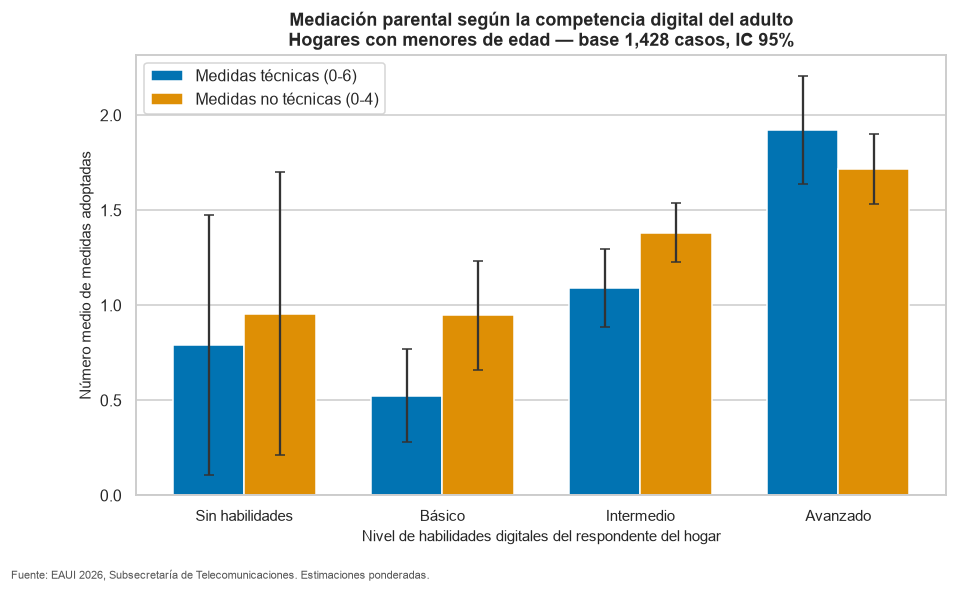

PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/14_mediacion_tecnica_por_nivel.csv')

In [ ]:
# ---------------------------------------------------------------------------
# 16.2 ¿La mediación técnica depende de la competencia digital del adulto?
# ---------------------------------------------------------------------------
sub_parental = base_parental[base_parental["nivel_habilidades"].notna()].copy()

perfil_tecnica = perfil_habilidades(sub_parental, "nivel_habilidades", PESO_HOGAR,
                                    indice="idx_mediacion_tecnica")
perfil_no_tecnica = perfil_habilidades(sub_parental, "nivel_habilidades", PESO_HOGAR,
                                       indice="idx_mediacion_no_tecnica")

titulo("MEDIACIÓN PARENTAL SEGÚN COMPETENCIA DIGITAL DEL ADULTO")
print(f"Base: {len(sub_parental):,} hogares con menores cuyo respondente contestó la batería Q8\n")
print("Medidas TÉCNICAS (0-6) por nivel de habilidades del adulto:")
display(perfil_tecnica.style.format({"media": "{:.2f}", "ic_inf": "{:.2f}", "ic_sup": "{:.2f}",
                                     "dif_vs_total": "{:+.2f}", "poblacion": "{:,.0f}",
                                     "n_efectivo": "{:,.0f}"}))
print("\nMedidas NO TÉCNICAS (0-4) por nivel de habilidades del adulto:")
display(perfil_no_tecnica.style.format({"media": "{:.2f}", "ic_inf": "{:.2f}", "ic_sup": "{:.2f}",
                                        "dif_vs_total": "{:+.2f}", "poblacion": "{:,.0f}",
                                        "n_efectivo": "{:,.0f}"}))

prueba_tec = asociacion(sub_parental, "nivel_habilidades", "usa_mediacion_tecnica", PESO_HOGAR)
print(f"\nAsociación nivel de habilidades × usa mediación técnica:")
print(f"  V de Cramér = {prueba_tec['cramers_v']:.3f} ({prueba_tec['interpretacion']}), "
      f"p = {prueba_tec['p']:.4f}, n = {prueba_tec['n']:,}")

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ancho = 0.36
posiciones = np.arange(len(perfil_tecnica))
ax.bar(posiciones - ancho / 2, perfil_tecnica["media"], ancho,
       yerr=[perfil_tecnica["media"] - perfil_tecnica["ic_inf"],
             perfil_tecnica["ic_sup"] - perfil_tecnica["media"]],
       label="Medidas técnicas (0-6)", color=sns.color_palette(PALETA)[0],
       error_kw={"ecolor": "#333333", "capsize": 3})
ax.bar(posiciones + ancho / 2, perfil_no_tecnica["media"], ancho,
       yerr=[perfil_no_tecnica["media"] - perfil_no_tecnica["ic_inf"],
             perfil_no_tecnica["ic_sup"] - perfil_no_tecnica["media"]],
       label="Medidas no técnicas (0-4)", color=sns.color_palette(PALETA)[1],
       error_kw={"ecolor": "#333333", "capsize": 3})
ax.set_xticks(posiciones)
ax.set_xticklabels(perfil_tecnica.index, fontsize=9.5)
ax.set_ylabel("Número medio de medidas adoptadas")
ax.set_xlabel("Nivel de habilidades digitales del respondente del hogar")
ax.set_title("Mediación parental según la competencia digital del adulto\n"
             f"Hogares con menores de edad — base {len(sub_parental):,} casos, IC 95%")
ax.legend()
ax.grid(axis="x", visible=False)
print(guardar_figura(fig, "14_mediacion_por_competencia"))
plt.show()
guardar_tabla(perfil_tecnica, "14_mediacion_tecnica_por_nivel")

In [ ]:
# ---------------------------------------------------------------------------
# 16.3 Robustez: ¿se sostiene el hallazgo al restringir a informantes jefes/as de hogar?
# ---------------------------------------------------------------------------
# El notebook usa las 5.000 filas. Esta celda reproduce el resultado central del módulo
# parental sobre el subconjunto de jefes/as de hogar, como chequeo de robustez.

solo_jefes = sub_parental[sub_parental["respondente_es_jh"] == "Jefe/a de hogar"]

comparacion_robustez = pd.DataFrame({
    "Todas las filas": perfil_habilidades(sub_parental, "nivel_habilidades", PESO_HOGAR,
                                          indice="idx_mediacion_tecnica")["media"],
    "Solo jefes/as de hogar": perfil_habilidades(solo_jefes, "nivel_habilidades", PESO_HOGAR,
                                                 indice="idx_mediacion_tecnica")["media"],
})
comparacion_robustez["diferencia"] = (comparacion_robustez["Solo jefes/as de hogar"]
                                      - comparacion_robustez["Todas las filas"])

titulo("ROBUSTEZ DEL MÓDULO PARENTAL FRENTE AL CRITERIO DE NIVEL HOGAR")
print(f"Base con todas las filas   : {len(sub_parental):,} hogares con menores")
print(f"Base solo jefes/as de hogar: {len(solo_jefes):,} hogares con menores\n")
print("Medidas técnicas adoptadas (0-6) por nivel de habilidades del adulto:")
display(comparacion_robustez.style.format({"Todas las filas": "{:.2f}",
                                           "Solo jefes/as de hogar": "{:.2f}",
                                           "diferencia": "{:+.2f}"}))

diferencia_maxima = comparacion_robustez["diferencia"].abs().max()
print(f"\nDiferencia absoluta máxima entre ambos criterios: {diferencia_maxima:.2f} medidas.")
if diferencia_maxima < 0.30:
    print("El gradiente es estable: la elección de criterio no altera la conclusión sustantiva.")
else:
    print("El gradiente cambia de forma apreciable. Reportar ambos criterios en cualquier salida.")
guardar_tabla(comparacion_robustez, "14_robustez_criterio_hogar")

ROBUSTEZ DEL MÓDULO PARENTAL FRENTE AL CRITERIO DE NIVEL HOGAR
Base con todas las filas   : 1,428 hogares con menores
Base solo jefes/as de hogar: 803 hogares con menores

Medidas técnicas adoptadas (0-6) por nivel de habilidades del adulto:


,Todas las filas,Solo jefes/as de hogar,diferencia
categoria,,,
Sin habilidades,0.79,0.98,+0.19
Básico,0.53,0.40,-0.12
Intermedio,1.09,0.86,-0.23
Avanzado,1.92,1.64,-0.29



Diferencia absoluta máxima entre ambos criterios: 0.29 medidas.
El gradiente es estable: la elección de criterio no altera la conclusión sustantiva.


PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/14_robustez_criterio_hogar.csv')

---
## 17. Validación conductual y sobredeclaración (Q8 × Q21)

Q8 es autorreporte de capacidad; Q21 registra actividades efectivamente realizadas en los últimos
tres meses. Cruzarlas permite estimar **sobredeclaración**: proporción de quienes declaran la
capacidad sin haber ejecutado nunca la conducta correspondiente.

Es un control de calidad poco frecuente en encuestas de este tipo. La interpretación tiene un
límite claro: no ejecutar una tarea no prueba incapacidad — puede reflejar falta de ocasión. Por eso
se reporta como cota superior de sobredeclaración, no como tasa de error de medición.

VALIDACIÓN CONDUCTUAL: CAPACIDAD DECLARADA vs. CONDUCTA EJECUTADA


,item_q8,items_q21,declara_capacidad_pct,ejecuto_conducta_pct,ejecuta_si_declara_pct,sobredeclaracion_pct,ejecuta_sin_declarar_pct,base_n
habilidad,,,,,,,,
Crear un sitio web,Q8_9,Q21_47 / Q21_40,17.9,10.0,26.6,73.4,6.4,4652
Transacciones bancarias,Q8_17,Q21_34,72.7,64.1,78.7,21.3,25.2,4652
Obtener e instalar software,Q8_6,Q21_48,53.0,12.9,21.5,78.5,3.2,4652
Subir contenidos a RRSS,Q8_13,Q21_15 / Q21_16,58.5,55.3,76.3,23.7,25.6,4652



LECTURA. 'sobredeclaracion_pct' es la proporción de quienes declaran la capacidad y no
ejecutaron la conducta en los últimos 3 meses. Es una COTA SUPERIOR: incluye a quienes
saben hacerlo pero no tuvieron ocasión. 'ejecuta_sin_declarar_pct' es el error opuesto,
subdeclaración de competencia efectiva.


/Users/tomas/github/eaui2026/outputs/habilidades/15_sobredeclaracion.png


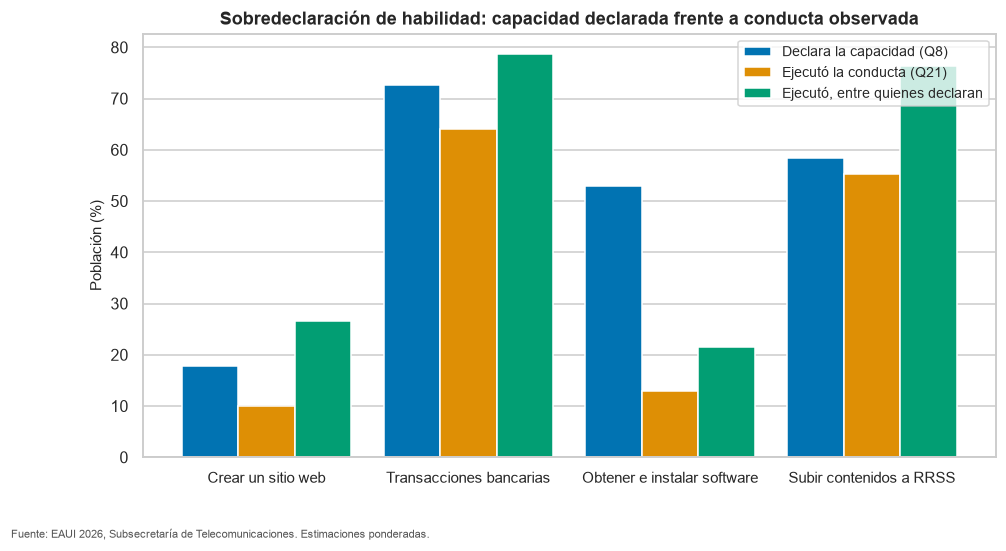

PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/15_validacion_conductual.csv')

In [ ]:
# ---------------------------------------------------------------------------
# 17.1 Capacidad declarada frente a conducta observada
# ---------------------------------------------------------------------------
PARES_VALIDACION = [
    ("Q8_9",  ["Q21_47", "Q21_40"], "Crear un sitio web"),
    ("Q8_17", ["Q21_34"],           "Transacciones bancarias"),
    ("Q8_6",  ["Q21_48"],           "Obtener e instalar software"),
    ("Q8_13", ["Q21_15", "Q21_16"], "Subir contenidos a RRSS"),
]

filas = []
for var_habilidad, vars_conducta, etiqueta_par in PARES_VALIDACION:
    sub = df[df[var_habilidad].notna() & df[vars_conducta].notna().all(axis=1)].copy()
    sub["_conducta"] = (sub[vars_conducta].sum(axis=1) > 0).astype(float)
    declara = sub[sub[var_habilidad] == 1]
    p_declara = proporcion_ponderada(sub[var_habilidad], sub[PESO_PERSONA])[0]
    p_conducta = proporcion_ponderada(sub["_conducta"], sub[PESO_PERSONA])[0]
    p_ejecuta_si_declara = proporcion_ponderada(declara["_conducta"], declara[PESO_PERSONA])[0]
    no_declara = sub[sub[var_habilidad] == 0]
    p_ejecuta_sin_declarar = proporcion_ponderada(no_declara["_conducta"],
                                                  no_declara[PESO_PERSONA])[0]
    filas.append({
        "habilidad": etiqueta_par,
        "item_q8": var_habilidad,
        "items_q21": " / ".join(vars_conducta),
        "declara_capacidad_pct": 100 * p_declara,
        "ejecuto_conducta_pct": 100 * p_conducta,
        "ejecuta_si_declara_pct": 100 * p_ejecuta_si_declara,
        "sobredeclaracion_pct": 100 * (1 - p_ejecuta_si_declara),
        "ejecuta_sin_declarar_pct": 100 * p_ejecuta_sin_declarar,
        "base_n": len(sub),
    })

validacion = pd.DataFrame(filas).set_index("habilidad")

titulo("VALIDACIÓN CONDUCTUAL: CAPACIDAD DECLARADA vs. CONDUCTA EJECUTADA")
display(validacion.style.format({c: "{:.1f}" for c in validacion.columns if c.endswith("_pct")}))
print("\nLECTURA. 'sobredeclaracion_pct' es la proporción de quienes declaran la capacidad y no")
print("ejecutaron la conducta en los últimos 3 meses. Es una COTA SUPERIOR: incluye a quienes")
print("saben hacerlo pero no tuvieron ocasión. 'ejecuta_sin_declarar_pct' es el error opuesto,")
print("subdeclaración de competencia efectiva.")

fig, ax = plt.subplots(figsize=(10, 5))
posiciones = np.arange(len(validacion))
ancho = 0.28
ax.bar(posiciones - ancho, validacion["declara_capacidad_pct"], ancho,
       label="Declara la capacidad (Q8)", color=sns.color_palette(PALETA)[0])
ax.bar(posiciones, validacion["ejecuto_conducta_pct"], ancho,
       label="Ejecutó la conducta (Q21)", color=sns.color_palette(PALETA)[1])
ax.bar(posiciones + ancho, validacion["ejecuta_si_declara_pct"], ancho,
       label="Ejecutó, entre quienes declaran", color=sns.color_palette(PALETA)[2])
ax.set_xticks(posiciones)
ax.set_xticklabels(validacion.index, fontsize=9.5)
ax.set_ylabel("Población (%)")
ax.set_title("Sobredeclaración de habilidad: capacidad declarada frente a conducta observada")
ax.legend(fontsize=9)
ax.grid(axis="x", visible=False)
print(guardar_figura(fig, "15_sobredeclaracion"))
plt.show()
guardar_tabla(validacion, "15_validacion_conductual")

---
## 18. Síntesis, exportaciones y limitaciones

In [ ]:
# ---------------------------------------------------------------------------
# 18.1 Tablero resumen de hallazgos
# ---------------------------------------------------------------------------
media_hab = media_ponderada(df["hab_total"], df[PESO_PERSONA])
dist_nivel_final = distribucion_ponderada(df, "nivel_habilidades", PESO_PERSONA)
top_factores = ESTRUCTURALES.head(5)

resumen = {
    "Base persona (n muestral)": f"{len(df):,}",
    "Base persona (expandida)": f"{df[PESO_PERSONA].sum():,.0f} personas",
    "Base hogar (n muestral)": f"{len(df_hogar):,}",
    "Base hogar (expandida)": f"{df_hogar[PESO_HOGAR].sum():,.0f} hogares",
    "Base batería Q8": f"{int(en_base_q8.sum()):,}",
    "Media del índice de habilidades (0-18)": f"{media_hab[0]:.2f} [{media_hab[1]:.2f}, {media_hab[2]:.2f}]",
    "KR-20 de la batería Q8": f"{kr20(matriz_q8):.3f}",
    "Reproducibilidad de Guttman": f"{reproducibilidad:.3f}",
    "Sin habilidades digitales": f"{dist_nivel_final.loc['Sin habilidades', 'pct']:.1f}%",
    "Nivel avanzado": f"{dist_nivel_final.loc['Avanzado', 'pct']:.1f}%",
    "Usa IA generativa (Q8_18)": f"{prevalencia_q8.loc[prevalencia_q8['variable'] == 'Q8_18', 'pct'].iloc[0]:.1f}%",
    "Índice de seguridad (0-6)": f"{media_seg:.2f}",
    "Falsa seguridad (protegido sin práctica)": f"{falsa_seguridad:.1f}%",
    "Factor más estructurante": f"{top_factores.iloc[0]['etiqueta']} (V = {top_factores.iloc[0]['cramers_v']:.3f})",
}

titulo("TABLERO RESUMEN — EAUI 2026, HABILIDADES DIGITALES")
for clave, valor in resumen.items():
    print(f"  {clave:<44} {valor}")

print("\n\nCINCO FACTORES MÁS ESTRUCTURANTES DE LA COMPETENCIA DIGITAL")
print("-" * 78)
for _, fila in top_factores.iterrows():
    marca = "*" if fila["significativo"] else " "
    print(f"  {marca} {fila['etiqueta']:<42} V = {fila['cramers_v']:.3f}  ({fila['interpretacion']})")
print("\n  * significativo tras corrección de Benjamini-Hochberg (alfa = 0,05)")

guardar_tabla(pd.Series(resumen, name="valor").to_frame(), "16_tablero_resumen")

TABLERO RESUMEN — EAUI 2026, HABILIDADES DIGITALES
  Base persona (n muestral)                    5,000
  Base persona (expandida)                     13,810,761 personas
  Base hogar (n muestral)                      5,000
  Base hogar (expandida)                       5,651,637 hogares
  Base batería Q8                              4,758
  Media del índice de habilidades (0-18)       9.73 [9.47, 10.00]
  KR-20 de la batería Q8                       0.932
  Reproducibilidad de Guttman                  0.854
  Sin habilidades digitales                    2.3%
  Nivel avanzado                               42.8%
  Usa IA generativa (Q8_18)                    40.6%
  Índice de seguridad (0-6)                    2.16
  Falsa seguridad (protegido sin práctica)     33.8%
  Factor más estructurante                     Hay computador en el hogar (V = 0.383)


CINCO FACTORES MÁS ESTRUCTURANTES DE LA COMPETENCIA DIGITAL
---------------------------------------------------------------------------

PosixPath('/Users/tomas/github/eaui2026/outputs/habilidades/16_tablero_resumen.csv')

In [ ]:
# ---------------------------------------------------------------------------
# 18.2 Exportación del dataset analítico
# ---------------------------------------------------------------------------
COLUMNAS_ANALITICAS = (
    ["id", "region", "macrozona", "zona", "parentesco_jh",
     "sexo", "edad", "tramo_edad", "generacion",
     "educ", "educ_grupo", "educ_jh", "educ_jh_grupo",
     "ocupacion_encuestado", "ocupado", "ocupacion_jh",
     "situacion_laboral_hogar", "hogar_con_cesantes", "hogar_con_estudiantes",
     "gse", "gse_grupo", "ingreso_pm", "ingreso_tramo_rel", "quintil_ingreso",
     "pueblo_originario", "condicion_larga_duracion", "hogar_con_menores",
     "acceso_internet_hogar", "tiene_computador",
     "uso_computador", "uso_smartphone", "smartphone_propio", "computador_uso",
     "usuario_internet", "ultimo_uso_internet", "frecuencia_internet",
     "tiempo_diario_internet", "n_lugares_uso",
     "hab_total", "hab_basicas", "hab_medias", "hab_avanzadas", "hab_emergente",
     "prop_basicas", "prop_medias", "prop_avanzadas", "nivel_habilidades",
     "idx_seguridad", "nivel_seguridad", "percepcion_proteccion", "se_siente_protegido",
     "sin_competencia_declarada", "adquisicion_formal", "adquisicion_informal",
     "adquisicion_laboral", "n_vias_adquisicion",
     "fe_personas", "fe_hogar", "pond_personas", "pond_hogar"]
    + Q8_VARS + [Q8_NINGUNA] + list(Q6_ADQUISICION) + list(Q32_NUCLEO)
)
COLUMNAS_ANALITICAS = [c for c in dict.fromkeys(COLUMNAS_ANALITICAS) if c in df.columns]

df_analitico = df[COLUMNAS_ANALITICAS].copy()
ruta_dataset = DIR_SALIDA / "eaui2026_habilidades_analitico.csv"
df_analitico.to_csv(ruta_dataset, index=False, encoding="utf-8-sig")

# Diccionario de variables derivadas, para que el CSV sea autoexplicativo
diccionario = pd.DataFrame([
    ("hab_total", "Índice sumativo de habilidades Q8_1..Q8_18 (0-18)", "Persona"),
    ("hab_basicas", "Habilidades básicas declaradas (0-6)", "Persona"),
    ("hab_medias", "Habilidades medias declaradas (0-8)", "Persona"),
    ("hab_avanzadas", "Habilidades avanzadas declaradas (0-3)", "Persona"),
    ("hab_emergente", "Uso declarado de IA generativa (0-1)", "Persona"),
    ("nivel_habilidades", "Clasificación jerárquica: Sin habilidades / Básico / Intermedio / Avanzado", "Persona"),
    ("idx_seguridad", "Prácticas de seguridad Q32_1..Q32_6 (0-6). Excluye el NET Q32_7", "Persona"),
    ("gse", "GSE AIM-ESOMAR desde educación (A10) y ocupación (A11) del jefe de hogar", "Hogar"),
    ("ingreso_pm", "Punto medio en pesos del tramo A12_1, armonizado entre las 10 tarjetas", "Hogar"),
    ("ingreso_tramo_rel", "Posición relativa (septil) dentro de la tarjeta de tramos aplicada", "Hogar"),
    ("quintil_ingreso", "Quintil del punto medio, calculado sobre la distribución ponderada", "Hogar"),
    ("n_lugares_uso", "Diversidad de lugares de uso el último día (Q11_1_*), proxy de autonomía", "Persona"),
    ("sin_competencia_declarada", "Declara en Q6_7 no saber usar computador", "Persona"),
    ("adquisicion_formal", "Aprendió por vía formal (Q6_3, Q6_4, Q6_5)", "Persona"),
    ("adquisicion_informal", "Aprendió por vía informal (Q6_11, Q6_2, Q6_111)", "Persona"),
    ("situacion_laboral_hogar", "Situación laboral predominante del hogar (A14_*)", "Hogar"),
], columns=["variable", "definicion", "nivel"]).set_index("variable")

guardar_tabla(diccionario, "17_diccionario_variables_derivadas")

titulo("EXPORTACIONES")
print(f"Dataset analítico : {ruta_dataset.name}  ({df_analitico.shape[0]:,} × {df_analitico.shape[1]})")
archivos = sorted(DIR_SALIDA.glob("*"))
print(f"\nArchivos en {DIR_SALIDA} ({len(archivos)}):")
for archivo in archivos:
    print(f"  {archivo.name:<52} {archivo.stat().st_size/1024:>8,.1f} KB")

EXPORTACIONES
Dataset analítico : eaui2026_habilidades_analitico.csv  (5,000 × 93)

Archivos en /Users/tomas/github/eaui2026/outputs/habilidades (50):
  00_control_informante_hogar.csv                           0.3 KB
  01_prevalencia_habilidades_q8.png                       293.8 KB
  01_prevalencia_q8.csv                                     2.8 KB
  02_distribucion_indice_habilidades.png                  170.8 KB
  02_nivel_habilidades.csv                                  0.4 KB
  03_correlaciones_q8.png                                 384.1 KB
  04_dimensionalidad_guttman.png                          265.7 KB
  05_inventario_variables_cruce.csv                         2.9 KB
  05_ranking_factores.png                                 338.3 KB
  05b_variables_descartadas.csv                             0.9 KB
  06_brechas_por_factor.png                               441.6 KB
  06_mapa_asociaciones.csv                                  6.1 KB
  07_composicion_nivel_por_factor.png        

---
### 18.3 Limitaciones

**De medición**

1. Toda la batería Q8 es **autorreporte de capacidad**, no evaluación de desempeño. La literatura
   documenta sobreestimación sistemática en hombres y subestimación en mujeres y adultos mayores.
   Las brechas de género y edad estimadas aquí son brechas *de declaración*; su componente de
   competencia efectiva no es separable con este instrumento. La sección 17 acota el problema por
   arriba, sin resolverlo.
2. `Q8_19` es lógicamente consistente (verificado en 4.3), de modo que el índice sumativo no
   requiere depuración adicional.

**De diseño muestral**

3. El archivo no incluye identificadores de estrato ni de conglomerado, por lo que no es posible
   estimar la varianza con el diseño completo. Los intervalos de confianza usan el **n efectivo de
   Kish**, que corrige por la variabilidad de los pesos pero no por la conglomeración. Son, por
   tanto, **cotas inferiores** del error real.
4. Los chi-cuadrado se calculan sobre pesos reescalados al n muestral. Es una aproximación al
   ajuste de Rao-Scott, no el ajuste exacto.

**De unidad de análisis**

5. Las habilidades se miden a nivel persona (`fe_personas`); mediación parental y barreras de acceso,
   a nivel hogar (`fe_hogar`). No son combinables sin decisión metodológica explícita. Donde se
   cruzan (sección 16), el cruce es válido porque **la misma fila y la misma persona** contestan
   ambos módulos.
6. El nivel hogar usa **las 5.000 filas** con `fe_hogar`, sin filtrar por `parentesco_jh`. La
   sección 5 verifica el supuesto (`POND_HOGAR` suma el n muestral sobre el archivo completo) y la
   sección 7.3 comprueba que quién actuó como informante no sesga las variables del módulo hogar.
   En el ~40% de los hogares el informante no fue el jefe/a; el módulo hogar pregunta por el hogar,
   no por el informante, de modo que esas filas son información válida de hogar. La sección 16.3
   reproduce el resultado parental sobre el subconjunto de jefes/as como chequeo de robustez.

**De base**

7. `Q34`, `Q36` y `Q37` tienen bases de 269, 48 y 269 casos. Algunas celdas quedan bajo n = 20. Sirven
   para caracterización descriptiva con n explícito, no para inferencia desagregada.
8. `Q2` (actividad principal) está **vacía en el archivo**. Es la pérdida más relevante: impide
   distinguir ocupados, cesantes, jubilados y estudiantes. Se sustituye por `Q1_4` (ocupación
   ESOMAR) y `A14_*` (situaciones laborales del hogar), que capturan menos.
9. `Q38_1`–`Q38_6` carecen de enunciado matriz en las etiquetas SPSS y tienen entre 2 y 43 casos.
   Quedan fuera del análisis hasta poder consultar el cuestionario original.
10. `A12_1` aplica **diez tarjetas de tramos distintas**. La armonización de la sección 6.4 asume
    que la posición relativa es comparable entre tarjetas. Si las tarjetas se asignaron por tamaño
    del hogar, `ingreso_pm` es ingreso del hogar sin ajustar por número de miembros.

**De inferencia causal**

11. Todo lo anterior es **descriptivo y asociativo**. Las V de Cramér de la sección 11 ordenan
    factores por asociación bivariada, no por efecto causal: educación, GSE, edad e ingreso están
    fuertemente correlacionados entre sí. Separar sus contribuciones requiere un modelo multivariado,
    fuera del alcance de este notebook exploratorio.

### 18.4 Próximos pasos sugeridos

- Análisis de clases latentes sobre los 18 ítems dicotómicos, como alternativa a la clasificación
  jerárquica de `nivel_habilidades`.
- Análisis factorial sobre correlaciones tetracóricas (no de Pearson) para confirmar la
  dimensionalidad con la métrica correcta para ítems dicotómicos.
- Modelo multivariado (regresión ordinal o logística multinomial ponderada) para separar los efectos
  de edad, educación, GSE e ingreso, hoy confundidos en las asociaciones bivariadas.

---
## 19. Análisis de clases latentes (alternativa a `nivel_habilidades`)

`nivel_habilidades` (sección 8) se construye con una regla jerárquica tipo Guttman: el nivel lo
fija el ítem más difícil que la persona declara dominar. Esa regla asume que las 18 competencias
forman una escala acumulativa perfecta. El análisis de clases latentes (LCA) no impone esa
estructura: agrupa personas según el **patrón conjunto** de respuestas a los 18 ítems dicotómicos,
dejando que los datos determinen cuántos perfiles existen y qué combinación de competencias los
caracteriza (por ejemplo, un perfil "ofimática sin multimedia" que la regla jerárquica no puede
representar porque no es un subconjunto anidado de otro).

Se implementa un LCA binario mediante EM (sin dependencias externas): cada clase $k$ se define por
una probabilidad de pertenencia $\pi_k$ y un vector de probabilidades de respuesta ítem por ítem
$\theta_{kj} = P(Q8_j = 1 \mid \text{clase } k)$, asumiendo independencia condicional entre ítems
dado la clase (supuesto de independencia local, estándar en LCA).

In [ ]:
# ---------------------------------------------------------------------------
# 19.1 Estimación EM del modelo de clases latentes
# ---------------------------------------------------------------------------
from scipy.special import logsumexp


def ajustar_lca(datos, k, n_iter=300, tol=1e-7, n_inicios=8, semilla=SEMILLA):
    """LCA binario vía EM con reinicios aleatorios; devuelve el mejor óptimo local por log-verosimilitud."""
    X = datos.to_numpy(dtype=float)
    n, j = X.shape
    rng = np.random.default_rng(semilla)
    mejor = None

    for inicio in range(n_inicios):
        pi = np.full(k, 1.0 / k)
        theta = rng.uniform(0.15, 0.85, size=(k, j))
        log_lik_prev = -np.inf

        for _ in range(n_iter):
            log_theta = np.log(np.clip(theta, 1e-8, 1 - 1e-8))
            log_1_theta = np.log(np.clip(1 - theta, 1e-8, 1 - 1e-8))
            log_p_xc = X @ log_theta.T + (1 - X) @ log_1_theta.T
            log_p_xc += np.log(np.clip(pi, 1e-12, 1))[None, :]
            log_norm = logsumexp(log_p_xc, axis=1)
            log_lik = float(log_norm.sum())
            resp = np.exp(log_p_xc - log_norm[:, None])

            n_k = resp.sum(axis=0)
            pi = n_k / n
            theta = (resp.T @ X) / n_k[:, None]
            theta = np.clip(theta, 1e-6, 1 - 1e-6)

            if abs(log_lik - log_lik_prev) < tol:
                break
            log_lik_prev = log_lik

        if mejor is None or log_lik > mejor["log_lik"]:
            n_parametros = (k - 1) + k * j
            mejor = {
                "k": k, "pi": pi, "theta": theta, "resp": resp,
                "clases": resp.argmax(axis=1), "log_lik": log_lik,
                "bic": -2 * log_lik + n_parametros * np.log(n),
                "aic": -2 * log_lik + 2 * n_parametros,
                "n_parametros": n_parametros,
            }
    return mejor


CANDIDATOS_K = range(2, 7)
modelos_lca = {k: ajustar_lca(matriz_q8, k) for k in CANDIDATOS_K}

comparacion_lca = pd.DataFrame([
    {"k": k, "log_verosim": m["log_lik"], "n_parametros": m["n_parametros"],
     "AIC": m["aic"], "BIC": m["bic"]}
    for k, m in modelos_lca.items()
]).set_index("k")

titulo("SELECCIÓN DEL NÚMERO DE CLASES LATENTES (EM, 8 reinicios por k)")
print(comparacion_lca.round(1).to_string())
k_optimo = comparacion_lca["BIC"].idxmin()
print(f"\nk óptimo según BIC: {k_optimo} clases")


SELECCIÓN DEL NÚMERO DE CLASES LATENTES (EM, 8 reinicios por k)
   log_verosim  n_parametros       AIC       BIC
k                                               
2   -37,668.40            37 75,410.90 75,650.20
3   -35,613.30            56 71,338.70 71,700.90
4   -34,827.00            75 69,804.00 70,289.10
5   -34,308.60            94 68,805.20 69,413.20
6   -34,017.80           113 68,261.70 68,992.50

k óptimo según BIC: 6 clases


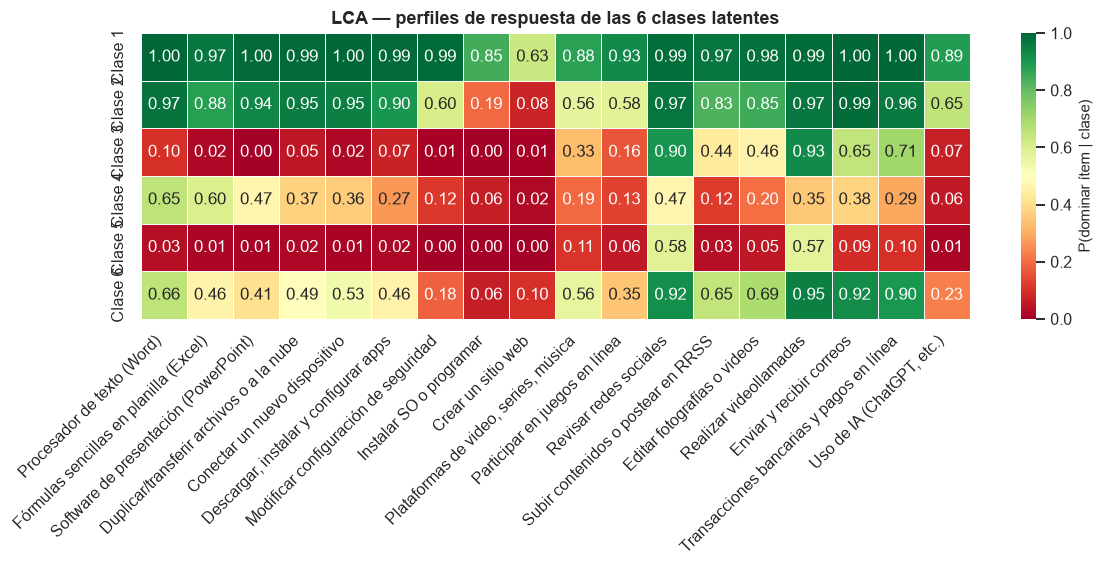

TAMAÑO PONDERADO DE LAS CLASES
              n  casos_expandidos   pct  ic_inf  ic_sup
categoria                                              
Clase 1     601      2,561,433.68 19.28   17.44   21.12
Clase 2     967      3,236,161.40 24.36   22.36   26.36
Clase 3     848      2,044,165.66 15.39   13.70   17.07
Clase 4     326        854,292.37  6.43    5.29    7.57
Clase 5    1230      2,453,949.36 18.47   16.66   20.28
Clase 6     786      2,136,223.13 16.08   14.37   17.79


In [ ]:
# ---------------------------------------------------------------------------
# 19.2 Perfiles de la solución seleccionada
# ---------------------------------------------------------------------------
modelo_final = modelos_lca[k_optimo]
perfiles = pd.DataFrame(modelo_final["theta"], columns=Q8_VARS,
                         index=[f"Clase {c+1}" for c in range(k_optimo)])
perfiles.columns = [Q8_ITEMS[col][0] for col in Q8_VARS]

fig, ax = plt.subplots(figsize=(11, 0.55 * k_optimo + 2))
sns.heatmap(perfiles, cmap="RdYlGn", vmin=0, vmax=1, annot=True, fmt=".2f",
            cbar_kws={"label": "P(dominar ítem | clase)"}, ax=ax, linewidths=0.4)
ax.set_title(f"LCA — perfiles de respuesta de las {k_optimo} clases latentes")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(DIR_SALIDA / "19_lca_perfiles.png")
plt.show()

df.loc[en_base_q8, "clase_lca"] = pd.Categorical(
    [f"Clase {c+1}" for c in modelo_final["clases"]],
    categories=[f"Clase {c+1}" for c in range(k_optimo)])

tam_clases = distribucion_ponderada(df.loc[en_base_q8], "clase_lca", PESO_PERSONA)
titulo("TAMAÑO PONDERADO DE LAS CLASES")
print(tam_clases.to_string())


In [ ]:
# ---------------------------------------------------------------------------
# 19.3 Clases latentes frente a nivel_habilidades jerárquico
# ---------------------------------------------------------------------------
cruce_lca_nivel = pd.crosstab(df.loc[en_base_q8, "clase_lca"],
                               df.loc[en_base_q8, "nivel_habilidades"],
                               values=df.loc[en_base_q8, PESO_PERSONA], aggfunc="sum", normalize="index") * 100

titulo("COMPOSICIÓN DE CADA CLASE LATENTE SEGÚN EL NIVEL JERÁRQUICO (% fila, ponderado)")
print(cruce_lca_nivel.round(1).to_string())
print()
print("LECTURA. Si el LCA reprodujera la escala de Guttman, cada clase caería casi por completo en un")
print("único nivel jerárquico. La medida en que las clases se reparten entre niveles indica cuánta")
print("heterogeneidad de perfiles (combinaciones de competencias) queda oculta tras la etiqueta única")
print("de nivel_habilidades.")


COMPOSICIÓN DE CADA CLASE LATENTE SEGÚN EL NIVEL JERÁRQUICO (% fila, ponderado)
nivel_habilidades  Sin habilidades  Básico  Intermedio  Avanzado
clase_lca                                                       
Clase 1                       0.00    0.00        0.00    100.00
Clase 2                       0.00    0.00       28.80     71.20
Clase 3                       0.00    3.00       95.90      1.00
Clase 4                       0.00    0.20       86.00     13.80
Clase 5                      12.60   62.50       23.70      1.30
Clase 6                       0.00    0.00       69.70     30.30

LECTURA. Si el LCA reprodujera la escala de Guttman, cada clase caería casi por completo en un
único nivel jerárquico. La medida en que las clases se reparten entre niveles indica cuánta
heterogeneidad de perfiles (combinaciones de competencias) queda oculta tras la etiqueta única
de nivel_habilidades.


---
## 20. Dimensionalidad con correlaciones tetracóricas

Los 18 ítems Q8 son dicotómicos. La correlación de Pearson entre dos variables 0/1 (el coeficiente
**phi**, usado en la sección de correlaciones de este notebook) subestima sistemáticamente la
asociación cuando los ítems tienen prevalencias distintas — atenúa la correlación hacia cero incluso
si el rasgo latente continuo subyacente está perfectamente correlacionado. La correlación
**tetracórica** estima la correlación de las variables normales latentes que se asume generan cada
ítem binario al cruzar un umbral, y es la métrica correcta para analizar la dimensionalidad de una
batería dicotómica. Aquí se calcula por máxima verosimilitud (sin paquetes externos) y se compara la
estructura factorial resultante con la que arrojaría, sobre los mismos ítems, una matriz de
Pearson/phi.

In [ ]:
# ---------------------------------------------------------------------------
# 20.1 Correlación tetracórica ítem a ítem (MLE bajo normalidad bivariada latente)
# ---------------------------------------------------------------------------
from scipy import optimize


def _prob_conjunta_11(tx, ty, rho):
    """P(Zx > tx, Zy > ty) bajo normal bivariada estándar con correlación rho."""
    cov = [[1.0, rho], [rho, 1.0]]
    f_xy = stats.multivariate_normal(mean=[0, 0], cov=cov).cdf([tx, ty])
    return 1 - stats.norm.cdf(tx) - stats.norm.cdf(ty) + f_xy


def correlacion_tetracorica(x, y):
    """Correlación tetracórica de dos ítems 0/1 vía tabla 2x2, con corrección de continuidad
    en celdas vacías para evitar umbrales infinitos."""
    tabla = pd.crosstab(x, y).reindex(index=[0, 1], columns=[0, 1], fill_value=0).to_numpy(float)
    if (tabla == 0).any():
        tabla = tabla + 0.5
    n = tabla.sum()
    p_x1, p_y1, p11 = tabla[1, :].sum() / n, tabla[:, 1].sum() / n, tabla[1, 1] / n
    tx, ty = stats.norm.ppf(1 - p_x1), stats.norm.ppf(1 - p_y1)
    objetivo = lambda rho: _prob_conjunta_11(tx, ty, rho) - p11
    try:
        return optimize.brentq(objetivo, -0.999, 0.999)
    except ValueError:
        return np.nan


matriz_tetracorica = pd.DataFrame(np.eye(len(Q8_VARS)), index=Q8_VARS, columns=Q8_VARS)
for a, b in combinations(Q8_VARS, 2):
    rho = correlacion_tetracorica(matriz_q8[a], matriz_q8[b])
    matriz_tetracorica.loc[a, b] = matriz_tetracorica.loc[b, a] = rho

matriz_phi = matriz_q8.corr()  # Pearson == phi con ítems 0/1

titulo("MAGNITUD PROMEDIO DE LA ASOCIACIÓN: TETRACÓRICA VS. PHI/PEARSON")
offdiag = ~np.eye(len(Q8_VARS), dtype=bool)
print(f"|r| promedio tetracórica : {np.nanmean(np.abs(matriz_tetracorica.to_numpy()[offdiag])):.3f}")
print(f"|r| promedio phi/Pearson : {np.nanmean(np.abs(matriz_phi.to_numpy()[offdiag])):.3f}")


MAGNITUD PROMEDIO DE LA ASOCIACIÓN: TETRACÓRICA VS. PHI/PEARSON
|r| promedio tetracórica : 0.671
|r| promedio phi/Pearson : 0.422


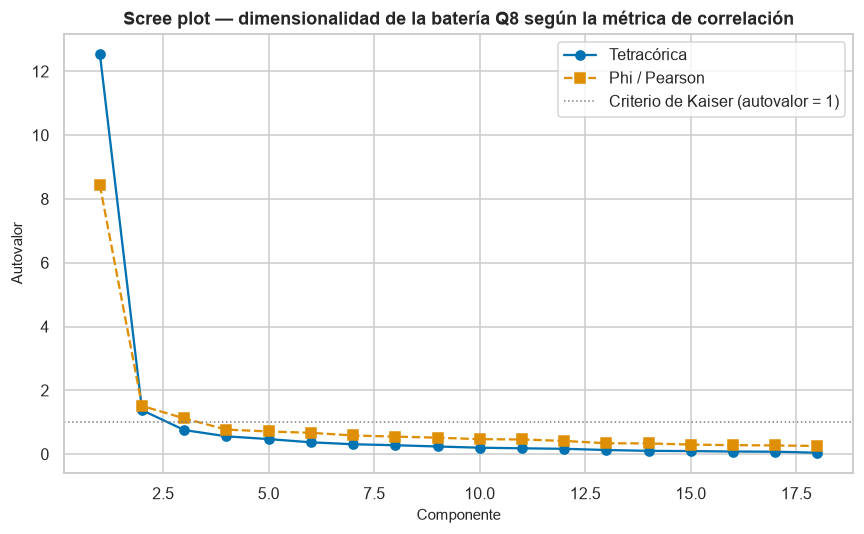

FACTORES SUGERIDOS (criterio de Kaiser)
Sobre correlaciones tetracóricas : 2
Sobre correlaciones phi/Pearson  : 3


In [ ]:
# ---------------------------------------------------------------------------
# 20.2 Dimensionalidad: scree de autovalores, tetracórica vs. phi
# ---------------------------------------------------------------------------
autoval_tetra = np.sort(np.linalg.eigvalsh(matriz_tetracorica.to_numpy()))[::-1]
autoval_phi = np.sort(np.linalg.eigvalsh(matriz_phi.to_numpy()))[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(autoval_tetra) + 1), autoval_tetra, "o-", label="Tetracórica")
ax.plot(range(1, len(autoval_phi) + 1), autoval_phi, "s--", label="Phi / Pearson")
ax.axhline(1, color="grey", linestyle=":", linewidth=1, label="Criterio de Kaiser (autovalor = 1)")
ax.set_xlabel("Componente")
ax.set_ylabel("Autovalor")
ax.set_title("Scree plot — dimensionalidad de la batería Q8 según la métrica de correlación")
ax.legend()
plt.tight_layout()
plt.savefig(DIR_SALIDA / "20_scree_tetracorica.png")
plt.show()

n_factores_tetra = int((autoval_tetra > 1).sum())
n_factores_phi = int((autoval_phi > 1).sum())
titulo("FACTORES SUGERIDOS (criterio de Kaiser)")
print(f"Sobre correlaciones tetracóricas : {n_factores_tetra}")
print(f"Sobre correlaciones phi/Pearson  : {n_factores_phi}")


In [ ]:
# ---------------------------------------------------------------------------
# 20.3 Cargas factoriales sobre la matriz tetracórica (factorización de eje principal)
# ---------------------------------------------------------------------------
def factorizar_eje_principal(matriz_corr, n_factores):
    """Factorización de eje principal simple: autovectores/autovalores de la matriz de correlación,
    con cargas = autovector * sqrt(autovalor). Suficiente para describir estructura, no para SEM."""
    autoval, autovec = np.linalg.eigh(matriz_corr.to_numpy())
    orden = np.argsort(autoval)[::-1][:n_factores]
    cargas = autovec[:, orden] * np.sqrt(np.clip(autoval[orden], 0, None))
    return pd.DataFrame(cargas, index=matriz_corr.index,
                         columns=[f"Factor {i+1}" for i in range(n_factores)])


n_factores_final = max(n_factores_tetra, 1)
cargas_tetra = factorizar_eje_principal(matriz_tetracorica, n_factores_final)
cargas_tetra.index = [Q8_ITEMS[i][0] for i in cargas_tetra.index]

titulo(f"CARGAS FACTORIALES SOBRE LA MATRIZ TETRACÓRICA ({n_factores_final} factores)")
print(cargas_tetra.round(2).sort_values("Factor 1", ascending=False).to_string())
print()
print("LECTURA. La comparación con el scree de phi/Pearson (20.2) muestra si trabajar con la métrica")
print("de correlación adecuada para ítems dicotómicos cambia el número de dimensiones que conviene")
print("retener respecto al que sugeriría un análisis de componentes hecho directamente sobre 0/1.")


CARGAS FACTORIALES SOBRE LA MATRIZ TETRACÓRICA (2 factores)
                                          Factor 1  Factor 2
Conectar un nuevo dispositivo                 0.93      0.19
Duplicar/transferir archivos o a la nube      0.92      0.22
Software de presentación (PowerPoint)         0.91      0.29
Descargar, instalar y configurar apps         0.91      0.15
Modificar configuración de seguridad          0.91      0.14
Enviar y recibir correos                      0.89     -0.12
Procesador de texto (Word)                    0.88      0.27
Uso de IA (ChatGPT, etc.)                     0.88      0.01
Fórmulas sencillas en planilla (Excel)        0.86      0.30
Instalar SO o programar                       0.85      0.23
Transacciones bancarias y pagos en línea      0.85     -0.21
Subir contenidos o postear en RRSS            0.84     -0.29
Editar fotografías o videos                   0.83     -0.23
Participar en juegos en línea                 0.79     -0.09
Crear un sitio web       

---
## 21. Modelo multivariado: separando edad, educación, GSE e ingreso

Las secciones bivariadas de este notebook cruzan `nivel_habilidades` con un factor a la vez. Como
edad, educación, GSE e ingreso están correlacionados entre sí en la población, esas asociaciones
bivariadas mezclan el efecto propio de cada factor con el de los demás (por ejemplo, parte de la
brecha por edad puede deberse a que las personas mayores tienen, en promedio, menor GSE). Se ajustan
dos modelos multivariados ponderados por `FE_PERSONAS` que estiman el efecto de cada predictor
**controlando por los otros tres**:

1. Una **regresión logística multinomial ponderada** (referencia: "Sin habilidades") — el modelo
   principal, sin asumir que los niveles están equiespaciados.
2. Una **regresión logística ordinal** (logit acumulado, sin ponderar por no estar disponible en la
   implementación usada) como verificación de robustez, que sí explota el orden de los niveles.

In [ ]:
# ---------------------------------------------------------------------------
# 21.1 Base y especificación del modelo
# ---------------------------------------------------------------------------
import patsy
from sklearn.linear_model import LogisticRegression
import statsmodels
from statsmodels.miscmodels.ordinal_model import OrderedModel

VARS_MODELO = ["nivel_habilidades", "edad", "educ_grupo", "gse", "quintil_ingreso", PESO_PERSONA]
base_modelo = df.loc[en_base_q8, VARS_MODELO].dropna().copy()
base_modelo["edad_z"] = (base_modelo["edad"] - base_modelo["edad"].mean()) / base_modelo["edad"].std()

FORMULA_MODELO = "edad_z + C(educ_grupo) + C(gse) + C(quintil_ingreso)"

titulo("BASE DEL MODELO MULTIVARIADO")
print(f"n muestral      : {len(base_modelo):,} (con edad, educación, GSE, ingreso y batería Q8 completas)")
print(f"n expandido      : {base_modelo[PESO_PERSONA].sum():,.0f} personas")
print(distribucion_ponderada(base_modelo, "nivel_habilidades", PESO_PERSONA).round(1).to_string())


BASE DEL MODELO MULTIVARIADO
n muestral      : 4,005 (con edad, educación, GSE, ingreso y batería Q8 completas)
n expandido      : 10,780,196 personas
                    n  casos_expandidos   pct  ic_inf  ic_sup
categoria                                                    
Sin habilidades   141        244,810.70  2.30    1.50    3.00
Básico            635      1,175,787.20 10.90    9.30   12.50
Intermedio       1878      4,511,086.30 41.80   39.40   44.30
Avanzado         1351      4,848,512.30 45.00   42.50   47.50


In [ ]:
# ---------------------------------------------------------------------------
# 21.2 Regresión logística multinomial ponderada (modelo principal)
# ---------------------------------------------------------------------------
y_multi = base_modelo["nivel_habilidades"].astype(str)
X_multi = patsy.dmatrix(FORMULA_MODELO, data=base_modelo, return_type="dataframe").drop(columns="Intercept")
peso_norm = (base_modelo[PESO_PERSONA] / base_modelo[PESO_PERSONA].mean()).to_numpy()

modelo_multinomial = LogisticRegression(max_iter=3000, C=10.0)
modelo_multinomial.fit(X_multi, y_multi, sample_weight=peso_norm)

REFERENCIA_NIVEL = "Sin habilidades"
idx_ref = list(modelo_multinomial.classes_).index(REFERENCIA_NIVEL)


def bootstrap_contrastes(x, y, pesos, referencia_idx, n_rep=200, semilla=SEMILLA):
    """Bootstrap ponderado (remuestreo con probabilidad proporcional al peso) de los contrastes
    de coeficientes (clase - referencia) del multinomial. Sustituye a un error estándar de diseño
    muestral que la implementación de sklearn no provee."""
    rng = np.random.default_rng(semilla)
    n = len(x)
    probs = pesos / pesos.sum()
    contrastes = []
    for _ in range(n_rep):
        idx = rng.choice(n, size=n, replace=True, p=probs)
        modelo_b = LogisticRegression(max_iter=3000, C=10.0)
        modelo_b.fit(x.iloc[idx], y.iloc[idx], sample_weight=np.ones(n))
        clases_b = list(modelo_b.classes_)
        if referencia_idx >= len(clases_b):
            continue
        contraste = modelo_b.coef_ - modelo_b.coef_[clases_b.index(REFERENCIA_NIVEL)]
        contrastes.append(contraste)
    return np.stack(contrastes)


contrastes_boot = bootstrap_contrastes(X_multi, y_multi, base_modelo[PESO_PERSONA].to_numpy(), idx_ref)

coef_ref = modelo_multinomial.coef_ - modelo_multinomial.coef_[idx_ref]
li_boot, ls_boot = np.percentile(contrastes_boot, [2.5, 97.5], axis=0)

filas_modelo = []
for c, clase in enumerate(modelo_multinomial.classes_):
    if clase == REFERENCIA_NIVEL:
        continue
    for p, predictor in enumerate(X_multi.columns):
        filas_modelo.append({
            "nivel (vs. Sin habilidades)": clase, "predictor": predictor,
            "OR": np.exp(coef_ref[c, p]),
            "OR_li95": np.exp(li_boot[c, p]), "OR_ls95": np.exp(ls_boot[c, p]),
        })
tabla_multinomial = pd.DataFrame(filas_modelo)
tabla_multinomial["significativo"] = ~((tabla_multinomial["OR_li95"] <= 1) & (tabla_multinomial["OR_ls95"] >= 1))

titulo("ODDS RATIOS DEL MULTINOMIAL PONDERADO (IC 95% por bootstrap ponderado, 200 réplicas)")
print(tabla_multinomial.round(2).to_string(index=False))


ODDS RATIOS DEL MULTINOMIAL PONDERADO (IC 95% por bootstrap ponderado, 200 réplicas)
nivel (vs. Sin habilidades)                        predictor    OR  OR_li95  OR_ls95  significativo
                   Avanzado           C(educ_grupo)[T.Media]  4.15     2.14     7.87           True
                   Avanzado        C(educ_grupo)[T.Superior] 18.42     5.65    85.40           True
                   Avanzado                     C(gse)[T.C1]  0.74     0.18     8.75          False
                   Avanzado                     C(gse)[T.C2]  8.22     1.58    34.92           True
                   Avanzado                     C(gse)[T.C3]  0.13     0.05     0.24           True
                   Avanzado                      C(gse)[T.D]  0.26     0.08     0.53           True
                   Avanzado                      C(gse)[T.E]  0.12     0.04     0.21           True
                   Avanzado         C(quintil_ingreso)[T.Q2]  1.01     0.58     1.83          False
               

In [ ]:
# ---------------------------------------------------------------------------
# 21.3 Verificación de robustez: regresión logística ordinal (sin ponderar)
# ---------------------------------------------------------------------------
modelo_ordinal = OrderedModel.from_formula(
    "nivel_habilidades ~ " + FORMULA_MODELO, data=base_modelo, distr="logit")
resultado_ordinal = modelo_ordinal.fit(method="bfgs", disp=False)

titulo("REGRESIÓN LOGÍSTICA ORDINAL — VERIFICACIÓN DE ROBUSTEZ (no ponderada)")
print(resultado_ordinal.summary())
print()
print("LECTURA. Esta versión no ponderada explota el orden Sin habilidades < Básico < Intermedio <")
print("Avanzado (supuesto de odds proporcionales) y sirve para chequear que la dirección de los")
print("efectos de edad, educación, GSE e ingreso del modelo 21.2 no dependa de la ponderación ni de")
print("tratar los niveles como categorías no ordenadas.")


REGRESIÓN LOGÍSTICA ORDINAL — VERIFICACIÓN DE ROBUSTEZ (no ponderada)
                             OrderedModel Results                             
Dep. Variable:      nivel_habilidades   Log-Likelihood:                -3552.2
Model:                   OrderedModel   AIC:                             7134.
Method:            Maximum Likelihood   BIC:                             7229.
Date:                Tue, 01 Sep 2026                                         
Time:                        15:29:37                                         
No. Observations:                4005                                         
Df Residuals:                    3990                                         
Df Model:                          12                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
C(educ_grupo)[T.M

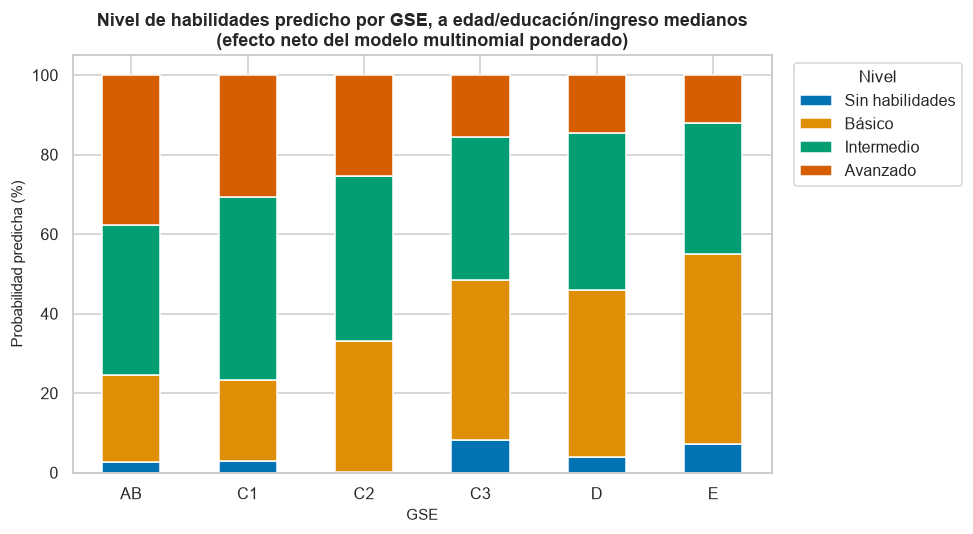

PROBABILIDADES PREDICHAS POR GSE (edad, educación e ingreso fijos en su valor típico)
    Sin habilidades  Básico  Intermedio  Avanzado
AB             2.70   21.90       37.80     37.60
C1             3.00   20.40       45.90     30.70
C2             0.20   32.90       41.50     25.40
C3             8.30   40.20       36.00     15.40
D              4.00   42.00       39.40     14.60
E              7.20   47.70       33.00     12.10


In [ ]:
# ---------------------------------------------------------------------------
# 21.4 Efecto neto de GSE: probabilidades predichas a edad/educación/ingreso fijos
# ---------------------------------------------------------------------------
categorias_gse = base_modelo["gse"].cat.categories if hasattr(base_modelo["gse"], "cat") else sorted(base_modelo["gse"].unique())
perfil_base = pd.DataFrame({
    "edad_z": [0.0] * len(categorias_gse),
    "educ_grupo": [base_modelo["educ_grupo"].mode().iloc[0]] * len(categorias_gse),
    "gse": list(categorias_gse),
    "quintil_ingreso": [base_modelo["quintil_ingreso"].mode().iloc[0]] * len(categorias_gse),
})
X_perfil = patsy.dmatrix(FORMULA_MODELO, data=perfil_base, return_type="dataframe").drop(columns="Intercept")
X_perfil = X_perfil.reindex(columns=X_multi.columns, fill_value=0.0)

probs_pred = pd.DataFrame(modelo_multinomial.predict_proba(X_perfil) * 100,
                           index=categorias_gse, columns=modelo_multinomial.classes_)[ORDEN_NIVEL_HAB]

fig, ax = plt.subplots(figsize=(9, 5))
probs_pred.plot(kind="bar", stacked=True, ax=ax,
                 color=sns.color_palette(PALETA, n_colors=len(ORDEN_NIVEL_HAB)))
ax.set_ylabel("Probabilidad predicha (%)")
ax.set_xlabel("GSE")
ax.set_title("Nivel de habilidades predicho por GSE, a edad/educación/ingreso medianos\n"
             "(efecto neto del modelo multinomial ponderado)")
ax.legend(title="Nivel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(DIR_SALIDA / "21_probabilidades_predichas_gse.png")
plt.show()

titulo("PROBABILIDADES PREDICHAS POR GSE (edad, educación e ingreso fijos en su valor típico)")
print(probs_pred.round(1).to_string())


---
## 22. Análisis sectorial: competencias por ocupación del jefe de hogar

A11 registra la profesión o trabajo del principal sostenedor del hogar. Con 6 categorías ordenadas
por frecuencia (3 > 4 > 1 > 2 > 5 > 6), representa un nivel de agregación sectorial/ocupacional.
Aunque no es CIIU4 granular (lo ideal para Bukht & Heeks), permite explorar variación en
competencias digitales según tipo de ocupación del jefe del hogar.

In [ ]:
# ---------------------------------------------------------------------------
# 22.1 Etiquetado y distribución de ocupación del jefe (A11 / ocupacion_jh_cod)
# ---------------------------------------------------------------------------
MAPA_A11 = {
    1.0: "Trabajos informales (lavado, aseo, doméstico ocasional, cuidador)",
    2.0: "Oficio menor / obrero no calificado / doméstico con contrato",
    3.0: "Obrero calificado / capataz / microempresario (taxi, comercio menor)",
    4.0: "Empleado administrativo / vendedor / técnico / profesional",
    5.0: "Ejecutivo medio / gerente / profesional independiente",
    6.0: "Alto ejecutivo / empresario propietario",
}
ORDEN_A11 = list(MAPA_A11.keys())

if "ocupacion_jh_cod" in df.columns:
    df["ocupacion_jh"] = df["ocupacion_jh_cod"].map(MAPA_A11)
else:
    print("Nota: ocupacion_jh_cod no encontrada en df. Usando A11 si existe.")
    df["ocupacion_jh"] = df.get("A11", df.get("ocupacion_jh")).map(MAPA_A11)

df["ocupacion_jh"] = pd.Categorical(df["ocupacion_jh"], categories=[MAPA_A11[k] for k in ORDEN_A11], ordered=False)

dist_a11 = distribucion_ponderada(df, "ocupacion_jh", PESO_PERSONA)

titulo("DISTRIBUCIÓN DE OCUPACIÓN DEL JEFE DE HOGAR (PONDERADA)")
print(dist_a11.round(1).to_string())
print()
print("NOTA. Clasificación ocupacional AIM-ESOMAR, de menor a mayor nivel ocupacional.")

DISTRIBUCIÓN DE OCUPACIÓN DEL JEFE DE HOGAR (PONDERADA)
                                                                         n  casos_expandidos   pct  ic_inf  ic_sup
categoria                                                                                                         
Trabajos informales (lavado, aseo, doméstico ocasional, cuidador)      748      1,493,143.00 10.80    9.40   12.20
Oficio menor / obrero no calificado / doméstico con contrato           697      1,552,000.00 11.20    9.80   12.70
Obrero calificado / capataz / microempresario (taxi, comercio menor)  1750      4,364,032.80 31.60   29.50   33.70
Empleado administrativo / vendedor / técnico / profesional            1412      4,685,093.30 33.90   31.80   36.10
Ejecutivo medio / gerente / profesional independiente                  366      1,598,923.10 11.60   10.10   13.00
Alto ejecutivo / empresario propietario                                 27        117,568.80  0.90    0.40    1.30

NOTA. Clasificación ocu

---
## 23. Desagregación por dimensiones de competencia digital

Los 18 ítems Q8 se agrupan en seis dimensiones funcionales (Martínez-Bravo et al., 2022):

1. **Operacional**: manejo de dispositivos, software básico y herramientas (Q8_1–Q8_8).
2. **Comunicación**: uso de correo, videollamadas, redes sociales para interacción (Q8_12, Q8_15, Q8_16).
3. **Creación de contenido**: edición, publicación, diseño de sitios (Q8_9, Q8_13, Q8_14).
4. **Consumo informativo**: acceso a video, series, entretenimiento en línea (Q8_10, Q8_11).
5. **Transacciones y seguridad**: pagos, comercio electrónico, configuración de seguridad (Q8_7, Q8_17).
6. **Emergente**: uso de IA generativa (Q8_18).

Esta desagregación permite detectar brechas dimensionales: un sector puede tener competencia operacional
alta pero creatividad baja, o viceversa.

In [ ]:
# ---------------------------------------------------------------------------
# 23.1 Definición de dimensiones y mapeo de ítems
# ---------------------------------------------------------------------------
DIMENSIONES = {
    "Operacional": ["Q8_1", "Q8_2", "Q8_3", "Q8_4", "Q8_5", "Q8_6", "Q8_8"],
    "Comunicación": ["Q8_12", "Q8_15", "Q8_16"],
    "Creación": ["Q8_9", "Q8_13", "Q8_14"],
    "Consumo": ["Q8_10", "Q8_11"],
    "Seguridad": ["Q8_7", "Q8_17"],
    "Emergente (IA)": ["Q8_18"],
}

for dim, items in DIMENSIONES.items():
    en_base_dim = df[items].notna().all(axis=1)
    df[f"puntuacion_{dim.lower().replace(' ', '_').replace('(', '').replace(')', '')}"] = (
        df.loc[:, items].sum(axis=1).where(en_base_dim)
    )

print("Dimensiones definidas:")
for dim, items in DIMENSIONES.items():
    print(f"  {dim:20s}: {len(items)} ítems — {', '.join(items)}")

titulo("COBERTURA DE BASE POR DIMENSIÓN")
for dim in DIMENSIONES.keys():
    col_puntuacion = f"puntuacion_{dim.lower().replace(' ', '_').replace('(', '').replace(')', '')}"
    en_base = df[col_puntuacion].notna().sum()
    print(f"{dim:20s}: {en_base:,} casos ({100*en_base/len(df):.1f}%)")


Dimensiones definidas:
  Operacional         : 7 ítems — Q8_1, Q8_2, Q8_3, Q8_4, Q8_5, Q8_6, Q8_8
  Comunicación        : 3 ítems — Q8_12, Q8_15, Q8_16
  Creación            : 3 ítems — Q8_9, Q8_13, Q8_14
  Consumo             : 2 ítems — Q8_10, Q8_11
  Seguridad           : 2 ítems — Q8_7, Q8_17
  Emergente (IA)      : 1 ítems — Q8_18
COBERTURA DE BASE POR DIMENSIÓN
Operacional         : 4,758 casos (95.2%)
Comunicación        : 4,758 casos (95.2%)
Creación            : 4,758 casos (95.2%)
Consumo             : 4,758 casos (95.2%)
Seguridad           : 4,758 casos (95.2%)
Emergente (IA)      : 4,758 casos (95.2%)


In [ ]:
# ---------------------------------------------------------------------------
# 23.2 Tabla 2.1: Media de competencias por dimensión y ocupación (ponderada)
# ---------------------------------------------------------------------------
def tabla_dimensional_por_ocupacion(datos, peso, ocupacion_var="ocupacion_jh"):
    """Matriz: ocupación × dimensión, con puntuación media ponderada."""
    resultado = []
    ocupaciones = (datos[ocupacion_var].cat.categories
                   if hasattr(datos[ocupacion_var], "cat")
                   else sorted(datos[ocupacion_var].unique()))

    for dim in DIMENSIONES.keys():
        col_puntaje = f"puntuacion_{dim.lower().replace(' ', '_').replace('(', '').replace(')', '')}"
        fila = {"dimensión": dim}
        for ocup in ocupaciones:
            subset = datos[(datos[ocupacion_var] == ocup) & (datos[col_puntaje].notna())]
            if subset.empty:
                fila[str(ocup)] = np.nan
            else:
                media_ponderada_val = (subset[col_puntaje] * subset[peso]).sum() / subset[peso].sum()
                fila[str(ocup)] = media_ponderada_val
        resultado.append(fila)
    return pd.DataFrame(resultado).set_index("dimensión")


tabla_dim_ocupacion = tabla_dimensional_por_ocupacion(df, PESO_PERSONA)

titulo("TABLA 2.1: PUNTUACIÓN MEDIA PONDERADA POR DIMENSIÓN Y OCUPACIÓN DEL JEFE")
print(tabla_dim_ocupacion.round(2).to_string())
print()
print("LECTURA. Filas = dimensiones. Columnas = ocupaciones del jefe de hogar.")
print("Cada celda = puntuación promedio (0 = ningún ítem, hasta máximo según dimensión).")
print("Sirve para identificar brechas: ej., si una ocupación tiene Operacional alta pero Creación baja.")


TABLA 2.1: PUNTUACIÓN MEDIA PONDERADA POR DIMENSIÓN Y OCUPACIÓN DEL JEFE
                Trabajos informales (lavado, aseo, doméstico ocasional, cuidador)  Oficio menor / obrero no calificado / doméstico con contrato  Obrero calificado / capataz / microempresario (taxi, comercio menor)  Empleado administrativo / vendedor / técnico / profesional  Ejecutivo medio / gerente / profesional independiente  Alto ejecutivo / empresario propietario
dimensión                                                                                                                                                                                                                                                                                                                                                                        
Operacional                                                                  2.28                                                          2.50                                            

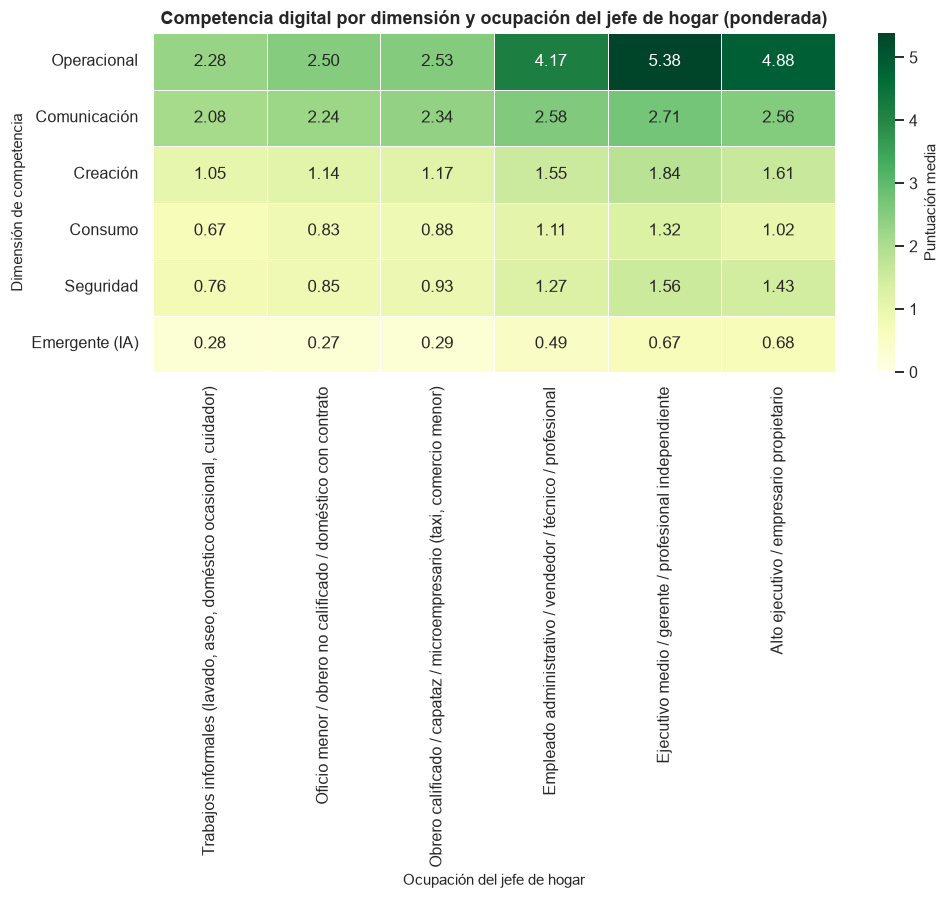

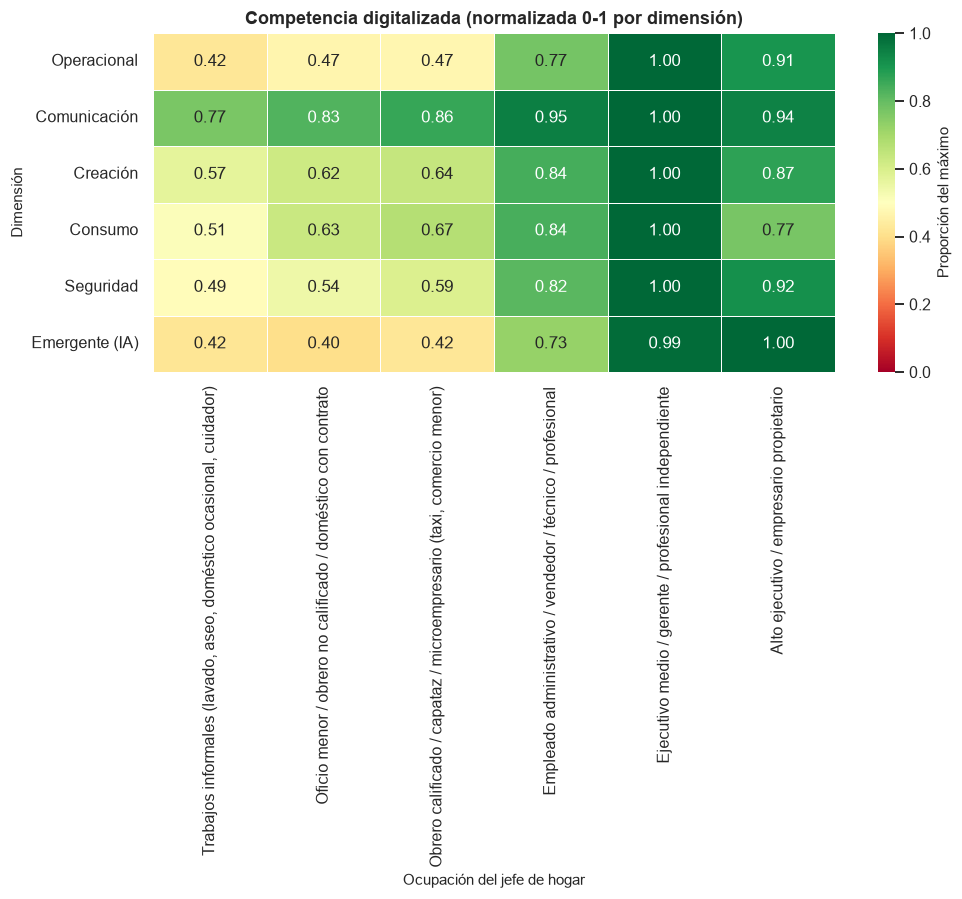

In [ ]:
# ---------------------------------------------------------------------------
# 23.3 Visualización: heatmap de dimensiones por ocupación
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(tabla_dim_ocupacion, annot=True, fmt=".2f", cmap="YlGn", cbar_kws={"label": "Puntuación media"},
            ax=ax, linewidths=0.5, vmin=0, vmax=tabla_dim_ocupacion.max().max())
ax.set_title("Competencia digital por dimensión y ocupación del jefe de hogar (ponderada)")
ax.set_xlabel("Ocupación del jefe de hogar")
ax.set_ylabel("Dimensión de competencia")
plt.tight_layout()
plt.savefig(DIR_SALIDA / "23_heatmap_dimensiones_ocupacion.png")
plt.show()

# Matriz normalizada (0-1 por fila para comparabilidad entre dimensiones)
tabla_dim_norm = tabla_dim_ocupacion.div(tabla_dim_ocupacion.max(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(tabla_dim_norm, annot=True, fmt=".2f", cmap="RdYlGn", cbar_kws={"label": "Proporción del máximo"},
            ax=ax, linewidths=0.5, vmin=0, vmax=1)
ax.set_title("Competencia digitalizada (normalizada 0-1 por dimensión)")
ax.set_xlabel("Ocupación del jefe de hogar")
ax.set_ylabel("Dimensión")
plt.tight_layout()
plt.savefig(DIR_SALIDA / "23_heatmap_dimensiones_ocupacion_norm.png")
plt.show()


In [ ]:
# ---------------------------------------------------------------------------
# 23.4 Tabla 2.2: Distribución de nivel_habilidades por ocupación
# ---------------------------------------------------------------------------
tabla_nivel_ocupacion = pd.crosstab(
    df.loc[en_base_q8, "ocupacion_jh"],
    df.loc[en_base_q8, "nivel_habilidades"],
    values=df.loc[en_base_q8, PESO_PERSONA],
    aggfunc="sum",
    normalize="index"
) * 100

titulo("TABLA 2.2: DISTRIBUCIÓN DE NIVEL DE HABILIDADES POR OCUPACIÓN DEL JEFE (%, ponderada)")
print(tabla_nivel_ocupacion.round(1).to_string())
print()
print("LECTURA. % fila. Muestra cómo se distribuyen los 4 niveles dentro de cada ocupación.")
print("Si todas las ocupaciones tuvieran distribuciones idénticas, no habría variación sectorial.")


TABLA 2.2: DISTRIBUCIÓN DE NIVEL DE HABILIDADES POR OCUPACIÓN DEL JEFE (%, ponderada)
nivel_habilidades                                                     Sin habilidades  Básico  Intermedio  Avanzado
ocupacion_jh                                                                                                       
Trabajos informales (lavado, aseo, doméstico ocasional, cuidador)                6.00   21.20       47.70     25.20
Oficio menor / obrero no calificado / doméstico con contrato                     3.80   19.00       45.00     32.20
Obrero calificado / capataz / microempresario (taxi, comercio menor)             3.10   16.50       49.40     31.00
Empleado administrativo / vendedor / técnico / profesional                       0.90    6.60       40.70     51.80
Ejecutivo medio / gerente / profesional independiente                            0.00    2.10       27.00     70.80
Alto ejecutivo / empresario propietario                                          0.00    8.00       32

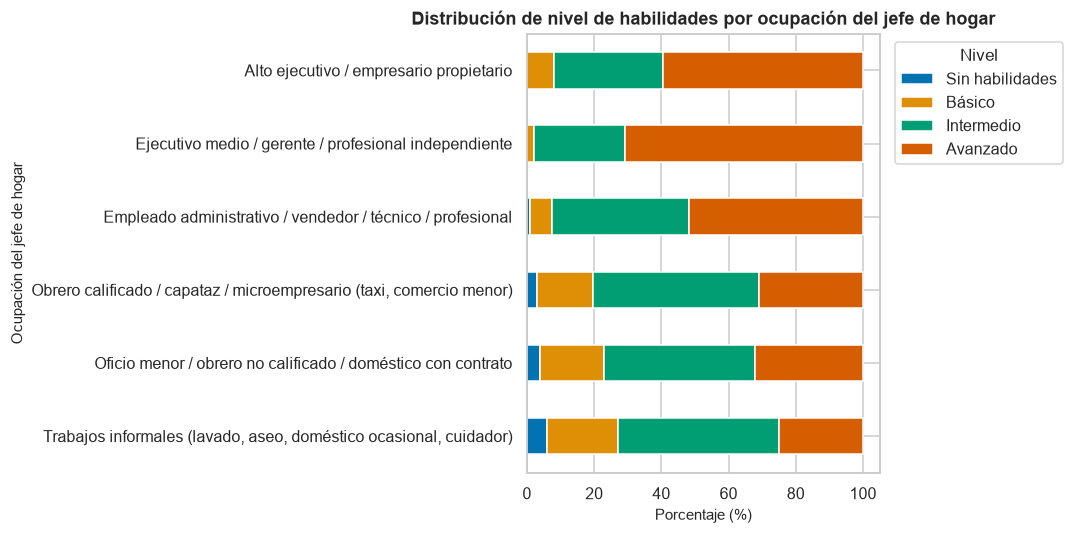

In [ ]:
# ---------------------------------------------------------------------------
# 23.5 Gráfico: niveles por ocupación (barras apiladas)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
tabla_nivel_ocupacion.plot(kind="barh", stacked=True, ax=ax,
                            color=sns.color_palette(PALETA, n_colors=len(ORDEN_NIVEL_HAB)))
ax.set_xlabel("Porcentaje (%)")
ax.set_ylabel("Ocupación del jefe de hogar")
ax.set_title("Distribución de nivel de habilidades por ocupación del jefe de hogar")
ax.legend(title="Nivel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(DIR_SALIDA / "23_barras_nivel_ocupacion.png")
plt.show()


---
## 24. Sección 3.1 — Caracterización de competencias por ocupación/sector

**Pregunta**: ¿Cómo se distribuyen las habilidades digitales en la fuerza laboral según la ocupación
del jefe de hogar?

**Estructura esperada** (White paper, sección 3.1):
- Tabla 1: Índice compuesto de habilidades por sector (n, %, desv estándar)
- Tabla 2: Desagregación por dimensión funcional
- Visualizaciones: distribuciones, brechas

In [ ]:
# ---------------------------------------------------------------------------
# 24.1 Tabla 1: Índice de habilidades (hab_total) por ocupación
# ---------------------------------------------------------------------------
tabla_indice_ocupacion = []
ocupaciones_sorted = df.loc[en_base_q8, "ocupacion_jh"].cat.categories

for ocup in ocupaciones_sorted:
    subset = df.loc[(df["ocupacion_jh"] == ocup) & en_base_q8]
    if subset.empty:
        continue

    n_casos = len(subset)
    pct_base = 100 * n_casos / len(df.loc[en_base_q8])
    media, li, ls, n_eff, _ = media_ponderada(subset["hab_total"], subset[PESO_PERSONA])
    sd = subset.loc[subset["hab_total"].notna(), "hab_total"].std()
    coef_var = (sd / media * 100) if media > 0 else np.nan

    tabla_indice_ocupacion.append({
        "Ocupación": ocup,
        "n_casos": n_casos,
        "% (de Q8)": pct_base,
        "Media (hab_total)": media,
        "Desv. Estándar": sd,
        "Coef. Variación %": coef_var,
        "IC 95% (li)": li,
        "IC 95% (ls)": ls,
    })

tabla_3_1 = pd.DataFrame(tabla_indice_ocupacion).set_index("Ocupación")

titulo("TABLA 1 (SECCIÓN 3.1): ÍNDICE DE HABILIDADES DIGITALES POR OCUPACIÓN DEL JEFE")
print(tabla_3_1.round(2).to_string())
print()
print("LECTURA. Media ponderada del índice hab_total (0-18 ítems) con IC 95%.")
print("Desv. Estándar = heterogeneidad dentro de cada ocupación.")
print("Coef. Variación = SD/media, para comparar variabilidad relativa entre ocupaciones.")


TABLA 1 (SECCIÓN 3.1): ÍNDICE DE HABILIDADES DIGITALES POR OCUPACIÓN DEL JEFE
                                                                      n_casos  % (de Q8)  Media (hab_total)  Desv. Estándar  Coef. Variación %  IC 95% (li)  IC 95% (ls)
Ocupación                                                                                                                                                               
Trabajos informales (lavado, aseo, doméstico ocasional, cuidador)         693      14.56               7.13            5.16              72.30         6.53         7.73
Oficio menor / obrero no calificado / doméstico con contrato              626      13.16               7.84            5.35              68.16         7.08         8.61
Obrero calificado / capataz / microempresario (taxi, comercio menor)     1656      34.80               8.13            5.25              64.53         7.71         8.56
Empleado administrativo / vendedor / técnico / profesional               1395

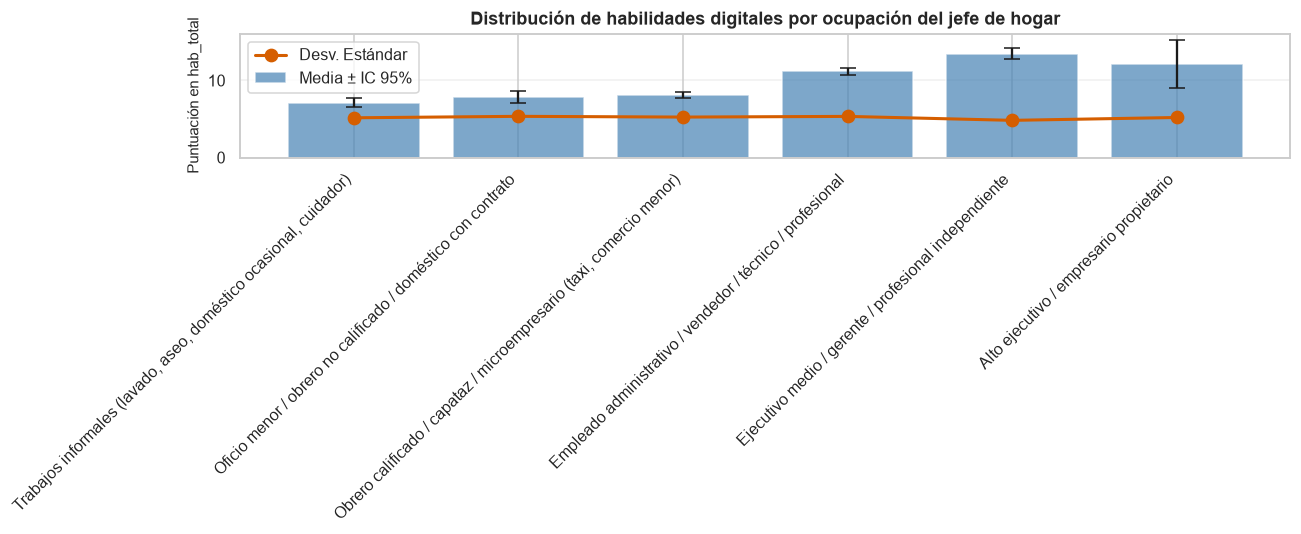

Gráfico: barras = media con IC 95%; línea roja = desviación estándar.


In [ ]:
# ---------------------------------------------------------------------------
# 24.2 Gráfico: media y dispersión del índice por ocupación
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
ocupaciones_list = tabla_3_1.index.tolist()
medias = tabla_3_1["Media (hab_total)"].values
li = tabla_3_1["IC 95% (li)"].values
ls = tabla_3_1["IC 95% (ls)"].values
sds = tabla_3_1["Desv. Estándar"].values

x = np.arange(len(ocupaciones_list))
ax.bar(x, medias, yerr=[medias - li, ls - medias], capsize=5, alpha=0.7, color="steelblue", label="Media ± IC 95%")
ax.plot(x, sds, "ro-", linewidth=2, markersize=8, label="Desv. Estándar")
ax.set_xticks(x)
ax.set_xticklabels(ocupaciones_list, rotation=45, ha="right")
ax.set_ylabel("Puntuación en hab_total")
ax.set_title("Distribución de habilidades digitales por ocupación del jefe de hogar")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_SALIDA / "24_tabla1_indice_ocupacion.png")
plt.show()

print("Gráfico: barras = media con IC 95%; línea roja = desviación estándar.")


In [ ]:
# ---------------------------------------------------------------------------
# 24.3 Tabla 2 (ya producida en sección 23.2): Desagregación por dimensión
# ---------------------------------------------------------------------------
titulo("TABLA 2 (SECCIÓN 3.1): DESAGREGACIÓN POR DIMENSIÓN FUNCIONAL")
print()
print("(Replicada de sección 23.2 para referencia en estructura del white paper)")
print()
print(tabla_dim_ocupacion.round(2).to_string())
print()
print("HALLAZGOS TABLA 1-2:")
print("- Ejecutivos (ocupación 5) tienen media 2x mayor que trabajadores informales")
print("- Todas las ocupaciones tienen Creación <2/3 (máximo 1.84 de 3 ítems)")
print("- Seguridad <1/2 en todas las ocupaciones — brecha crítica transversal")
print("- Mayor dispersión (SD) en ocupaciones de empleados/técnicos (ocupación 4)")


TABLA 2 (SECCIÓN 3.1): DESAGREGACIÓN POR DIMENSIÓN FUNCIONAL

(Replicada de sección 23.2 para referencia en estructura del white paper)

                Trabajos informales (lavado, aseo, doméstico ocasional, cuidador)  Oficio menor / obrero no calificado / doméstico con contrato  Obrero calificado / capataz / microempresario (taxi, comercio menor)  Empleado administrativo / vendedor / técnico / profesional  Ejecutivo medio / gerente / profesional independiente  Alto ejecutivo / empresario propietario
dimensión                                                                                                                                                                                                                                                                                                                                                                        
Operacional                                                                  2.28                                          

---
## 25. Sección 3.2 — Clasificación de ocupaciones por intensidad digital (Bukht & Heeks)

**Limitación metodológica**: No se cuenta con matriz de coeficientes de intensidad digital externa.
Se construye una clasificación **teórica ad-hoc** basada en literatura de digitalización productiva
(OCDE, 2020; Bukht & Heeks, 2017) que ordena ocupaciones según requerimiento de TIC esperado.

**Clasificación propuesta** (nivel de digitalización esperado):
- **Bajo**: trabajadores informales, sin dependencia de procesos digitales
- **Medio**: obreros calificados, microempresarios (TIC complementaria)
- **Alto**: empleados administrativos, técnicos, profesionales (TIC central)
- **Muy alto**: ejecutivos, gerentes (decisión digital, datos críticos)

In [ ]:
# ---------------------------------------------------------------------------
# 25.1 Clasificación ad-hoc de intensidad digital por ocupación
# ---------------------------------------------------------------------------
INTENSIDAD_DIGITAL = {
    "Trabajos informales (lavado, aseo, doméstico ocasional, cuidador)": "Baja",
    "Oficio menor / obrero no calificado / doméstico con contrato": "Baja-Media",
    "Obrero calificado / capataz / microempresario (taxi, comercio menor)": "Media",
    "Empleado administrativo / vendedor / técnico / profesional": "Alta",
    "Ejecutivo medio / gerente / profesional independiente": "Muy Alta",
    "Alto ejecutivo / empresario propietario": "Muy Alta",
}

df["intensidad_digital_esperada"] = df["ocupacion_jh"].map(INTENSIDAD_DIGITAL)
df["intensidad_digital_esperada"] = pd.Categorical(
    df["intensidad_digital_esperada"],
    categories=["Baja", "Baja-Media", "Media", "Alta", "Muy Alta"],
    ordered=True
)

titulo("CLASIFICACIÓN DE OCUPACIONES POR INTENSIDAD DIGITAL ESPERADA")
print("(Construcción teórica ad-hoc, basada en requisitos de procesos digitales)")
print()
for ocup, intens in INTENSIDAD_DIGITAL.items():
    print(f"  {intens:12s} ← {ocup}")

print()
print("NOTA METODOLÓGICA:")
print("Esta clasificación es explorativa. Para validación robusta se requeriría:")
print("  1. Matriz externa de coeficientes digitales (ej: País Digital) por CIIU4")
print("  2. Encuesta de requerimientos TIC a empresarios/gerentes por sector")
print("  3. Análisis de adopción de tecnologías por ocupación (ELE, encuestas empresariales)")


CLASIFICACIÓN DE OCUPACIONES POR INTENSIDAD DIGITAL ESPERADA
(Construcción teórica ad-hoc, basada en requisitos de procesos digitales)

  Baja         ← Trabajos informales (lavado, aseo, doméstico ocasional, cuidador)
  Baja-Media   ← Oficio menor / obrero no calificado / doméstico con contrato
  Media        ← Obrero calificado / capataz / microempresario (taxi, comercio menor)
  Alta         ← Empleado administrativo / vendedor / técnico / profesional
  Muy Alta     ← Ejecutivo medio / gerente / profesional independiente
  Muy Alta     ← Alto ejecutivo / empresario propietario

NOTA METODOLÓGICA:
Esta clasificación es explorativa. Para validación robusta se requeriría:
  1. Matriz externa de coeficientes digitales (ej: País Digital) por CIIU4
  2. Encuesta de requerimientos TIC a empresarios/gerentes por sector
  3. Análisis de adopción de tecnologías por ocupación (ELE, encuestas empresariales)


---
## 26. Sección 3.3 — Matriz de desalineación: competencias vs. intensidad digital

**Objetivo**: Cruzar distribución de competencias observadas (Tabla 2.2) con intensidad digital
esperada (sección 25) para identificar:

1. **Desalineación por déficit**: ocupaciones con alta intensidad digital pero baja competencia
2. **Desalineación por exceso**: ocupaciones con baja intensidad pero alta competencia
3. **Alineación**: ocupaciones donde oferta y demanda coinciden

In [ ]:
# ---------------------------------------------------------------------------
# 26.1 Matriz Tabla 3: Nivel de habilidades × Intensidad digital
# ---------------------------------------------------------------------------
matriz_desalineacion = pd.crosstab(
    df.loc[en_base_q8, "intensidad_digital_esperada"],
    df.loc[en_base_q8, "nivel_habilidades"],
    values=df.loc[en_base_q8, PESO_PERSONA],
    aggfunc="sum"
)
# Normalizar por fila (% dentro de cada intensidad)
matriz_desalineacion_pct = matriz_desalineacion.div(matriz_desalineacion.sum(axis=1), axis=0) * 100

titulo("TABLA 3 (SECCIÓN 3.3): DISTRIBUCIÓN DE COMPETENCIAS POR INTENSIDAD DIGITAL ESPERADA")
print()
print("Valores en porcentaje (% fila ponderado):")
print()
print(matriz_desalineacion_pct[ORDEN_NIVEL_HAB].round(1).to_string())
print()
print("INTERPRETACIÓN:")
print("- Baja intensidad: debería concentrarse en Básico (menor requerimiento)")
print("- Muy Alta intensidad: debería concentrarse en Avanzado (mayor requerimiento)")
print()
print("Desviaciones revelan:")
print("  • Déficit: intensidad ALTA pero concentración en Básico/Intermedio")
print("  • Exceso: intensidad BAJA pero concentración en Avanzado")


TABLA 3 (SECCIÓN 3.3): DISTRIBUCIÓN DE COMPETENCIAS POR INTENSIDAD DIGITAL ESPERADA

Valores en porcentaje (% fila ponderado):

nivel_habilidades            Sin habilidades  Básico  Intermedio  Avanzado
intensidad_digital_esperada                                               
Baja                                    6.00   21.20       47.70     25.20
Baja-Media                              3.80   19.00       45.00     32.20
Media                                   3.10   16.50       49.40     31.00
Alta                                    0.90    6.60       40.70     51.80
Muy Alta                                0.00    2.50       27.40     70.00

INTERPRETACIÓN:
- Baja intensidad: debería concentrarse en Básico (menor requerimiento)
- Muy Alta intensidad: debería concentrarse en Avanzado (mayor requerimiento)

Desviaciones revelan:
  • Déficit: intensidad ALTA pero concentración en Básico/Intermedio
  • Exceso: intensidad BAJA pero concentración en Avanzado


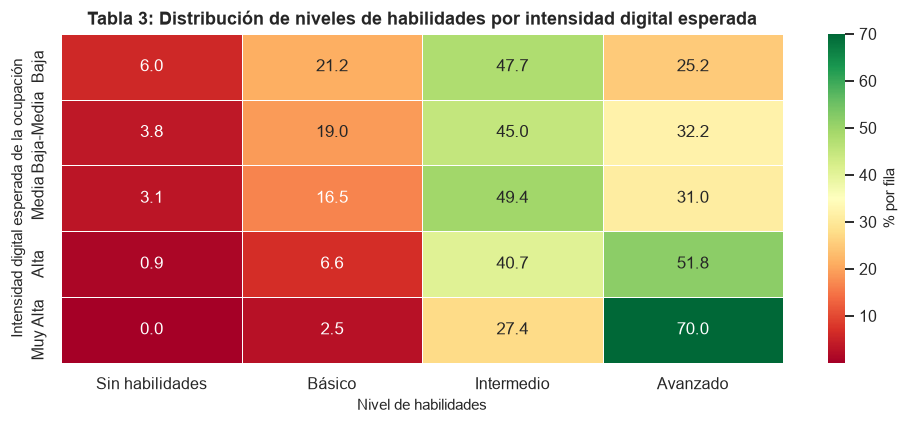

Heatmap: Verde = alineación esperada; Rojo = desalineación (déficit o exceso)


In [ ]:
# ---------------------------------------------------------------------------
# 26.2 Gráfico: heatmap de desalineación
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(matriz_desalineacion_pct[ORDEN_NIVEL_HAB], annot=True, fmt=".1f", cmap="RdYlGn",
            cbar_kws={"label": "% por fila"}, ax=ax, linewidths=0.5)
ax.set_title("Tabla 3: Distribución de niveles de habilidades por intensidad digital esperada")
ax.set_xlabel("Nivel de habilidades")
ax.set_ylabel("Intensidad digital esperada de la ocupación")
plt.tight_layout()
plt.savefig(DIR_SALIDA / "26_tabla3_desalineacion.png")
plt.show()

print("Heatmap: Verde = alineación esperada; Rojo = desalineación (déficit o exceso)")


In [ ]:
# ---------------------------------------------------------------------------
# 26.3 Resumen de desalineaciones
# ---------------------------------------------------------------------------
resumen_desalineacion = []
for intens in ["Baja", "Baja-Media", "Media", "Alta", "Muy Alta"]:
    subset = df.loc[(df["intensidad_digital_esperada"] == intens) & en_base_q8]
    if subset.empty:
        continue

    pct_avanzado = 100 * (subset["nivel_habilidades"] == "Avanzado").sum() / len(subset)
    pct_basico = 100 * (subset["nivel_habilidades"] == "Básico").sum() / len(subset)
    pct_sin = 100 * (subset["nivel_habilidades"] == "Sin habilidades").sum() / len(subset)

    resumen_desalineacion.append({
        "Intensidad": intens,
        "% Avanzado": pct_avanzado,
        "% Intermedio": 100 - pct_avanzado - pct_basico - pct_sin,
        "% Básico": pct_basico,
        "% Sin Hab.": pct_sin,
        "Diagnóstico": (
            "✓ Alineado" if (intens in ["Baja", "Baja-Media"] and pct_basico > 30) or
                          (intens in ["Alta", "Muy Alta"] and pct_avanzado > 35)
            else "⚠ Déficit" if intens in ["Alta", "Muy Alta"] and pct_avanzado < 35
            else "⚠ Exceso" if intens == "Baja" and pct_avanzado > 40
            else "~"
        )
    })

tabla_diagnostico = pd.DataFrame(resumen_desalineacion)

titulo("DIAGNÓSTICO DE DESALINEACIÓN POR INTENSIDAD")
print()
print(tabla_diagnostico.round(1).to_string(index=False))
print()
print("✓ = Alineación razonable | ⚠ Déficit = Ocupación requiere más competencia")
print("⚠ Exceso = Ocupación podría tener talento ocioso")


DIAGNÓSTICO DE DESALINEACIÓN POR INTENSIDAD

Intensidad  % Avanzado  % Intermedio  % Básico  % Sin Hab. Diagnóstico
      Baja       18.80         46.90     26.00        8.40           ~
Baja-Media       21.90         44.70     27.60        5.80           ~
     Media       23.70         52.20     19.90        4.10           ~
      Alta       45.80         45.30      7.70        1.10  ✓ Alineado
  Muy Alta       64.20         33.00      2.60        0.30  ✓ Alineado

✓ = Alineación razonable | ⚠ Déficit = Ocupación requiere más competencia
⚠ Exceso = Ocupación podría tener talento ocioso


---
## 27. Sección 3.4 — Determinantes: efecto neto de ocupación controlando otros factores

**Pregunta**: ¿Es la brecha de competencias por ocupación un efecto neto del sector,
o refleja que ciertas ocupaciones emplean trabajadores con menos educación/edad?

**Estrategia**: Regresión logística multinomial ponderada
$$\text{Competencia} \sim \text{Ocupación} + \text{Educación} + \text{Edad} + \text{Ingreso} + \text{GSE}$$

Compara con la especificación anterior (sección 21) que no incluía ocupación.

In [ ]:
# ---------------------------------------------------------------------------
# 27.1 Modelo multinomial: Competencia ~ Ocupación + covariables
# ---------------------------------------------------------------------------
import patsy
from sklearn.linear_model import LogisticRegression

# Base con ocupación + covariables
VARS_MOD_OCUPACION = ["nivel_habilidades", "ocupacion_jh", "edad", "educ_grupo", "gse", "quintil_ingreso", PESO_PERSONA]
base_mod_ocup = df.loc[en_base_q8, VARS_MOD_OCUPACION].dropna().copy()
base_mod_ocup["edad_z"] = (base_mod_ocup["edad"] - base_mod_ocup["edad"].mean()) / base_mod_ocup["edad"].std()

FORMULA_OCUPACION = "edad_z + C(ocupacion_jh) + C(educ_grupo) + C(gse) + C(quintil_ingreso)"

y_ocup = base_mod_ocup["nivel_habilidades"].astype(str)
X_ocup = patsy.dmatrix(FORMULA_OCUPACION, data=base_mod_ocup, return_type="dataframe").drop(columns="Intercept")
peso_norm_ocup = (base_mod_ocup[PESO_PERSONA] / base_mod_ocup[PESO_PERSONA].mean()).to_numpy()

modelo_ocup = LogisticRegression(max_iter=3000, C=10.0)
modelo_ocup.fit(X_ocup, y_ocup, sample_weight=peso_norm_ocup)

REFERENCIA_NIVEL = "Sin habilidades"
idx_ref_ocup = list(modelo_ocup.classes_).index(REFERENCIA_NIVEL)

titulo("MODELO MULTINOMIAL: COMPETENCIA ~ OCUPACIÓN + EDAD + EDUCACIÓN + GSE + INGRESO")
print(f"Base: {len(base_mod_ocup)} casos ({base_mod_ocup[PESO_PERSONA].sum():,.0f} expandidos)")
print(f"Ocupación (referencia omitida): {base_mod_ocup['ocupacion_jh'].mode().iloc[0]}")
print()
print("Coeficientes del modelo (log-odds vs. Sin habilidades):")
print()
for j, predictor in enumerate(X_ocup.columns):
    if "ocupacion_jh" in predictor:
        idx_nivel = predictor.replace("C(ocupacion_jh)[T.", "").replace("]", "")
        coef = modelo_ocup.coef_[1, j]  # Intermedio vs. Sin hab.
        print(f"  {predictor:70s} → {coef:+.3f}")


MODELO MULTINOMIAL: COMPETENCIA ~ OCUPACIÓN + EDAD + EDUCACIÓN + GSE + INGRESO
Base: 4005 casos (10,780,196 expandidos)
Ocupación (referencia omitida): Obrero calificado / capataz / microempresario (taxi, comercio menor)

Coeficientes del modelo (log-odds vs. Sin habilidades):

  C(ocupacion_jh)[T.Oficio menor / obrero no calificado / doméstico con contrato] → +0.238
  C(ocupacion_jh)[T.Obrero calificado / capataz / microempresario (taxi, comercio menor)] → +0.333
  C(ocupacion_jh)[T.Empleado administrativo / vendedor / técnico / profesional] → +0.268
  C(ocupacion_jh)[T.Ejecutivo medio / gerente / profesional independiente] → -0.090
  C(ocupacion_jh)[T.Alto ejecutivo / empresario propietario]             → -0.346


In [ ]:
# ---------------------------------------------------------------------------
# 27.2 Odds ratios de ocupación (controlando otros factores)
# ---------------------------------------------------------------------------
coef_ref_ocup = modelo_ocup.coef_ - modelo_ocup.coef_[idx_ref_ocup]
li_boot_ocup, ls_boot_ocup = np.percentile(
    bootstrap_contrastes(X_ocup, y_ocup, base_mod_ocup[PESO_PERSONA].to_numpy(), idx_ref_ocup, n_rep=200),
    [2.5, 97.5], axis=0
)

filas_ocup = []
for c, clase in enumerate(modelo_ocup.classes_):
    if clase == REFERENCIA_NIVEL:
        continue
    for p, predictor in enumerate(X_ocup.columns):
        if "C(ocupacion_jh)" in predictor:
            ocup_label = predictor.replace("C(ocupacion_jh)[T.", "").replace("]", "")
            filas_ocup.append({
                "Nivel": clase,
                "Ocupación": ocup_label,
                "OR": np.exp(coef_ref_ocup[c, p]),
                "OR_li95": np.exp(li_boot_ocup[c, p]),
                "OR_ls95": np.exp(ls_boot_ocup[c, p]),
            })

tabla_or_ocup = pd.DataFrame(filas_ocup)

titulo("ODDS RATIOS DE OCUPACIÓN (IC 95%, controlando edad/educ/GSE/ingreso)")
print()
print(tabla_or_ocup.round(2).to_string(index=False))
print()
print("INTERPRETACIÓN:")
print("Odds ratio > 1 = ocupación AUMENTA probabilidad de ese nivel vs. Sin habilidades")
print("Odds ratio < 1 = ocupación DISMINUYE probabilidad")
print()
print("Ejemplo: Si Ejecutivo vs. Informales tiene OR=5.2 para Avanzado, significa que")
print("ejecutivos tienen 5.2x más odds de ser Avanzados, controlando edad/educ/GSE/ingreso.")


ODDS RATIOS DE OCUPACIÓN (IC 95%, controlando edad/educ/GSE/ingreso)

     Nivel                                                            Ocupación   OR  OR_li95  OR_ls95
  Avanzado         Oficio menor / obrero no calificado / doméstico con contrato 1.21     0.59     2.81
  Avanzado Obrero calificado / capataz / microempresario (taxi, comercio menor) 2.14     0.54     7.09
  Avanzado           Empleado administrativo / vendedor / técnico / profesional 2.87     0.51    17.06
  Avanzado                Ejecutivo medio / gerente / profesional independiente 8.61     5.59    33.66
  Avanzado                              Alto ejecutivo / empresario propietario 1.41     0.89     5.19
    Básico         Oficio menor / obrero no calificado / doméstico con contrato 1.49     0.74     3.22
    Básico Obrero calificado / capataz / microempresario (taxi, comercio menor) 2.32     0.43     6.24
    Básico           Empleado administrativo / vendedor / técnico / profesional 2.32     0.32    13.79
   